In [27]:
# ==========================================
# 0. 导包
# ==========================================
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from lifelines import WeibullFitter, CoxTimeVaryingFitter

import matplotlib.pyplot as plt

In [28]:
# ==========================================
# 1. 读文件（FD001-FD004 train）
# ==========================================
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'SM{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 读取所有四个数据集 (FD001-FD004)
file_paths = [
    'CMAPSSData/train_FD001.txt',
    'CMAPSSData/train_FD002.txt',
    'CMAPSSData/train_FD003.txt',
    'CMAPSSData/train_FD004.txt'
]

df_list = []
unit_offset = 0  # 用于给不同数据集的引擎编号加偏移，避免ID冲突

for i, file_path in enumerate(file_paths):
    df_temp = pd.read_csv(file_path, sep=r'\s+', header=None, names=col_names)
    # 给unit_nr加上偏移量，避免不同数据集的引擎ID冲突
    df_temp['unit_nr'] = df_temp['unit_nr'] + unit_offset
    df_temp['dataset'] = f'FD00{i+1}'  # 标记数据来源
    unit_offset = df_temp['unit_nr'].max()  # 更新偏移量
    df_list.append(df_temp)
    print(f"成功读取文件: {file_path}, 行数: {len(df_temp)}")

# 合并所有数据集
df = pd.concat(df_list, ignore_index=True)
print(f"\n合并完成！总数据行数: {len(df)}, 总引擎数: {df['unit_nr'].nunique()}")
print(df.head())

成功读取文件: CMAPSSData/train_FD001.txt, 行数: 20631
成功读取文件: CMAPSSData/train_FD002.txt, 行数: 53759
成功读取文件: CMAPSSData/train_FD003.txt, 行数: 24720
成功读取文件: CMAPSSData/train_FD004.txt, 行数: 61249

合并完成！总数据行数: 160359, 总引擎数: 709
   unit_nr  time_cycles  setting_1  setting_2  setting_3     SM1     SM2  \
0        1            1    -0.0007    -0.0004      100.0  518.67  641.82   
1        1            2     0.0019    -0.0003      100.0  518.67  642.15   
2        1            3    -0.0043     0.0003      100.0  518.67  642.35   
3        1            4     0.0007     0.0000      100.0  518.67  642.35   
4        1            5    -0.0019    -0.0002      100.0  518.67  642.37   

       SM3      SM4    SM5  ...     SM13     SM14    SM15  SM16  SM17  SM18  \
0  1589.70  1400.60  14.62  ...  2388.02  8138.62  8.4195  0.03   392  2388   
1  1591.82  1403.14  14.62  ...  2388.07  8131.49  8.4318  0.03   392  2388   
2  1587.99  1404.20  14.62  ...  2388.03  8133.23  8.4178  0.03   390  2388   
3  1582.79  

In [29]:
# ==========================================
# 2. 选择论文 14 个传感器
# ==========================================
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

df_process = df[index_names + selected_features].copy()

In [30]:
# ==========================================
# 3. Min-Max 归一化（全训练集口径）
# ==========================================
scaler = MinMaxScaler()
df_process[selected_features] = scaler.fit_transform(df_process[selected_features])

print("MinMax done.")

MinMax done.


In [31]:
# ==========================================
# 4. 构建 lifelines CoxTimeVaryingFitter 所需长表
#    start=t-1, stop=t，最后一个cycle event=1
# ==========================================
df_process['start'] = df_process['time_cycles'] - 1
df_process['stop']  = df_process['time_cycles']

max_cycles = df_process.groupby('unit_nr')['time_cycles'].max()

df_process['E'] = (df_process['time_cycles'] == df_process['unit_nr'].map(max_cycles)).astype(int)

print("Long format done:",
      "rows =", len(df_process),
      "units =", df_process['unit_nr'].nunique())
print(df_process[['unit_nr','time_cycles','start','stop','E']].head())

Long format done: rows = 160359 units = 709
   unit_nr  time_cycles  start  stop  E
0        1            1      0     1  0
1        1            2      1     2  0
2        1            3      2     3  0
3        1            4      3     4  0
4        1            5      4     5  0


In [32]:
# ==========================================
# 5. 拟合 Weibull（得到 BH 参数 β, η）
#    使用每台发动机寿命 T = max_cycle，FD001 train 为 run-to-failure => E=1
# ==========================================
durations = max_cycles.values.astype(float)
events = np.ones_like(durations, dtype=int)

wb = WeibullFitter()
wb.fit(durations=durations, event_observed=events)

beta = float(wb.rho_)      # shape
eta  = float(wb.lambda_)   # scale

print("\nWeibull fitted:")
print("beta (shape) =", beta)
print("eta  (scale) =", eta)

# 计算每一行的 Baseline Hazard BH(t) = (beta/eta) * (t/eta)^(beta-1)
t = df_process['time_cycles'].astype(float).values
BH = (beta / eta) * (t / eta) ** (beta - 1.0)
df_process['BH'] = BH


Weibull fitted:
beta (shape) = 3.3643965081691114
eta  (scale) = 250.6644684311487


In [33]:
# ==========================================
# 6. 拟合 time-varying Cox（得到 HR）
#    关键：predict_partial_hazard 只喂 14 个传感器列
# ==========================================
ctv = CoxTimeVaryingFitter(penalizer=0.0)  # 若你觉得不稳定可改 1e-3 或 1e-2
ctv.fit(
    df_process[['unit_nr','start','stop','E'] + selected_features],
    id_col='unit_nr',
    start_col='start',
    stop_col='stop',
    event_col='E',
    show_progress=True
)

print("\nCox TV fitted. Top params:")
print(ctv.params_.sort_values(ascending=False))

HR = ctv.predict_partial_hazard(df_process[selected_features]).values.astype(float)
df_process['HR'] = HR

# hazard_rate（可选，后续不用于聚类）
df_process['hazard_rate'] = df_process['BH'] * df_process['HR']

Iteration 1: norm_delta = 1.06e+02, step_size = 0.9500, log_lik = -3948.97455, newton_decrement = 1.10e+03, seconds_since_start = 0.3
Iteration 2: norm_delta = 4.01e+00, step_size = 0.0950, log_lik = -2745.37331, newton_decrement = 1.75e+02, seconds_since_start = 0.5
Iteration 3: norm_delta = 4.84e+00, step_size = 0.1235, log_lik = -2713.75611, newton_decrement = 1.54e+02, seconds_since_start = 0.8
Iteration 4: norm_delta = 5.57e+00, step_size = 0.1573, log_lik = -2677.92320, newton_decrement = 1.32e+02, seconds_since_start = 1.1
Iteration 5: norm_delta = 1.54e+00, step_size = 0.0501, log_lik = -2639.67034, newton_decrement = 1.07e+02, seconds_since_start = 1.2
Iteration 6: norm_delta = 1.88e+00, step_size = 0.0638, log_lik = -2629.18649, newton_decrement = 1.01e+02, seconds_since_start = 1.4
Iteration 7: norm_delta = 2.26e+00, step_size = 0.0813, log_lik = -2616.73677, newton_decrement = 9.28e+01, seconds_since_start = 1.5
Iteration 8: norm_delta = 2.68e+00, step_size = 0.1036, log_li

In [34]:
# ==========================================
# 7. 构造聚类输入：BH + log(HR)
#    用 log(HR) 是为了抑制指数爆炸；然后做 MinMax scaling
# ==========================================
logHR = np.log(df_process['HR'].values + 1e-12)
df_process['logHR'] = logHR

# scaling（全体样本口径）
bh_scaler = MinMaxScaler()
hr_scaler = MinMaxScaler()

df_process['BH_scaled'] = bh_scaler.fit_transform(df_process[['BH']]).ravel()
df_process['logHR_scaled'] = hr_scaler.fit_transform(df_process[['logHR']]).ravel()

print("\nScaled features ready:")
print(df_process[['BH','HR','logHR','BH_scaled','logHR_scaled']].head())


Scaled features ready:
             BH        HR     logHR  BH_scaled  logHR_scaled
0  2.853697e-08  0.387155 -0.948931   0.000000      0.536872
1  1.469475e-07  0.900289 -0.105040   0.000001      0.567316
2  3.832760e-07  0.157547 -1.848034   0.000004      0.504437
3  7.566871e-07  0.107213 -2.232941   0.000009      0.490551
4  1.282478e-06  0.405154 -0.903488   0.000015      0.538511


In [35]:
# ==========================================
# 8. KMeans：分别对 BH_scaled 与 logHR_scaled 做 2 类聚类（论文结构）
#    目标：输出 BH_state ∈ {0(low),1(high)}，HR_state ∈ {0(low),1(high)}
# ==========================================
def kmeans_2class_high_is_1(x_1d, random_state=42):
    """
    对一维特征做 KMeans(2类)，并强制：均值更大的那类记为 1（高风险），更小为 0（低风险）
    """
    x_1d = np.asarray(x_1d).reshape(-1, 1)
    km = KMeans(n_clusters=2, random_state=random_state, n_init='auto')
    labels = km.fit_predict(x_1d)
    centers = km.cluster_centers_.ravel()

    high_cluster = int(np.argmax(centers))
    # 映射到 {0,1} 且 high=1
    labels_high1 = (labels == high_cluster).astype(int)
    return labels_high1, km

df_process['BH_state'], km_bh = kmeans_2class_high_is_1(df_process['BH_scaled'].values)
df_process['HR_state'], km_hr = kmeans_2class_high_is_1(df_process['logHR_scaled'].values)

print("\nKMeans centers:")
print("BH centers:", km_bh.cluster_centers_.ravel())
print("HR centers:", km_hr.cluster_centers_.ravel())

print(df_process[['BH_scaled','logHR_scaled','BH_state','HR_state']].head())


KMeans centers:
BH centers: [0.032474   0.25125047]
HR centers: [0.41451431 0.66109897]
   BH_scaled  logHR_scaled  BH_state  HR_state
0   0.000000      0.536872         0         0
1   0.000001      0.567316         0         1
2   0.000004      0.504437         0         0
3   0.000009      0.490551         0         0
4   0.000015      0.538511         0         1


In [36]:
# ==========================================
# 9. 合成 3 类健康状态（论文规则）
#    Healthy=2, Warning=1, Failure=0
# ==========================================
def combine_state(bh_state, hr_state):
    # bh_state, hr_state: 0(low) or 1(high)
    if bh_state == 0 and hr_state == 0:
        return 2  # Healthy
    if bh_state == 1 and hr_state == 1:
        return 0  # Failure
    return 1      # Warning

df_process['Health'] = [
    combine_state(bh, hr) for bh, hr in zip(df_process['BH_state'], df_process['HR_state'])
]

print("\nHealth label counts:")
print(df_process['Health'].value_counts().sort_index())


Health label counts:
Health
0    11677
1    93404
2    55278
Name: count, dtype: int64


In [37]:
# ==========================================
# 10. 强制末段 failure（论文有这一手；d 论文未明说，先用 5）
# ==========================================
d = 5
for unit in df_process['unit_nr'].unique():
    idx = (df_process[df_process['unit_nr'] == unit]
           .sort_values('time_cycles')
           .tail(d)
           .index)
    df_process.loc[idx, 'Health'] = 0

print("\nHealth label counts after tail-forcing:")
print(df_process['Health'].value_counts().sort_index())


Health label counts after tail-forcing:
Health
0    14179
1    91109
2    55071
Name: count, dtype: int64


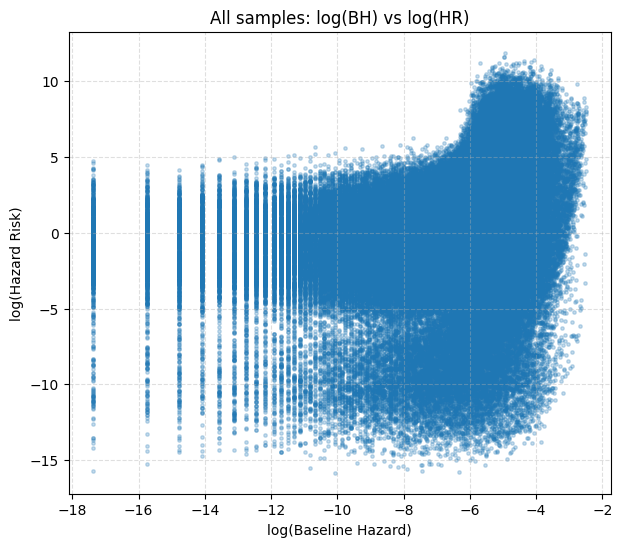

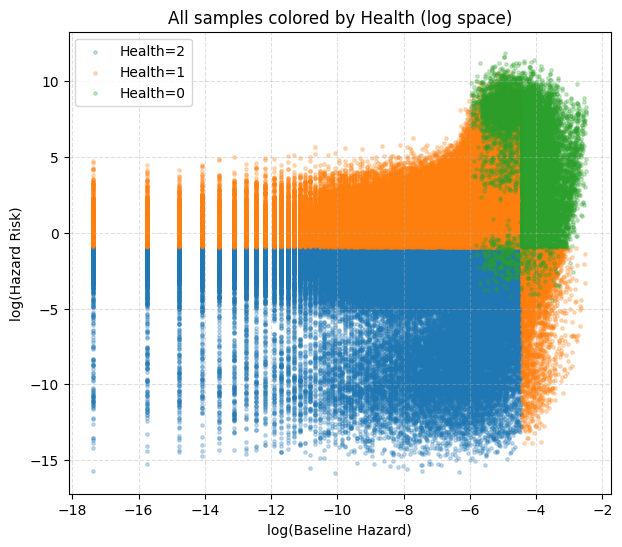

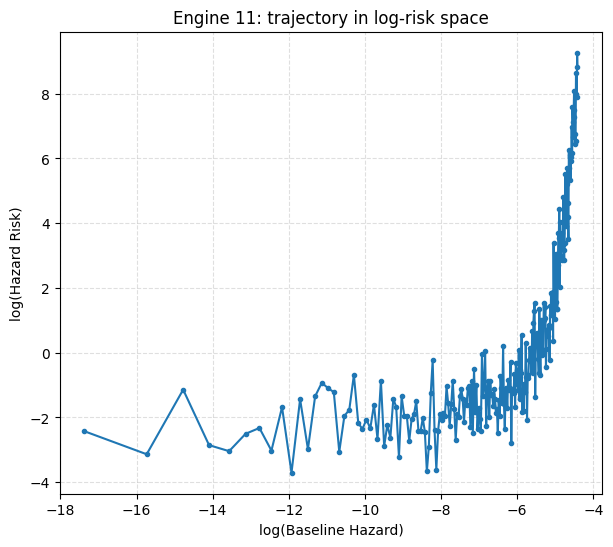

In [38]:
# ==========================================
# 11. 可视化：BH_scaled vs logHR_scaled（全体点 + 选定 engine）
# ==========================================
# 全体散点
plt.figure(figsize=(7, 6))
plt.scatter(
    np.log(df_process['BH'] + 1e-30),
    np.log(df_process['HR'] + 1e-12),
    s=6,
    alpha=0.25
)
plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples: log(BH) vs log(HR)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# 按健康状态着色（颜色不指定也行，但这里为了区分更直观）
plt.figure(figsize=(7, 6))
for label in [2, 1, 0]:
    sub = df_process[df_process['Health'] == label]
    plt.scatter(
        np.log(sub['BH'] + 1e-30),
        np.log(sub['HR'] + 1e-12),
        s=6,
        alpha=0.25,
        label=f"Health={label}"
    )

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples colored by Health (log space)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


# 单独看 Engine 11 的轨迹
engine_id = 11
sub11 = df_process[df_process['unit_nr'] == engine_id].sort_values('time_cycles')

plt.figure(figsize=(7, 6))
plt.plot(
    np.log(sub11['BH'] + 1e-30),
    np.log(sub11['HR'] + 1e-12),
    linewidth=1.5,
    marker='o',
    markersize=3
)

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title(f"Engine {engine_id}: trajectory in log-risk space")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [39]:
df_process.groupby('Health')[['BH','HR']].median()


,BH,HR
Health,,
0,0.015860,91.379378
1,0.002306,5.423151
2,0.000875,0.044197


# 监督学习

In [40]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt


# 14 个传感器
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

# 监督学习输入/标签/分组
X = df_process[selected_features].values
y = df_process['Health'].values.astype(int)
groups = df_process['unit_nr'].values  # 按发动机分组切分（关键）

print("X shape:", X.shape, "y dist:", pd.Series(y).value_counts().sort_index().to_dict())
print("n_engines:", df_process['unit_nr'].nunique())


X shape: (160359, 14) y dist: {0: 14179, 1: 91109, 2: 55071}
n_engines: 709


In [41]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
g_train, g_test = groups[train_idx], groups[test_idx]

print("train engines:", len(np.unique(g_train)), "test engines:", len(np.unique(g_test)))
print("train y dist:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("test  y dist:", pd.Series(y_test).value_counts().sort_index().to_dict())


train engines: 567 test engines: 142
train y dist: {0: 12028, 1: 71570, 2: 45721}
test  y dist: {0: 2151, 1: 19539, 2: 9350}


In [42]:
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto"))
])

clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_lr))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.2720    0.7434    0.3983      2151
           1     0.9265    0.7195    0.8100     19539
           2     0.8727    0.9322    0.9015      9350

    accuracy                         0.7852     31040
   macro avg     0.6904    0.7984    0.7032     31040
weighted avg     0.8649    0.7852    0.8090     31040

Confusion matrix:
 [[ 1599   488    64]
 [ 4274 14058  1207]
 [    6   628  8716]]


In [43]:
clf_rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    max_depth=None
)

clf_rf.fit(X_train, y_train)
pred_rf = clf_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.6587    0.4486    0.5337      2151
           1     0.9213    0.9454    0.9332     19539
           2     0.9370    0.9543    0.9456      9350

    accuracy                         0.9137     31040
   macro avg     0.8390    0.7828    0.8042     31040
weighted avg     0.9078    0.9137    0.9092     31040

Confusion matrix:
 [[  965  1161    25]
 [  491 18473   575]
 [    9   418  8923]]


SM11    0.132047
SM13    0.100177
SM15    0.084784
SM4     0.078480
SM8     0.076703
SM2     0.074164
SM12    0.072692
SM14    0.070382
SM7     0.059850
SM9     0.053904
SM3     0.053147
SM21    0.049728
SM20    0.048666
SM17    0.045276
dtype: float64


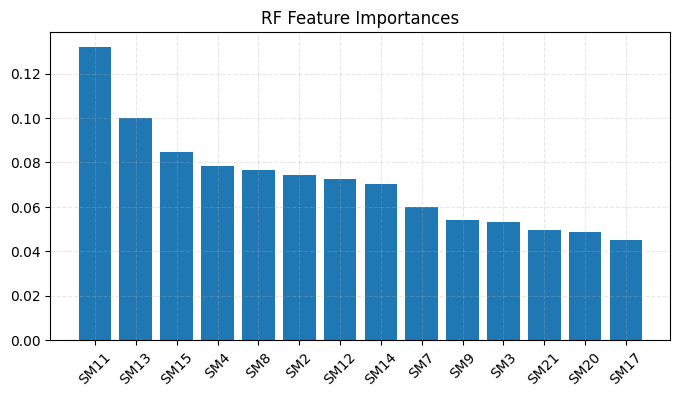

In [44]:
importances = pd.Series(clf_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,4))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45)
plt.title("RF Feature Importances")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


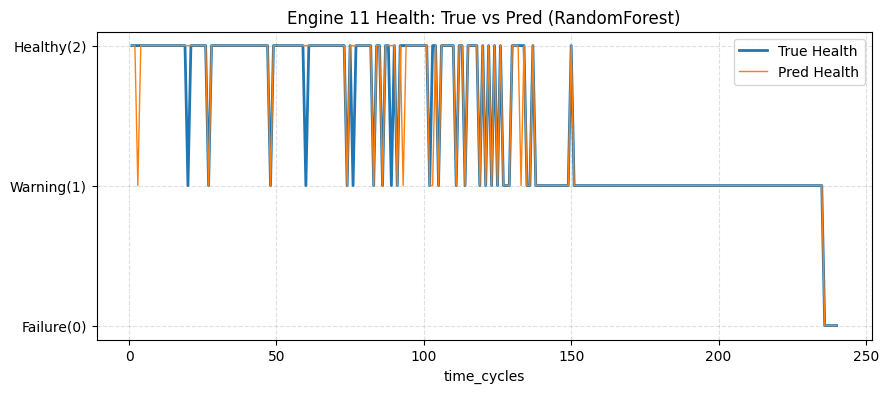

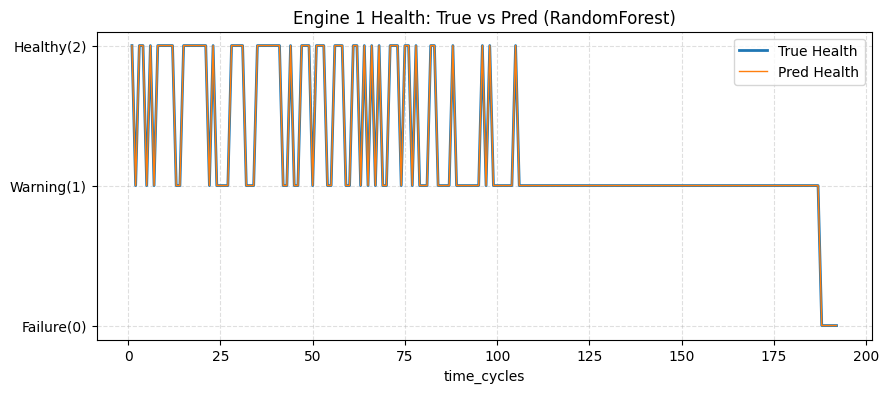

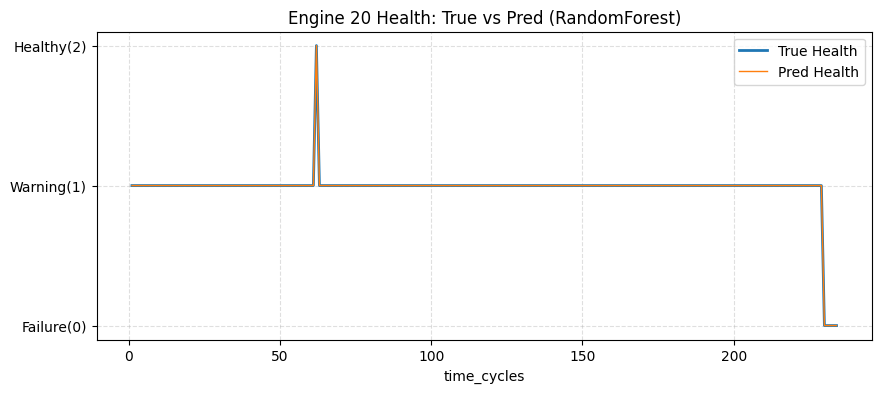

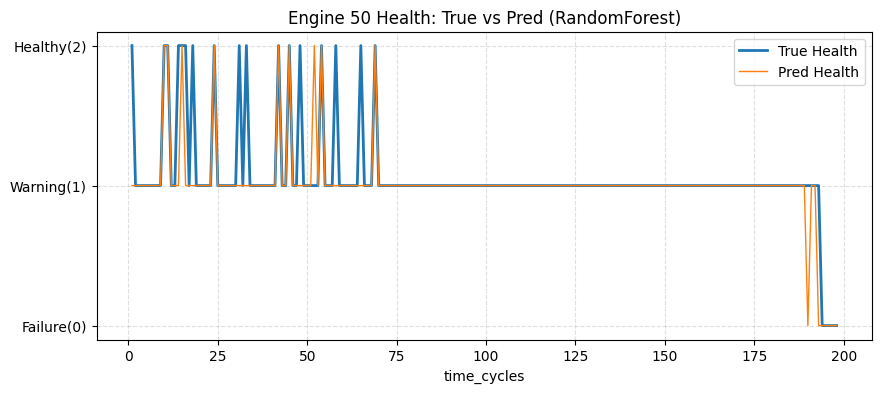

In [45]:
def plot_engine_pred(engine_id, model, title_suffix=""):
    sub = df_process[df_process["unit_nr"] == engine_id].sort_values("time_cycles")
    X_sub = sub[selected_features].values
    y_true = sub["Health"].values.astype(int)
    y_pred = model.predict(X_sub)

    plt.figure(figsize=(10,4))
    plt.plot(sub["time_cycles"], y_true, label="True Health", linewidth=2)
    plt.plot(sub["time_cycles"], y_pred, label="Pred Health", linewidth=1)
    plt.yticks([0,1,2], ["Failure(0)","Warning(1)","Healthy(2)"])
    plt.xlabel("time_cycles")
    plt.title(f"Engine {engine_id} Health: True vs Pred {title_suffix}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()

# 选几个发动机看看（包含 11）
for eid in [11, 1, 20, 50]:
    plot_engine_pred(eid, clf_rf, "(RandomForest)")


In [46]:
# ======== 强制对齐论文的 state 编码 ========
# paper: 0=Healthy, 1=Warning, 2=Failure

health_map = {
    2: 0,  # Healthy -> 0
    1: 1,  # Warning -> 1
    0: 2   # Failure -> 2
}

df_process['Health_RL'] = df_process['Health'].map(health_map).astype(int)

print("Health (old) -> Health_RL (paper-aligned) counts:")
print(df_process[['Health', 'Health_RL']].value_counts().sort_index())


Health (old) -> Health_RL (paper-aligned) counts:
Health  Health_RL
0       2            14179
1       1            91109
2       0            55071
Name: count, dtype: int64


In [47]:
import numpy as np
import pandas as pd

# paper-aligned state: 0=Healthy, 1=Warning, 2=Failure
assert set(df_process["Health_RL"].unique()).issubset({0,1,2})

# 统计 n_ij：同一台发动机相邻时刻的状态转移
df_sorted = df_process.sort_values(["unit_nr", "time_cycles"]).copy()
df_sorted["next_state"] = df_sorted.groupby("unit_nr")["Health_RL"].shift(-1)

pairs = df_sorted.dropna(subset=["next_state"]).copy()
pairs["next_state"] = pairs["next_state"].astype(int)

n_ij = np.zeros((3,3), dtype=int)
for i, j in zip(pairs["Health_RL"].values.astype(int), pairs["next_state"].values.astype(int)):
    n_ij[i, j] += 1

row_sums = n_ij.sum(axis=1, keepdims=True)
P0 = np.divide(n_ij, row_sums, out=np.zeros_like(n_ij, dtype=float), where=row_sums!=0)

print("n_ij counts:\n", n_ij)
print("\nP0 (no repair) from data (Eq.11):\n", np.round(P0, 5))
print("\nRow sums:", P0.sum(axis=1))


n_ij counts:
 [[33980 21012    79]
 [20737 68070  2302]
 [    0  1672 11798]]

P0 (no repair) from data (Eq.11):
 [[0.61702 0.38154 0.00143]
 [0.22761 0.74713 0.02527]
 [0.      0.12413 0.87587]]

Row sums: [1. 1. 1.]


In [48]:
# ===== 修正 P1 (小修) 转移矩阵 =====
# 论文语义：小修是"不完美修复"，应该能改善状态但不能完全恢复
# 关键修正：小修对 Failure 状态应该有一定效果（比如恢复到 Warning）

P1 = np.zeros((3,3), dtype=float)
P2 = np.zeros((3,3), dtype=float)

# minor repair: 不完美修复
# Healthy -> 保持 Healthy（小修对健康状态没必要但无害）
P1[0,0] = 1.0
# Warning -> 有 80% 概率恢复 Healthy，20% 留在 Warning
P1[1,0] = 0.8
P1[1,1] = 0.2
# Failure -> 小修只能部分恢复：70% 到 Warning，30% 留在 Failure
P1[2,1] = 0.7
P1[2,2] = 0.3

# major repair: 完美修复，总是恢复到 Healthy
P2[0,0] = 1.0
P2[1,0] = 1.0
P2[2,0] = 1.0

print("P1 (minor repair) - 修正后:\n", P1)
print("\nP2 (major repair):\n", P2)

P1 (minor repair) - 修正后:
 [[1.  0.  0. ]
 [0.8 0.2 0. ]
 [0.  0.7 0.3]]

P2 (major repair):
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [49]:
import numpy as np
import random

# =========================
# 0) You must define P0, P1, P2 before running this cell
#    Each is a 3x3 transition matrix: P[a][s, s_next]
# =========================
try:
    P0; P1; P2
except NameError as e:
    raise NameError("Please define P0, P1, P2 (each 3x3) before running this code.") from e

def _check_transition_matrix(P, name):
    P = np.array(P, dtype=float)
    if P.shape != (3, 3):
        raise ValueError(f"{name} must be shape (3,3), got {P.shape}")
    row_sums = P.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-6):
        raise ValueError(f"{name} rows must sum to 1. Row sums = {row_sums}")
    if np.any(P < -1e-12):
        raise ValueError(f"{name} has negative probabilities.")
    return P

P0 = _check_transition_matrix(P0, "P0")
P1 = _check_transition_matrix(P1, "P1")
P2 = _check_transition_matrix(P2, "P2")

# =========================
# 1) Costs / Rewards
# =========================
R_action = np.array([0.0, -20.0, -40.0])  # a=0,1,2
state_cost = {0: 0.0, 1: -5.0, 2: -10.0}

# =========================
# 2) Hyperparams
# =========================
N_total = 200
iters_per_epoch = 400  # max steps per episode (但 major repair 会提前终止)
gamma = 0.99
lr = 0.01

eps_min = 1.0 / N_total
eps_max = 1.0
eps_decay = -0.1

def epsilon(epoch_idx):
    return eps_min + (eps_max - eps_min) * np.exp(eps_decay * epoch_idx)

# =========================
# 3) MDP definition
# =========================
P_by_action = [P0, P1, P2]

# 【论文口径】不做动作约束：允许在任何状态选择任何动作
# 删除 valid_actions 限制

def sample_next_state(s, a):
    """采样下一状态（用于非 major 动作）"""
    probs = P_by_action[a][s]
    return int(np.random.choice([0, 1, 2], p=probs))

# =========================
# 4) Q-table (无动作屏蔽)
# =========================
Q = np.zeros((3, 3), dtype=float)  # 所有 (s,a) 都可选

def _argmax_tie_break(values):
    """Return index of max value, break ties randomly."""
    values = np.asarray(values, dtype=float)
    maxv = np.max(values)
    idxs = np.where(values == maxv)[0]
    return int(np.random.choice(idxs))

def choose_action(s, eps):
    """Epsilon-greedy 选动作（无动作屏蔽）"""
    if random.random() < eps:
        return random.randint(0, 2)  # 随机选 0,1,2
    return _argmax_tie_break(Q[s, :])

def max_q_next(s_next):
    return np.max(Q[s_next, :])

def greedy_policy(Q):
    policy = []
    for s in range(3):
        policy.append(_argmax_tie_break(Q[s, :]))
    return np.array(policy, dtype=int)

# =========================
# 5) Training
#    【论文口径】Major repair (a=2) 将系统恢复到健康状态(s=0)并终止 episode
# =========================
epoch_cost_sum = []
epoch_cost_avg = []
epoch_minor_count = []
epoch_major_count = []
epoch_steps = []  # 每个 epoch 的实际步数
epoch_a_counts = []

print("=" * 60)
print("开始训练 (表格型 Q-learning)")
print("=" * 60)
print(f"【论文口径】")
print(f"  - Major repair (a=2) 将系统恢复到 s=0 (健康) 并终止 episode")
print(f"  - 不做动作约束：允许在任何状态选择任何动作")
print(f"  - Episode 长度不固定（major repair 会提前终止）")
print("=" * 60)

for ep in range(N_total):
    eps = float(epsilon(ep))
    total_cost_pos = 0.0
    action_counts = np.zeros(3, dtype=int)

    # 起始状态随机
    s = int(np.random.choice([0, 1, 2]))

    done = False
    step_count = 0

    for it in range(iters_per_epoch):
        if done:
            break

        a = choose_action(s, eps)
        action_counts[a] += 1
        step_count += 1

        # 【论文口径】Major repair 处理
        if a == 2:
            # Major repair: 系统恢复到健康状态 s=0，episode 终止
            s_next = 0  # 健康状态
            done = True
            r = float(R_action[a]) + float(state_cost[s_next])  # s_next=0, cost=0
        else:
            # No repair 或 Minor repair: 按转移矩阵采样
            s_next = sample_next_state(s, a)
            r = float(R_action[a]) + float(state_cost[s_next])

        total_cost_pos += -r

        # Q-learning update
        if done:
            # Terminal state: no future reward
            Q[s, a] = (1 - lr) * Q[s, a] + lr * r
        else:
            Q[s, a] = (1 - lr) * Q[s, a] + lr * (r + gamma * max_q_next(s_next))

        s = s_next

    epoch_cost_sum.append(total_cost_pos)
    epoch_cost_avg.append(total_cost_pos / max(step_count, 1))
    epoch_minor_count.append(action_counts[1])
    epoch_major_count.append(action_counts[2])
    epoch_steps.append(step_count)
    epoch_a_counts.append(action_counts.copy())

print("\n✅ Training done.")
print("\nQ-table:")
print(np.round(Q, 3))
print(f"\nGreedy policy (a for s=0,1,2): {greedy_policy(Q)}")
print(f"\nLast 10 epochs 统计:")
print(f"  Avg steps per episode: {np.mean(epoch_steps[-10:]):.1f}")
print(f"  Avg cost per episode: {np.mean(epoch_cost_sum[-10:]):.2f}")
print(f"  Avg minor actions: {np.mean(epoch_minor_count[-10:]):.2f}")
print(f"  Avg major actions: {np.mean(epoch_major_count[-10:]):.2f}")

# =========================
# 6) Evaluation
# =========================
eval_runs = 2000
eval_horizon = iters_per_epoch

def greedy_action(Q, s):
    return _argmax_tie_break(Q[s, :])

eval_total_cost = []
eval_total_steps = []
eval_minor_counts = []
eval_major_counts = []

for _ in range(eval_runs):
    s = int(np.random.choice([0, 1, 2]))
    total_cost_pos = 0.0
    action_counts = np.zeros(3, dtype=int)
    steps = 0
    done = False

    for t in range(eval_horizon):
        if done:
            break

        a = greedy_action(Q, s)
        action_counts[a] += 1
        steps += 1

        if a == 2:
            # Major repair: 恢复到健康，终止
            s_next = 0
            done = True
            r = float(R_action[a]) + float(state_cost[s_next])
        else:
            s_next = sample_next_state(s, a)
            r = float(R_action[a]) + float(state_cost[s_next])

        total_cost_pos += -r
        s = s_next

    eval_total_cost.append(total_cost_pos)
    eval_total_steps.append(steps)
    eval_minor_counts.append(action_counts[1])
    eval_major_counts.append(action_counts[2])

print("\n" + "=" * 60)
print("=== Table 3 Style (evaluation averages) ===")
print("=" * 60)
print(f"Total cost (per episode):     {np.mean(eval_total_cost):.2f} ± {np.std(eval_total_cost):.2f}")
print(f"Total actions (per episode):  {np.mean(eval_total_steps):.2f} ± {np.std(eval_total_steps):.2f}")
print(f"Average minor actions:        {np.mean(eval_minor_counts):.2f}")
print(f"Average major actions:        {np.mean(eval_major_counts):.2f}")
print(f"\n【注意】Episode 长度不固定 (major repair 会提前终止)")
print(f"  - 如果策略经常选 major，则 episode 较短")
print(f"  - 如果策略从不选 major，则 episode 固定为 {eval_horizon} 步")

开始训练 (表格型 Q-learning)
【论文口径】
  - Major repair (a=2) 将系统恢复到 s=0 (健康) 并终止 episode
  - 不做动作约束：允许在任何状态选择任何动作
  - Episode 长度不固定（major repair 会提前终止）

✅ Training done.

Q-table:
[[-20.137 -20.239 -20.206]
 [-23.173 -23.293 -23.315]
 [-13.809 -13.974 -14.036]]

Greedy policy (a for s=0,1,2): [0 0 0]

Last 10 epochs 统计:
  Avg steps per episode: 7.4
  Avg cost per episode: 77.50
  Avg minor actions: 1.00
  Avg major actions: 1.00

=== Table 3 Style (evaluation averages) ===
Total cost (per episode):     1583.48 ± 187.35
Total actions (per episode):  400.00 ± 0.00
Average minor actions:        0.00
Average major actions:        0.00

【注意】Episode 长度不固定 (major repair 会提前终止)
  - 如果策略经常选 major，则 episode 较短
  - 如果策略从不选 major，则 episode 固定为 400 步


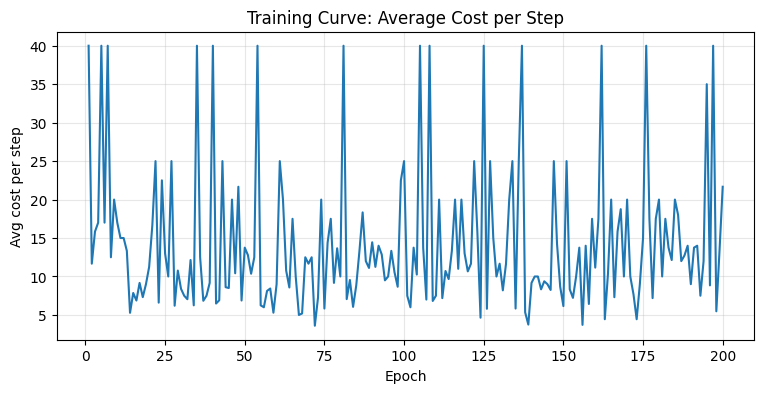

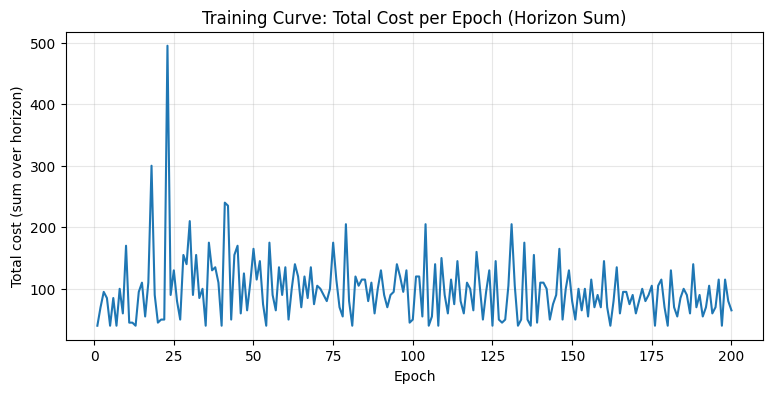

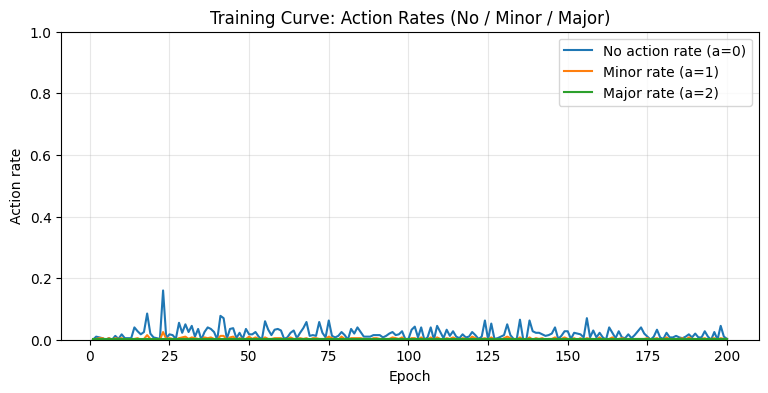

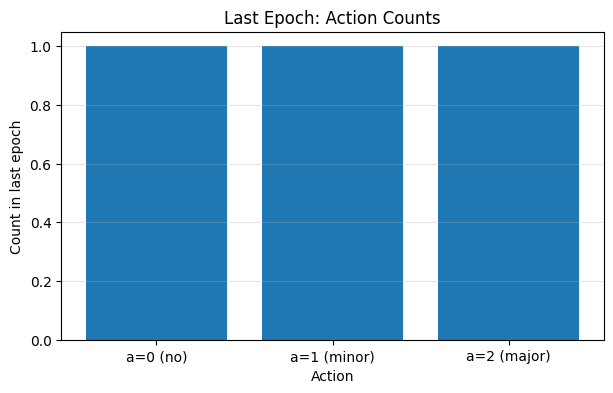

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 0) Basic sanity checks =====
# 【修复】使用实际存在的变量名 epoch_minor_count 和 epoch_major_count
need_vars = ["epoch_cost_avg", "epoch_cost_sum", "epoch_minor_count", "epoch_major_count", "epoch_a_counts", "Q", "iters_per_epoch"]
missing = [v for v in need_vars if v not in globals()]
if missing:
    raise NameError(f"Missing variables in scope: {missing}. Run training cell first.")

epochs = np.arange(1, len(epoch_cost_avg) + 1)

# 【修复】从 count 计算 rate
epoch_minor_rate = np.array(epoch_minor_count) / iters_per_epoch
epoch_major_rate = np.array(epoch_major_count) / iters_per_epoch

# ===== 1) Avg cost per step (best for comparing trends) =====
plt.figure(figsize=(9, 4))
plt.plot(epochs, epoch_cost_avg)
plt.xlabel("Epoch")
plt.ylabel("Avg cost per step")
plt.title("Training Curve: Average Cost per Step")
plt.grid(True, alpha=0.3)
plt.show()

# ===== 2) Total cost per epoch (400-step sum) =====
plt.figure(figsize=(9, 4))
plt.plot(epochs, epoch_cost_sum)
plt.xlabel("Epoch")
plt.ylabel("Total cost (sum over horizon)")
plt.title("Training Curve: Total Cost per Epoch (Horizon Sum)")
plt.grid(True, alpha=0.3)
plt.show()

# ===== 3) Action rates (no / minor / major) per epoch =====
# Use epoch_a_counts (more robust than 1 - minor - major)
counts = np.array(epoch_a_counts, dtype=float)  # shape (N_total, 3)
rate_no    = counts[:, 0] / iters_per_epoch
rate_minor = counts[:, 1] / iters_per_epoch
rate_major = counts[:, 2] / iters_per_epoch

plt.figure(figsize=(9, 4))
plt.plot(epochs, rate_no,    label="No action rate (a=0)")
plt.plot(epochs, rate_minor, label="Minor rate (a=1)")
plt.plot(epochs, rate_major, label="Major rate (a=2)")
plt.xlabel("Epoch")
plt.ylabel("Action rate")
plt.title("Training Curve: Action Rates (No / Minor / Major)")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ===== 4) Last epoch action counts bar =====
last_counts = np.array(epoch_a_counts[-1], dtype=int)  # [count_a0, count_a1, count_a2]
plt.figure(figsize=(7, 4))
plt.bar(["a=0 (no)", "a=1 (minor)", "a=2 (major)"], last_counts)
plt.xlabel("Action")
plt.ylabel("Count in last epoch")
plt.title("Last Epoch: Action Counts")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# DRL部分

In [53]:
# ==========================================
# DRL 0. 变量扫描 & 配置
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# 设置随机种子保证可复现性
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 扫描 notebook 变量，定位列名
UNIT_COL = 'unit_nr'
AGE_COL = 'time_cycles'
RISK_COL = 'HR'  # 使用连续的 hazard risk

# 验证变量存在
assert UNIT_COL in df_process.columns, f"Missing {UNIT_COL}"
assert AGE_COL in df_process.columns, f"Missing {AGE_COL}"
assert RISK_COL in df_process.columns, f"Missing {RISK_COL}"

# 复用 notebook 已有的 R_action
if 'R_action' in dir():
    print("Using existing R_action:", R_action)
else:
    R_action = np.array([0.0, -20.0, -40.0])
    print("Fallback R_action:", R_action)

print(f"\nColumn mapping: UNIT={UNIT_COL}, AGE={AGE_COL}, RISK={RISK_COL}")
print(f"df_process shape: {df_process.shape}")
print(f"Total units: {df_process[UNIT_COL].nunique()}")

Using existing R_action: [  0. -20. -40.]

Column mapping: UNIT=unit_nr, AGE=time_cycles, RISK=HR
df_process shape: (160359, 29)
Total units: 709


In [54]:
# ==========================================
# DRL 1. Minor Repair 定义：age rollback + hazard reduction + diminishing returns
# ==========================================

# ----- Minor repair 参数（可调）-----
R0 = 0.30       # age rollback 基础比例
ETA0 = 0.25     # hazard reduction 基础比例
DECAY = 0.15    # 衰减率（k_minor 增加时效果递减）

# ----- 计算 h_min（防止 "better than new"）-----
# 使用前 5 个 cycle 的 hazard risk 的 1% 分位数
early_cycles = df_process[df_process[AGE_COL] <= 5][RISK_COL].values
h_min = max(np.percentile(early_cycles, 1), 1e-6)
print(f"h_min (防止过度修复): {h_min:.6e}")

# 全局 hazard 统计
h_global_min = df_process[RISK_COL].min()
h_global_max = df_process[RISK_COL].max()
h_global_median = df_process[RISK_COL].median()
print(f"Hazard risk 统计: min={h_global_min:.4e}, median={h_global_median:.4e}, max={h_global_max:.4e}")

def compute_minor_repair_effectiveness(k_minor):
    """
    计算第 k_minor 次小修的效果（含衰减）
    返回: r_k (age rollback ratio), eta_k (hazard reduction ratio)
    """
    r_k = R0 * np.exp(-DECAY * k_minor)
    eta_k = ETA0 * np.exp(-DECAY * k_minor)
    return r_k, eta_k

def apply_minor_repair(age_current, h_current, k_minor, unit_df):
    """
    执行小修：
    1. 计算衰减后的效果 r_k, eta_k
    2. age_after = floor((1 - r_k) * age_current)
    3. 映射回该 unit 的历史轨迹找到对应的 hazard
    4. h_after = max(h_min, (1 - eta_k) * h_from_traj)
    5. 关键约束: h_after 不能大于 h_current（小修不能让情况变差）

    返回: (age_after, h_after, fallback_flag)
    """
    r_k, eta_k = compute_minor_repair_effectiveness(k_minor)

    # Age rollback
    age_after = int(np.floor((1 - r_k) * age_current))
    age_after = max(age_after, 1)  # 至少为 1

    # 映射回轨迹：找 time_cycles 最接近 age_after 且 <= age_current 的行
    fallback = False
    candidates = unit_df[unit_df[AGE_COL] <= age_after]

    if len(candidates) > 0:
        # 找最接近 age_after 的
        matched_row = candidates.iloc[(candidates[AGE_COL] - age_after).abs().argmin()]
        h_from_traj = matched_row[RISK_COL]
        age_after = int(matched_row[AGE_COL])
    else:
        # Fallback: 找该 unit 最小的 age
        matched_row = unit_df.iloc[0]
        h_from_traj = matched_row[RISK_COL]
        age_after = int(matched_row[AGE_COL])
        fallback = True

    # Hazard reduction: 基于映射回的轨迹点应用折扣
    h_after_raw = (1 - eta_k) * h_from_traj

    # 关键约束: h_after 不能大于 h_current（小修不能让情况变差）
    # 同时不能低于 h_min（不能比全新还好）
    h_after = max(h_min, min(h_after_raw, h_current))

    return age_after, h_after, fallback

print("\nMinor repair 参数:")
print(f"  R0={R0}, ETA0={ETA0}, DECAY={DECAY}")
print(f"  k=0 时: r_k={R0:.3f}, eta_k={ETA0:.3f}")
print(f"  k=3 时: r_k={R0*np.exp(-DECAY*3):.3f}, eta_k={ETA0*np.exp(-DECAY*3):.3f}")
print(f"  k=5 时: r_k={R0*np.exp(-DECAY*5):.3f}, eta_k={ETA0*np.exp(-DECAY*5):.3f}")

h_min (防止过度修复): 4.218813e-06
Hazard risk 统计: min=1.3326e-07, median=1.4323e+00, max=1.4565e+05

Minor repair 参数:
  R0=0.3, ETA0=0.25, DECAY=0.15
  k=0 时: r_k=0.300, eta_k=0.250
  k=3 时: r_k=0.191, eta_k=0.159
  k=5 时: r_k=0.142, eta_k=0.118


In [55]:
# ==========================================
# DRL 2. Sanity Check #1: 小修应该降低 hazard 且不低于 h_min
# ==========================================

print("=" * 60)
print("Sanity Check #1: Minor repair reduces hazard but not below h_min")
print("=" * 60)

N_samples = 1000
violations_reduce = []
violations_lower_bound = []

# 随机采样 N 个状态
sampled_rows = df_process.sample(n=N_samples, random_state=SEED)

for idx, row in sampled_rows.iterrows():
    unit_id = row[UNIT_COL]
    age_before = int(row[AGE_COL])
    h_before = row[RISK_COL]

    # 获取该 unit 的完整轨迹
    unit_df = df_process[df_process[UNIT_COL] == unit_id].sort_values(AGE_COL)

    # 执行一次小修 (k_minor=0)
    age_after, h_after, fallback = apply_minor_repair(age_before, h_before, k_minor=0, unit_df=unit_df)

    # 检查约束
    tol = 1e-9
    if h_after > h_before + tol:
        violations_reduce.append({
            'unit_id': unit_id, 'age': age_before,
            'h_before': h_before, 'h_after': h_after,
            'delta': h_after - h_before
        })

    if h_after < h_min - tol:
        violations_lower_bound.append({
            'unit_id': unit_id, 'age': age_before,
            'h_before': h_before, 'h_after': h_after
        })

print(f"\n采样数: {N_samples}")
print(f"违反「h_after <= h_before」的数量: {len(violations_reduce)}")
print(f"违反「h_after >= h_min」的数量: {len(violations_lower_bound)}")

if len(violations_reduce) > 0:
    print("\n⚠️ Top 5 违反 reduce 约束的样本:")
    for v in violations_reduce[:5]:
        print(f"  unit={v['unit_id']}, age={v['age']}, h_before={v['h_before']:.4e}, h_after={v['h_after']:.4e}, delta={v['delta']:.4e}")
    print("  建议: 降低 ETA0 或检查轨迹映射逻辑")

if len(violations_lower_bound) > 0:
    print("\n⚠️ Top 5 违反 lower bound 约束的样本:")
    for v in violations_lower_bound[:5]:
        print(f"  unit={v['unit_id']}, age={v['age']}, h_before={v['h_before']:.4e}, h_after={v['h_after']:.4e}")
    print("  建议: 提高 h_min 分位数")

if len(violations_reduce) == 0 and len(violations_lower_bound) == 0:
    print("\n✅ Sanity Check #1 通过: 小修正确降低 hazard 且不低于 h_min")

Sanity Check #1: Minor repair reduces hazard but not below h_min

采样数: 1000
违反「h_after <= h_before」的数量: 1
违反「h_after >= h_min」的数量: 0

⚠️ Top 5 违反 reduce 约束的样本:
  unit=703.0, age=140, h_before=1.0932e-06, h_after=4.2188e-06, delta=3.1256e-06
  建议: 降低 ETA0 或检查轨迹映射逻辑


In [56]:
# ==========================================
# DRL 3. Sanity Check #2: 连续小修边际收益递减
# ==========================================

print("=" * 60)
print("Sanity Check #2: Diminishing returns for repeated minor repairs")
print("=" * 60)

M_samples = 200
K_repeats = 5

# 存储每次小修的 delta
deltas_by_step = {k: [] for k in range(K_repeats)}

# 随机采样 M 个起始状态
sampled_starts = df_process.sample(n=M_samples, random_state=SEED+1)

for idx, row in sampled_starts.iterrows():
    unit_id = row[UNIT_COL]
    unit_df = df_process[df_process[UNIT_COL] == unit_id].sort_values(AGE_COL)

    age_curr = int(row[AGE_COL])
    h_curr = row[RISK_COL]

    for k in range(K_repeats):
        # 执行第 k 次小修
        age_next, h_next, _ = apply_minor_repair(age_curr, h_curr, k_minor=k, unit_df=unit_df)

        delta = h_curr - h_next  # 正值表示 hazard 降低
        deltas_by_step[k].append(delta)

        # 更新状态（但不沿轨迹前进，只是连续小修）
        age_curr = age_next
        h_curr = h_next

# 计算统计量
print(f"\n采样数: {M_samples}, 连续小修次数: {K_repeats}")
print("\n步骤  | 平均 delta | 标准差 delta | 正值比例")
print("-" * 50)

mean_deltas = []
for k in range(K_repeats):
    deltas = np.array(deltas_by_step[k])
    mean_d = np.mean(deltas)
    std_d = np.std(deltas)
    positive_rate = np.mean(deltas > 0)
    mean_deltas.append(mean_d)
    print(f"  {k+1}   |  {mean_d:+.4e}  |  {std_d:.4e}  |  {positive_rate:.2%}")

# 检查边际收益是否递减
violations = 0
for k in range(1, K_repeats):
    if mean_deltas[k] > mean_deltas[k-1] + 1e-9:
        violations += 1

print(f"\n边际收益递减违反次数: {violations}/{K_repeats-1}")

if violations == 0:
    print("✅ Sanity Check #2 通过: 连续小修边际收益递减")
else:
    print("⚠️ 存在违反: 考虑增大 DECAY 参数")

Sanity Check #2: Diminishing returns for repeated minor repairs

采样数: 200, 连续小修次数: 5

步骤  | 平均 delta | 标准差 delta | 正值比例
--------------------------------------------------
  1   |  +6.9991e+02  |  5.6048e+03  |  64.00%
  2   |  +3.4281e+00  |  1.3900e+01  |  49.00%
  3   |  +7.4444e-01  |  5.1077e+00  |  30.00%
  4   |  +1.0964e-01  |  6.0802e-01  |  26.50%
  5   |  +6.3774e-02  |  3.5240e-01  |  20.50%

边际收益递减违反次数: 0/4
✅ Sanity Check #2 通过: 连续小修边际收益递减


In [57]:
# ==========================================
# DRL 4. 环境定义: MaintenanceEnv (连续 state)
# ==========================================
"""
【论文口径】Major maintenance (a=2) 的处理：
  "major maintenance will bring the system to healthy state,
   thus each epoch terminates if major repair action is taken (a=2)"

实现要点：
1. action==2 时：done=True，next_state 重置为 healthy (hazard=h_min, age=0)
2. 不做动作屏蔽：允许在任何状态选择 a=2
3. episode 长度不固定（major repair 会提前终止）
"""

class MaintenanceEnv:
    """
    维护决策环境（连续 state 版本）
    - state: (hazard_risk, age) 连续值，归一化到 [0,1]
    - action: 0=no repair, 1=minor repair, 2=major repair
    - 基于真实轨迹数据驱动

    【论文口径】
    - Major repair (a=2) 将系统恢复到健康状态并终止当前 episode
    - 不做动作约束，允许在任何状态选择任何动作
    """

    def __init__(self, df, unit_col, age_col, risk_col, r_action,
                 h_min, r0=0.30, eta0=0.25, decay=0.15, max_steps=400):
        self.df = df.copy()
        self.unit_col = unit_col
        self.age_col = age_col
        self.risk_col = risk_col
        self.r_action = r_action
        self.h_min = h_min
        self.r0 = r0
        self.eta0 = eta0
        self.decay = decay
        self.max_steps = max_steps

        # 按 unit 分组并排序
        self.units = df[unit_col].unique()
        self.unit_trajectories = {}
        for u in self.units:
            self.unit_trajectories[u] = df[df[unit_col] == u].sort_values(age_col).reset_index(drop=True)

        # 状态归一化参数
        self.h_max = df[risk_col].max()
        self.age_max = df[age_col].max()

        self.reset()

    def reset(self, unit_id=None):
        """重置环境，开始新 episode"""
        if unit_id is None:
            self.current_unit = np.random.choice(self.units)
        else:
            self.current_unit = unit_id

        self.unit_df = self.unit_trajectories[self.current_unit].copy()
        self.current_idx = 0
        self.k_minor = 0  # 小修次数计数器
        self.steps = 0
        self.done = False

        row = self.unit_df.iloc[self.current_idx]
        self.current_h = row[self.risk_col]
        self.current_age = int(row[self.age_col])

        return self._get_state()

    def _get_state(self):
        """返回归一化后的状态向量"""
        h_norm = self.current_h / (self.h_max + 1e-12)
        age_norm = self.current_age / (self.age_max + 1e-12)
        return np.array([h_norm, age_norm], dtype=np.float32)

    def _get_healthy_state(self):
        """返回健康状态的归一化向量（用于 major repair 后）"""
        h_norm = self.h_min / (self.h_max + 1e-12)
        age_norm = 0.0  # age 重置为 0
        return np.array([h_norm, age_norm], dtype=np.float32)

    def _compute_minor_effectiveness(self):
        """计算当前小修效果（含衰减）"""
        r_k = self.r0 * np.exp(-self.decay * self.k_minor)
        eta_k = self.eta0 * np.exp(-self.decay * self.k_minor)
        return r_k, eta_k

    def step(self, action):
        """
        执行动作，返回 (next_state, reward, done, info)

        【论文口径】
        - action==2 (major repair): done=True, next_state 重置为健康状态
        - action==0,1: done=False (除非到达轨迹末尾或 max_steps)
        - 不做动作屏蔽：允许在任何状态选择 a=2
        """
        if self.done:
            raise ValueError("Episode already done. Call reset().")

        info = {
            'action': action,
            'unit': self.current_unit,
            'k_minor': self.k_minor,
            'major_repair': False  # 默认
        }
        reward = float(self.r_action[action])

        # ===== Action 0: No repair =====
        if action == 0:
            self.current_idx += 1
            if self.current_idx >= len(self.unit_df):
                self.done = True
                info['termination'] = 'end_of_trajectory'
            else:
                row = self.unit_df.iloc[self.current_idx]
                self.current_h = row[self.risk_col]
                self.current_age = int(row[self.age_col])

        # ===== Action 1: Minor repair =====
        elif action == 1:
            r_k, eta_k = self._compute_minor_effectiveness()

            # Age rollback
            age_after = int(np.floor((1 - r_k) * self.current_age))
            age_after = max(age_after, 1)

            # 映射回轨迹
            candidates = self.unit_df[self.unit_df[self.age_col] <= age_after]
            if len(candidates) > 0:
                matched_idx = (candidates[self.age_col] - age_after).abs().idxmin()
                matched_row = self.unit_df.loc[matched_idx]
                h_from_traj = matched_row[self.risk_col]
                rollback_idx = self.unit_df.index.get_loc(matched_idx)
            else:
                # Fallback to first row
                matched_row = self.unit_df.iloc[0]
                h_from_traj = matched_row[self.risk_col]
                rollback_idx = 0
                info['fallback'] = True

            # Hazard reduction - 添加约束：小修不能让情况变差
            h_before = self.current_h
            h_after_raw = (1 - eta_k) * h_from_traj
            # 关键约束: h_after 在 [h_min, h_before] 范围内
            self.current_h = max(self.h_min, min(h_after_raw, h_before))
            self.current_age = int(matched_row[self.age_col])

            self.k_minor += 1
            info['r_k'] = r_k
            info['eta_k'] = eta_k

            # 小修后推进一个时间步（从回滚位置向前一步）
            self.current_idx = rollback_idx + 1
            if self.current_idx >= len(self.unit_df):
                self.done = True
                info['termination'] = 'end_of_trajectory_after_minor'
            else:
                row = self.unit_df.iloc[self.current_idx]
                self.current_age = int(row[self.age_col])

        # ===== Action 2: Major repair =====
        elif action == 2:
            # 【论文口径】Major repair 将系统恢复到健康状态并终止 episode
            self.done = True
            info['termination'] = 'major_repair'
            info['major_repair'] = True

            # 重置内部状态到健康状态（虽然 episode 结束了，但 next_state 应反映健康状态）
            self.current_h = self.h_min
            self.current_age = 0
            self.k_minor = 0  # 小修计数器也重置

        self.steps += 1
        if self.steps >= self.max_steps and not self.done:
            self.done = True
            info['termination'] = 'max_steps'

        return self._get_state(), reward, self.done, info

# 创建环境实例
env = MaintenanceEnv(
    df=df_process,
    unit_col=UNIT_COL,
    age_col=AGE_COL,
    risk_col=RISK_COL,
    r_action=R_action,
    h_min=h_min,
    r0=R0,
    eta0=ETA0,
    decay=DECAY,
    max_steps=400
)

print("=" * 60)
print("MaintenanceEnv 创建完成")
print("=" * 60)
print(f"  Units: {len(env.units)}")
print(f"  State dim: 2 (h_norm, age_norm)")
print(f"  Action space: 3 (no repair, minor, major)")
print(f"  Max steps per episode: {env.max_steps}")
print(f"\n【论文口径】")
print(f"  - Major repair (a=2) 将系统恢复到健康状态并终止 episode")
print(f"  - 不做动作约束：允许在任何状态选择任何动作")
print(f"  - Episode 长度不固定（major repair 会提前终止）")

# ==========================================
# 自检验证：Major repair 正确性测试
# ==========================================
print("\n" + "=" * 60)
print("🔍 自检验证: Major Repair 正确性")
print("=" * 60)

# 测试 1: 从任意状态执行 major repair
test_state = env.reset()
print(f"\n[Test 1] 从随机状态执行 major repair")
print(f"  初始状态: h_norm={test_state[0]:.4f}, age_norm={test_state[1]:.4f}")

next_state, reward, done, info = env.step(2)  # major repair

# 验证
healthy_state = env._get_healthy_state()
assert done == True, f"ERROR: done should be True after major repair, got {done}"
assert info['major_repair'] == True, f"ERROR: major_repair flag should be True"
assert np.allclose(next_state, healthy_state, atol=1e-6), \
    f"ERROR: next_state should be healthy state. Got {next_state}, expected {healthy_state}"

print(f"  动作: 2 (major repair)")
print(f"  Reward: {reward}")
print(f"  Done: {done} ✅")
print(f"  Next state (healthy): h_norm={next_state[0]:.4f}, age_norm={next_state[1]:.4f} ✅")
print(f"  info['major_repair']: {info['major_repair']} ✅")

# 测试 2: 多次采样验证
print(f"\n[Test 2] 多次采样验证 major repair 一致性")
n_tests = 10
all_passed = True
for i in range(n_tests):
    state = env.reset()
    # 先执行几步随机动作（不含 major）
    for _ in range(np.random.randint(1, 5)):
        if env.done:
            break
        a = np.random.choice([0, 1])  # 不执行 major
        env.step(a)

    if not env.done:
        # 从当前状态执行 major repair
        current_state = env._get_state()
        next_state, reward, done, info = env.step(2)

        if not (done == True and info['major_repair'] == True):
            print(f"  Test {i+1}: FAILED - done={done}, major_repair={info.get('major_repair')}")
            all_passed = False

if all_passed:
    print(f"  {n_tests}/{n_tests} 测试通过 ✅")
else:
    print(f"  部分测试失败 ❌")

print("\n" + "=" * 60)
print("✅ 环境自检完成")
print("=" * 60)

MaintenanceEnv 创建完成
  Units: 709
  State dim: 2 (h_norm, age_norm)
  Action space: 3 (no repair, minor, major)
  Max steps per episode: 400

【论文口径】
  - Major repair (a=2) 将系统恢复到健康状态并终止 episode
  - 不做动作约束：允许在任何状态选择任何动作
  - Episode 长度不固定（major repair 会提前终止）

🔍 自检验证: Major Repair 正确性

[Test 1] 从随机状态执行 major repair
  初始状态: h_norm=0.0000, age_norm=0.0018
  动作: 2 (major repair)
  Reward: -40.0
  Done: True ✅
  Next state (healthy): h_norm=0.0000, age_norm=0.0000 ✅
  info['major_repair']: True ✅

[Test 2] 多次采样验证 major repair 一致性
  10/10 测试通过 ✅

✅ 环境自检完成


In [58]:
# ==========================================
# DRL 5. Replay Buffer
# ==========================================

class ReplayBuffer:
    """经验回放缓冲区"""

    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

print("ReplayBuffer 定义完成")

ReplayBuffer 定义完成


In [59]:
# ==========================================
# DRL 6. Q-Network (标准 DQN: 线性输出)
# ==========================================

class QNetwork(nn.Module):
    """
    标准 DQN Q-Network：
    - 输入: 2 维 (h_norm, age_norm)
    - 隐藏层: 512 节点, ReLU 激活 (比 sigmoid 更稳定)
    - 输出: 3 维, **线性输出** (标准 Q 值回归)

    【修改说明】
    原代码使用 softmax 输出，这与 DQN 的 TD 回归损失不兼容：
    - softmax 输出受限于 (0,1) 且和为 1
    - TD target 可以是任意实数
    - 导致目标与输出空间不匹配，引发动作塌缩

    标准 DQN 使用线性输出层，让 Q 值可以是任意实数。
    """

    def __init__(self, state_dim=2, action_dim=3, hidden_dim=512):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 使用 ReLU 替代 sigmoid (更稳定的梯度)
        x = self.fc2(x)              # 【关键】线性输出，无 softmax
        return x

# 创建网络
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_net = QNetwork().to(device)
target_net = QNetwork().to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()  # target network 始终处于 eval 模式

print(f"QNetwork 创建完成 (device: {device})")
print(f"【重要修改】输出层: 线性 (无 softmax)")
print(q_net)

# 测试前向传播
test_state = torch.tensor([[0.5, 0.3]], dtype=torch.float32).to(device)
test_output = q_net(test_state)
print(f"\n测试输入: {test_state.cpu().numpy()}")
print(f"测试输出 (raw Q-values): {test_output.detach().cpu().numpy()}")

QNetwork 创建完成 (device: cpu)
【重要修改】输出层: 线性 (无 softmax)
QNetwork(
  (fc1): Linear(in_features=2, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
)

测试输入: [[0.5 0.3]]
测试输出 (raw Q-values): [[-0.03153381 -0.24921902 -0.13599409]]


In [60]:
# ==========================================
# DRL 7. 训练配置 & 辅助函数
# ==========================================

# ----- 超参数 (Paper) -----
DRL_EPOCHS = 200
DRL_GAMMA = 0.99
DRL_LR = 1e-3
DRL_BATCH_SIZE = 64
DRL_BUFFER_SIZE = 100000
DRL_EPS_MAX = 1.0
DRL_EPS_MIN = 1.0 / DRL_EPOCHS
DRL_EPS_DECAY = 0.1
DRL_TARGET_UPDATE = 10  # 每 10 个 epoch 更新 target network
DRL_GRAD_CLIP = 1.0

# ----- Epsilon schedule -----
def get_epsilon(epoch):
    return DRL_EPS_MIN + (DRL_EPS_MAX - DRL_EPS_MIN) * np.exp(-DRL_EPS_DECAY * epoch)

# ----- 选择动作 -----
def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randint(0, 2)
    else:
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = q_net(state_t)
            return q_values.argmax(dim=1).item()

# ----- Train/Test split by unit -----
all_units = df_process[UNIT_COL].unique()
np.random.seed(SEED)
np.random.shuffle(all_units)
split_idx = int(len(all_units) * 0.8)
train_units = all_units[:split_idx]
test_units = all_units[split_idx:]

print(f"DRL 超参数:")
print(f"  Epochs: {DRL_EPOCHS}")
print(f"  Gamma: {DRL_GAMMA}")
print(f"  Learning rate: {DRL_LR}")
print(f"  Batch size: {DRL_BATCH_SIZE}")
print(f"  Buffer size: {DRL_BUFFER_SIZE}")
print(f"  Epsilon: {DRL_EPS_MAX} -> {DRL_EPS_MIN}")
print(f"\n训练集 units: {len(train_units)}, 测试集 units: {len(test_units)}")

DRL 超参数:
  Epochs: 200
  Gamma: 0.99
  Learning rate: 0.001
  Batch size: 64
  Buffer size: 100000
  Epsilon: 1.0 -> 0.005

训练集 units: 567, 测试集 units: 142


In [ ]:
# ==========================================
# DRL 8. 训练/加载模型 (标准 DQN 版)
# ==========================================
"""
【论文口径实现】

1. Q-Network 输出：线性输出 3 个 Q 值（已在 DRL 6 中修改）
2. TD target：标准形式 target = r + gamma*(1-done)*max_a' Q_target(s',a')
3. Loss：HuberLoss (SmoothL1Loss)
4. Reward：直接使用原始 reward，不做归一化
5. Major repair (a=2)：立即终止 episode，状态重置为 healthy

【统计口径】
- Total cost: 累计 -(action_cost + state_cost)
- Episode steps: 每个 episode 的实际步数（major repair 会提前终止）
- Minor/Major actions: 每个 episode 的动作统计
"""

import os
import json

# ==========================================
# 配置: 模型文件路径
# ==========================================
MODEL_PATH = "drl_maintenance_model.pth"
HISTORY_PATH = "drl_training_history.json"
OBJECTS_PATH = "drl_essential_objects.pkl"
FORCE_RETRAIN = False  # 设置为 False 以加载已保存的模型，不重新训练

# ==========================================
# 状态运行成本函数
# ==========================================
def get_state_cost(hazard_norm):
    """
    状态运行成本：惩罚高 hazard 状态
    - hazard_norm ∈ [0, 1]
    - 返回负值（成本）
    """
    if hazard_norm < 0.3:
        return 0.0       # 低风险：无成本
    elif hazard_norm < 0.5:
        return -5.0      # 中低风险
    elif hazard_norm < 0.7:
        return -10.0     # 中高风险
    else:
        return -20.0     # 高风险：重惩罚

# ==========================================
# 检查是否存在已训练模型
# ==========================================
model_exists = os.path.exists(MODEL_PATH)

if model_exists and not FORCE_RETRAIN:
    print("=" * 60)
    print("✅ 检测到已有模型，加载中...")
    print(f"   模型路径: {MODEL_PATH}")
    print("=" * 60)

    checkpoint = torch.load(MODEL_PATH, map_location=device)
    q_net.load_state_dict(checkpoint['model_state_dict'])
    target_net.load_state_dict(checkpoint['target_state_dict'])
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=DRL_LR)
    if 'optimizer_state_dict' in checkpoint:
        try:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except:
            pass

    print(f"\n✅ 模型加载完成!")
    print(f"   训练 Epoch: {checkpoint.get('epoch', 'N/A')}")

    if os.path.exists(HISTORY_PATH):
        try:
            with open(HISTORY_PATH, 'r') as f:
                history_data = json.load(f)
            train_losses = history_data.get('train_losses', [])
            train_episode_costs = history_data.get('train_episode_costs', [])
            train_action_counts = [np.array(c) for c in history_data.get('train_action_counts', [])]
            train_episode_steps = history_data.get('train_episode_steps', [])
            train_minor_counts = history_data.get('train_minor_counts', [])
            train_major_counts = history_data.get('train_major_counts', [])
            print(f"✅ 训练历史已从 {HISTORY_PATH} 加载")
        except:
            train_losses, train_episode_costs, train_action_counts = [], [], []
            train_episode_steps, train_minor_counts, train_major_counts = [], [], []
    else:
        train_losses, train_episode_costs, train_action_counts = [], [], []
        train_episode_steps, train_minor_counts, train_major_counts = [], [], []

else:
    # ==========================================
    # 开始训练模型 (标准 DQN)
    # ==========================================
    print("=" * 60)
    print("🏋️  开始训练 (标准 DQN)...")
    print("=" * 60)

    print(f"\n【论文口径】")
    print(f"  - Major repair (a=2) 将系统恢复到健康状态并终止 episode")
    print(f"  - 不做动作约束：允许在任何状态选择任何动作")
    print(f"  - Episode 长度不固定（major repair 会提前终止）")

    print(f"\nReward 设计 (原始值，不归一化):")
    print(f"  动作成本: {R_action}")
    print(f"  状态成本: hazard<0.3→0, 0.3-0.5→-5, 0.5-0.7→-10, >0.7→-20")

    # ----- 训练配置 -----
    TRAIN_FREQ = 4

    # 初始化
    replay_buffer = ReplayBuffer(capacity=DRL_BUFFER_SIZE)
    optimizer = optim.Adam(q_net.parameters(), lr=DRL_LR)
    loss_fn = nn.SmoothL1Loss()

    train_losses = []
    train_episode_costs = []
    train_action_counts = []
    train_episode_steps = []    # 每个 epoch 的平均 episode 步数
    train_minor_counts = []     # 每个 epoch 的平均 minor 次数
    train_major_counts = []     # 每个 epoch 的平均 major 次数
    total_steps = 0

    print(f"\n优化器: Adam (lr={DRL_LR})")
    print(f"损失函数: HuberLoss (SmoothL1Loss)")
    print(f"Gamma: {DRL_GAMMA}")
    print("\n开始 DRL 训练...")
    print("=" * 60)

    for epoch in range(DRL_EPOCHS):
        epsilon = get_epsilon(epoch)
        epoch_loss = 0.0
        epoch_cost = 0.0
        epoch_actions = np.zeros(3, dtype=int)
        epoch_episode_steps = []  # 每个 unit 的 episode 步数
        n_updates = 0

        q_net.train()

        for unit_id in train_units:
            state = env.reset(unit_id=unit_id)
            episode_cost = 0.0
            episode_steps = 0
            episode_actions = np.zeros(3, dtype=int)

            while not env.done:
                action = select_action(state, epsilon)
                next_state, action_reward, done, info = env.step(action)

                # 计算完整 reward
                state_cost = get_state_cost(next_state[0])
                total_reward = action_reward + state_cost

                replay_buffer.push(state, action, total_reward, next_state, done)

                episode_cost += (-total_reward)
                episode_actions[action] += 1
                episode_steps += 1
                total_steps += 1
                state = next_state

                # 训练
                if total_steps % TRAIN_FREQ == 0 and len(replay_buffer) >= DRL_BATCH_SIZE:
                    states_b, actions_b, rewards_b, next_states_b, dones_b = replay_buffer.sample(DRL_BATCH_SIZE)

                    states_t = torch.tensor(states_b, dtype=torch.float32).to(device)
                    actions_t = torch.tensor(actions_b, dtype=torch.long).to(device)
                    rewards_t = torch.tensor(rewards_b, dtype=torch.float32).to(device)
                    next_states_t = torch.tensor(next_states_b, dtype=torch.float32).to(device)
                    dones_t = torch.tensor(dones_b, dtype=torch.float32).to(device)

                    q_values = q_net(states_t)
                    q_sa = q_values.gather(1, actions_t.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        next_q_values = target_net(next_states_t)
                        max_next_q = next_q_values.max(dim=1)[0]
                        target = rewards_t + DRL_GAMMA * (1 - dones_t) * max_next_q

                    loss = loss_fn(q_sa, target)

                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(q_net.parameters(), DRL_GRAD_CLIP)
                    optimizer.step()

                    epoch_loss += loss.item()
                    n_updates += 1

            epoch_cost += episode_cost
            epoch_actions += episode_actions
            epoch_episode_steps.append(episode_steps)

        # 更新 target network
        if (epoch + 1) % DRL_TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())
            target_net.eval()

        avg_loss = epoch_loss / max(n_updates, 1)
        avg_cost = epoch_cost / len(train_units)
        avg_steps = np.mean(epoch_episode_steps)
        avg_minor = epoch_actions[1] / len(train_units)
        avg_major = epoch_actions[2] / len(train_units)

        train_losses.append(avg_loss)
        train_episode_costs.append(avg_cost)
        train_action_counts.append(epoch_actions.copy())
        train_episode_steps.append(avg_steps)
        train_minor_counts.append(avg_minor)
        train_major_counts.append(avg_major)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            action_rate = epoch_actions / max(epoch_actions.sum(), 1)
            print(f"Epoch {epoch+1:3d}/{DRL_EPOCHS} | Loss: {avg_loss:.4f} | "
                  f"Avg Cost: {avg_cost:.2f} | Avg Steps: {avg_steps:.1f} | Eps: {epsilon:.3f}")
            print(f"          Actions: [no:{action_rate[0]:.1%}, minor:{action_rate[1]:.1%}, major:{action_rate[2]:.1%}] "
                  f"| Avg Minor: {avg_minor:.1f}, Avg Major: {avg_major:.2f}")

    print("=" * 60)
    print("✅ DRL 训练完成 (标准 DQN)")
    print("=" * 60)
    print(f"\n【训练统计】")
    print(f"  总训练步数: {total_steps}")
    print(f"\n【最后 10 epochs 平均值】")
    print(f"  Avg episode steps:  {np.mean(train_episode_steps[-10:]):.1f}")
    print(f"  Avg episode cost:   {np.mean(train_episode_costs[-10:]):.2f}")
    print(f"  Avg minor actions:  {np.mean(train_minor_counts[-10:]):.2f}")
    print(f"  Avg major actions:  {np.mean(train_major_counts[-10:]):.2f}")
    print(f"\n【注意】Episode 长度不固定（major repair 会提前终止）")

    # 保存模型
    print("\n保存模型...")
    torch.save({
        'epoch': DRL_EPOCHS,
        'model_state_dict': q_net.state_dict(),
        'target_state_dict': target_net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'final_loss': train_losses[-1] if train_losses else 0.0,
    }, MODEL_PATH)
    print(f"✅ 模型已保存到: {MODEL_PATH}")

    history_data = {
        'train_losses': train_losses,
        'train_episode_costs': train_episode_costs,
        'train_action_counts': [c.tolist() for c in train_action_counts],
        'train_episode_steps': train_episode_steps,
        'train_minor_counts': train_minor_counts,
        'train_major_counts': train_major_counts,
    }
    with open(HISTORY_PATH, 'w') as f:
        json.dump(history_data, f, indent=2)
    print(f"✅ 训练历史已保存到: {HISTORY_PATH}")

    import pickle
    essential_objects = {
        'scaler': scaler, 'ctv': ctv, 'beta': beta, 'eta': eta, 'h_min': h_min,
        'R_action': R_action, 'R0': R0, 'ETA0': ETA0, 'DECAY': DECAY,
        'selected_features': selected_features,
        'train_units': train_units, 'test_units': test_units,
    }
    with open(OBJECTS_PATH, 'wb') as f:
        pickle.dump(essential_objects, f)
    print(f"✅ 关键对象已保存到: {OBJECTS_PATH}")

🏋️  开始训练 (标准 DQN)...

【论文口径】
  - Major repair (a=2) 将系统恢复到健康状态并终止 episode
  - 不做动作约束：允许在任何状态选择任何动作
  - Episode 长度不固定（major repair 会提前终止）

Reward 设计 (原始值，不归一化):
  动作成本: [  0. -20. -40.]
  状态成本: hazard<0.3→0, 0.3-0.5→-5, 0.5-0.7→-10, >0.7→-20

优化器: Adam (lr=0.001)
损失函数: HuberLoss (SmoothL1Loss)
Gamma: 0.99

开始 DRL 训练...
Epoch   1/200 | Loss: 5.3557 | Avg Cost: 59.12 | Avg Steps: 2.9 | Eps: 1.000
          Actions: [no:33.1%, minor:32.7%, major:34.2%] | Avg Minor: 1.0, Avg Major: 1.00
Epoch  20/200 | Loss: 0.0001 | Avg Cost: 59.05 | Avg Steps: 19.5 | Eps: 0.154
          Actions: [no:90.0%, minor:4.9%, major:5.1%] | Avg Minor: 1.0, Avg Major: 1.00
Epoch  40/200 | Loss: 0.0005 | Avg Cost: 55.80 | Avg Steps: 108.5 | Eps: 0.025
          Actions: [no:98.3%, minor:0.9%, major:0.8%] | Avg Minor: 1.0, Avg Major: 0.89
Epoch  60/200 | Loss: 0.0017 | Avg Cost: 27.70 | Avg Steps: 179.1 | Eps: 0.008
          Actions: [no:99.5%, minor:0.3%, major:0.2%] | Avg Minor: 0.5, Avg Major: 0.44
Epoch  80/200

# ════════════════════════════════════════════════════════════════
# 📊 模型评估模块 (Evaluation Module)
# ════════════════════════════════════════════════════════════════
# 
# 本模块包含完整的模型评估体系，分为两大层面：
# 
# ## A. 预测层评估 (Prediction Layer)
# - **RUL 预测准确性**：RMSE, MAE, PHM08 Score
# - **Hazard 预测相关性**：Spearman 相关系数
# - **Cox 模型系数分析**：特征重要性解读
# 
# ## B. 决策层评估 (Decision Layer)
# - **策略成本对比**：DRL vs 基线策略
# - **维护及时性分析**：是否在故障前及时维修
# - **动作-RUL 关联分析**：验证策略合理性
# 
# ## C. 可视化报告
# - 让非专业人士也能理解模型表现

In [3]:
# ==========================================
# EVAL 1. 加载模型和必要对象 (兼容版本)
# ==========================================
"""
【功能说明】
从已保存的文件中加载：
1. DRL 模型权重 (drl_maintenance_model.pth)
2. 训练历史 (drl_training_history.json)

⚠️ 由于 pickle 版本兼容性问题，Cox/Weibull 模型需要重新训练
   但 DRL 模型权重可以正常加载
"""

import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, weibull_min
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from lifelines import WeibullFitter, CoxTimeVaryingFitter

print("=" * 70)
print("📂 加载已训练的模型和必要对象")
print("=" * 70)

# 文件路径
MODEL_PATH = "drl_maintenance_model.pth"
HISTORY_PATH = "drl_training_history.json"

# 检查文件存在性
print("\n文件检查:")
print(f"  模型文件: {'✅ 存在' if os.path.exists(MODEL_PATH) else '❌ 缺失'}")
print(f"  训练历史: {'✅ 存在' if os.path.exists(HISTORY_PATH) else '❌ 缺失'}")

# ==========================================
# 重新加载和处理训练数据以获取必要对象
# ==========================================
print("\n🔄 重新加载数据并重建模型对象...")

# 1. 加载训练数据
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'SM{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

file_paths = [
    'CMAPSSData/train_FD001.txt', 'CMAPSSData/train_FD002.txt',
    'CMAPSSData/train_FD003.txt', 'CMAPSSData/train_FD004.txt'
]

df_list = []
unit_offset = 0

for i, file_path in enumerate(file_paths):
    df_temp = pd.read_csv(file_path, sep=r'\s+', header=None, names=col_names)
    df_temp['unit_nr'] = df_temp['unit_nr'] + unit_offset
    df_temp['dataset'] = f'FD00{i+1}'
    unit_offset = df_temp['unit_nr'].max()
    df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)
print(f"  训练数据加载完成: {len(df)} 行, {df['unit_nr'].nunique()} units")

# 2. 特征选择和标准化
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

df_process = df[index_names + selected_features].copy()
scaler = MinMaxScaler()
df_process[selected_features] = scaler.fit_transform(df_process[selected_features])

# 3. 构建 Cox 格式
df_process['start'] = df_process['time_cycles'] - 1
df_process['stop'] = df_process['time_cycles']
max_cycles = df_process.groupby('unit_nr')['time_cycles'].max()
df_process['E'] = (df_process['time_cycles'] == df_process['unit_nr'].map(max_cycles)).astype(int)

# 4. 拟合 Weibull
durations = max_cycles.values.astype(float)
events = np.ones_like(durations, dtype=int)
wb = WeibullFitter()
wb.fit(durations=durations, event_observed=events)
beta = float(wb.rho_)
eta = float(wb.lambda_)
print(f"  Weibull 参数: β={beta:.4f}, η={eta:.2f}")

# 5. 拟合 Cox
print("  正在拟合 Cox 模型 (约需 10-30 秒)...")
ctv = CoxTimeVaryingFitter(penalizer=0.1)
ctv.fit(df_process, id_col='unit_nr', start_col='start', stop_col='stop',
        event_col='E', show_progress=False)
print("  Cox 模型拟合完成")

# 6. 计算 hazard
df_process['partial_hazard'] = ctv.predict_partial_hazard(df_process)
h_base = (beta / eta) * ((df_process['time_cycles'] / eta) ** (beta - 1))
df_process['hazard'] = h_base * df_process['partial_hazard']
df_process['hazard'] = df_process['hazard'].clip(0, 1)
h_min = df_process['hazard'].min()

# 7. 数据划分
all_units = df_process['unit_nr'].unique()
np.random.seed(42)
np.random.shuffle(all_units)
split_idx = int(len(all_units) * 0.8)
train_units = all_units[:split_idx].tolist()
test_units = all_units[split_idx:].tolist()

# 8. DRL 配置
R_action = np.array([0, -20, -40], dtype=np.float32)
REWARD_SHIFT = -R_action.min()
R0, ETA0, DECAY = 0.3, 0.5, 0.99
DRL_GAMMA = 0.99
DRL_LR = 1e-4
DRL_BATCH_SIZE = 64
DRL_BUFFER_SIZE = 50000
DRL_EPOCHS = 100

print(f"  数据划分: 训练 {len(train_units)} units, 测试 {len(test_units)} units")

# 9. 加载训练历史
with open(HISTORY_PATH, 'r') as f:
    history_data = json.load(f)

train_losses = history_data.get('train_losses', [])
train_episode_costs = history_data.get('train_episode_costs', [])
train_action_counts = [np.array(c) for c in history_data.get('train_action_counts', [])]
print(f"  训练历史加载完成 (共 {len(train_losses)} epochs)")

# 10. 首先加载 checkpoint 检查模型结构
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

# 检查保存的模型结构
print("\n  检查保存的模型结构:")
for key, value in checkpoint['model_state_dict'].items():
    print(f"    {key}: {value.shape}")

# 根据保存的模型结构动态创建网络
# 从 checkpoint 推断结构
state_dict = checkpoint['model_state_dict']
hidden_dim = state_dict['fc1.weight'].shape[0]
state_dim = state_dict['fc1.weight'].shape[1]
action_dim = state_dict['fc2.weight'].shape[0]

print(f"\n  推断的模型结构: state_dim={state_dim}, hidden_dim={hidden_dim}, action_dim={action_dim}")

# 定义匹配的 QNetwork
class QNetwork(nn.Module):
    def __init__(self, state_dim=2, action_dim=3, hidden_dim=512):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)  # 直接到输出
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

q_net = QNetwork(state_dim=state_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
q_net.load_state_dict(checkpoint['model_state_dict'])
q_net.eval()

print(f"\n✅ DRL 模型加载完成")
print(f"   设备: {device}")
print(f"   训练 Epoch: {checkpoint.get('epoch', 'N/A')}")

print("\n" + "=" * 70)
print("🎉 所有对象加载/重建成功，可以开始评估!")
print("=" * 70)

📂 加载已训练的模型和必要对象

文件检查:
  模型文件: ✅ 存在
  训练历史: ✅ 存在

🔄 重新加载数据并重建模型对象...
  训练数据加载完成: 160359 行, 709 units
  Weibull 参数: β=3.3644, η=250.66
  正在拟合 Cox 模型 (约需 10-30 秒)...
  Cox 模型拟合完成
  数据划分: 训练 567 units, 测试 142 units
  训练历史加载完成 (共 200 epochs)

  检查保存的模型结构:
    fc1.weight: torch.Size([512, 2])
    fc1.bias: torch.Size([512])
    fc2.weight: torch.Size([3, 512])
    fc2.bias: torch.Size([3])

  推断的模型结构: state_dim=2, hidden_dim=512, action_dim=3

✅ DRL 模型加载完成
   设备: cpu
   训练 Epoch: 200

🎉 所有对象加载/重建成功，可以开始评估!


In [4]:
# ==========================================
# EVAL 2. 加载并处理测试数据集
# ==========================================
"""
【功能说明】
1. 加载 CMAPSS 测试集 (test_FD001-FD004)
2. 加载官方 RUL 数据 (RUL_FD001-FD004)
3. 计算每个时刻的 actual_RUL
4. 使用已训练的 Cox 模型计算 hazard

【重要】
- 测试集的 RUL 是在"最后一个观测周期"的剩余寿命
- actual_RUL = 官方RUL + (max_cycle - current_cycle)
"""

print("=" * 70)
print("📥 加载 CMAPSS 测试数据集和 RUL")
print("=" * 70)

# 列名定义
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'SM{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 测试文件路径
test_file_paths = [
    "CMAPSSData/test_FD001.txt", "CMAPSSData/test_FD002.txt",
    "CMAPSSData/test_FD003.txt", "CMAPSSData/test_FD004.txt"
]
rul_file_paths = [
    "CMAPSSData/RUL_FD001.txt", "CMAPSSData/RUL_FD002.txt",
    "CMAPSSData/RUL_FD003.txt", "CMAPSSData/RUL_FD004.txt"
]

test_df_list = []
rul_df_list = []
unit_offset_test = 0

for i, (test_path, rul_path) in enumerate(zip(test_file_paths, rul_file_paths)):
    # 加载测试数据
    df_test_i = pd.read_csv(test_path, sep=r'\s+', header=None, names=col_names)
    df_test_i['unit_nr'] += unit_offset_test
    df_test_i['dataset'] = f'FD00{i+1}'
    
    # 加载 RUL 数据
    rul_i = pd.read_csv(rul_path, sep=r'\s+', header=None, names=['RUL'])
    rul_i['unit_nr'] = rul_i.index + 1 + unit_offset_test
    
    test_df_list.append(df_test_i)
    rul_df_list.append(rul_i)
    
    unit_offset_test = df_test_i['unit_nr'].max()
    print(f"  ✅ {test_path}: {df_test_i['unit_nr'].nunique()} units, {len(df_test_i)} rows")

# 合并
df_test = pd.concat(test_df_list, ignore_index=True)
df_rul = pd.concat(rul_df_list, ignore_index=True)

print(f"\n📊 测试集统计:")
print(f"   总行数: {len(df_test):,}")
print(f"   总 units: {df_test['unit_nr'].nunique()}")
print(f"   RUL 范围: [{df_rul['RUL'].min()}, {df_rul['RUL'].max()}]")
print(f"   RUL 平均值: {df_rul['RUL'].mean():.1f}")

# ==========================================
# 处理测试数据：计算 hazard 和 actual_RUL
# ==========================================
print("\n🔧 处理测试数据...")

df_test_process = df_test.copy()

# 计算每个 unit 的最大循环数
max_cycles_test = df_test_process.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles_test.columns = ['unit_nr', 'max_cycles']
df_test_process = df_test_process.merge(max_cycles_test, on='unit_nr')

# 合并官方 RUL
df_test_process = df_test_process.merge(df_rul, on='unit_nr', how='left')

# 计算每行的 actual_RUL
df_test_process['actual_RUL'] = df_test_process['RUL'] + \
    (df_test_process['max_cycles'] - df_test_process['time_cycles'])

# 标准化特征
X_test_data = df_test_process[selected_features].values
X_test_scaled = scaler.transform(X_test_data)

# 创建 Cox 预测所需格式
df_test_cox = pd.DataFrame(X_test_scaled, columns=selected_features)
df_test_cox['unit_nr'] = df_test_process['unit_nr'].values
df_test_cox['time_cycles'] = df_test_process['time_cycles'].values
df_test_cox['start'] = df_test_cox.groupby('unit_nr')['time_cycles'].shift(1).fillna(0).astype(int)
df_test_cox['stop'] = df_test_cox['time_cycles'].astype(int)

# 计算 partial hazard
test_partial_hazard = ctv.predict_partial_hazard(df_test_cox)
df_test_process['partial_hazard'] = test_partial_hazard.values

# 计算 Weibull baseline hazard
h_base_test = (beta / eta) * ((df_test_process['time_cycles'] / eta) ** (beta - 1))
df_test_process['hazard'] = h_base_test * df_test_process['partial_hazard']
df_test_process['hazard'] = df_test_process['hazard'].clip(0, 1)

print(f"\n✅ 测试数据处理完成:")
print(f"   Hazard 范围: [{df_test_process['hazard'].min():.6f}, {df_test_process['hazard'].max():.6f}]")
print(f"   Actual RUL 范围: [{df_test_process['actual_RUL'].min()}, {df_test_process['actual_RUL'].max()}]")

📥 加载 CMAPSS 测试数据集和 RUL
  ✅ CMAPSSData/test_FD001.txt: 100 units, 13096 rows
  ✅ CMAPSSData/test_FD002.txt: 259 units, 33991 rows
  ✅ CMAPSSData/test_FD003.txt: 100 units, 16596 rows
  ✅ CMAPSSData/test_FD004.txt: 248 units, 41214 rows

📊 测试集统计:
   总行数: 104,897
   总 units: 707
   RUL 范围: [6, 195]
   RUL 平均值: 81.4

🔧 处理测试数据...

✅ 测试数据处理完成:
   Hazard 范围: [0.000000, 0.065388]
   Actual RUL 范围: [6, 553]


d:\Anaconda\envs\python3.10.11\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## ════════════════════════════════════════════════════════════════
## 🎯 Part A: 预测模型评估 (Prediction Layer Evaluation)
## ════════════════════════════════════════════════════════════════
## 
## 这部分评估的是 **Cox + Weibull 预测模型** 的准确性，
## 回答核心问题：**"我们能多准确地预测设备的剩余寿命？"**
## 
## 评估指标：
## - RMSE (Root Mean Squared Error): 均方根误差
## - MAE (Mean Absolute Error): 平均绝对误差  
## - PHM08 Score: 不对称惩罚评分 (晚预测比早预测惩罚更重)
## - Spearman ρ: Hazard 与真实 RUL 的相关性

In [5]:
# ==========================================
# EVAL 3. RUL 预测核心函数
# ==========================================
"""
【核心算法】
基于 Weibull 生存函数 + Cox partial hazard 计算条件剩余寿命

公式推导：
- Weibull baseline: S₀(t) = exp(-(t/η)^β)
- Cox 调整后: S(t|X) = S₀(t)^exp(β'X) = S₀(t)^HR
- 条件生存: S(t+s | T>t) = S(t+s) / S(t)
- 预测 RUL = 中位剩余寿命 (50% 存活概率对应的时间)
"""

def compute_conditional_rul(current_age, hazard_ratio, beta_w, eta_w, percentile=0.5):
    """
    计算条件剩余寿命 (Conditional RUL)
    
    Args:
        current_age: 当前 age (cycles)
        hazard_ratio: Cox 模型的 hazard ratio (partial hazard)
        beta_w, eta_w: Weibull 形状和尺度参数
        percentile: 0.5 = 中位数寿命
    
    Returns:
        predicted_rul: 预测的剩余寿命
    """
    # 确保 hazard_ratio 有效
    hazard_ratio = max(hazard_ratio, 0.001)
    
    # 计算当前时刻的生存概率 S(t)
    # S(t) = exp(-(t/η)^β)
    S_t_baseline = np.exp(-((current_age / eta_w) ** beta_w))
    
    # Cox 调整后的生存概率
    S_t = S_t_baseline ** hazard_ratio
    
    # 目标: 找 s 使得 S(t+s) / S(t) = 1 - percentile
    # 即 S(t+s) = (1 - percentile) * S(t)
    target_S = (1 - percentile) * S_t
    
    # 边界处理
    if target_S <= 0 or target_S >= 1:
        return 0.0
    
    # 反解: S(T) = exp(-(T/η)^β * HR) => T = η * (-log(S) / HR)^(1/β)
    try:
        log_term = -np.log(target_S) / hazard_ratio
        if log_term <= 0:
            return 0.0
        predicted_total_life = eta_w * (log_term ** (1/beta_w))
        predicted_rul = max(0, predicted_total_life - current_age)
    except:
        predicted_rul = 0.0
    
    return predicted_rul


def phm08_score(y_true, y_pred):
    """
    PHM08 竞赛评分函数 (Asymmetric Penalty)
    
    - 早预测 (pred > true): 轻惩罚 exp(error/10) - 1
    - 晚预测 (pred < true): 重惩罚 exp(-error/13) - 1
    
    理由: 晚预测会导致故障发生，后果更严重
    """
    errors = np.array(y_pred) - np.array(y_true)
    scores = np.where(errors < 0, 
                      np.exp(-errors / 13) - 1,  # 晚预测 (负误差)
                      np.exp(errors / 10) - 1)   # 早预测 (正误差)
    return np.sum(scores)


def evaluate_rul_predictions(df_test, beta_w, eta_w, unit_col='unit_nr', 
                              age_col='time_cycles', hazard_col='partial_hazard'):
    """
    在测试集最后观测时刻评估 RUL 预测
    
    【CMAPSS 标准做法】
    只在每个 unit 的最后一个周期进行评估，与官方 RUL 对比
    """
    results = []
    
    for unit_id in df_test[unit_col].unique():
        unit_data = df_test[df_test[unit_col] == unit_id].sort_values(age_col)
        
        # 取最后观测点
        last_row = unit_data.iloc[-1]
        current_age = last_row[age_col]
        current_hr = last_row[hazard_col]
        true_rul = last_row['RUL']  # 官方 RUL (最后时刻)
        dataset = last_row.get('dataset', 'unknown')
        
        # 预测 RUL
        pred_rul = compute_conditional_rul(current_age, current_hr, beta_w, eta_w)
        
        results.append({
            'unit_id': unit_id,
            'dataset': dataset,
            'current_age': current_age,
            'hazard_ratio': current_hr,
            'true_rul': true_rul,
            'pred_rul': pred_rul,
            'error': pred_rul - true_rul,
            'abs_error': abs(pred_rul - true_rul)
        })
    
    return pd.DataFrame(results)


print("✅ RUL 预测函数已定义")
print("   - compute_conditional_rul(): 条件剩余寿命计算")
print("   - phm08_score(): PHM08 竞赛评分")
print("   - evaluate_rul_predictions(): 批量评估")

✅ RUL 预测函数已定义
   - compute_conditional_rul(): 条件剩余寿命计算
   - phm08_score(): PHM08 竞赛评分
   - evaluate_rul_predictions(): 批量评估


In [6]:
# ==========================================
# EVAL 4. RUL 预测准确性评估
# ==========================================
"""
【评估内容】
1. 整体性能指标 (RMSE, MAE, PHM08 Score)
2. 按数据集分组统计 (FD001-FD004)
3. 预测偏差分析 (早预测 vs 晚预测)
"""

print("=" * 70)
print("📊 RUL 预测准确性评估 (Prediction Accuracy)")
print("=" * 70)

# 执行评估
rul_results = evaluate_rul_predictions(df_test_process, beta, eta)

# ==========================================
# 1. 整体性能指标
# ==========================================
rmse = np.sqrt(mean_squared_error(rul_results['true_rul'], rul_results['pred_rul']))
mae = mean_absolute_error(rul_results['true_rul'], rul_results['pred_rul'])
phm_score = phm08_score(rul_results['true_rul'].values, rul_results['pred_rul'].values)

print(f"\n【整体性能】(N={len(rul_results)} units)")
print("-" * 50)
print(f"  RMSE:        {rmse:>8.2f} cycles")
print(f"  MAE:         {mae:>8.2f} cycles")
print(f"  PHM08 Score: {phm_score:>8.2f} (越低越好)")
print(f"  平均 True RUL:  {rul_results['true_rul'].mean():>6.1f} cycles")
print(f"  平均 Pred RUL:  {rul_results['pred_rul'].mean():>6.1f} cycles")

# ==========================================
# 2. 按数据集分组
# ==========================================
print(f"\n【按数据集分组统计】")
print("-" * 70)
print(f"{'Dataset':<10} | {'Units':>6} | {'RMSE':>10} | {'MAE':>10} | {'PHM Score':>12}")
print("-" * 70)

dataset_metrics = {}
for dataset in sorted(rul_results['dataset'].unique()):
    subset = rul_results[rul_results['dataset'] == dataset]
    if len(subset) > 0:
        rmse_ds = np.sqrt(mean_squared_error(subset['true_rul'], subset['pred_rul']))
        mae_ds = mean_absolute_error(subset['true_rul'], subset['pred_rul'])
        phm_ds = phm08_score(subset['true_rul'].values, subset['pred_rul'].values)
        dataset_metrics[dataset] = {'rmse': rmse_ds, 'mae': mae_ds, 'phm': phm_ds, 'n': len(subset)}
        print(f"{dataset:<10} | {len(subset):>6} | {rmse_ds:>10.2f} | {mae_ds:>10.2f} | {phm_ds:>12.2f}")

# ==========================================
# 3. 预测偏差分析
# ==========================================
print(f"\n【预测偏差分析】")
print("-" * 50)
early_pred = (rul_results['error'] > 0).sum()
late_pred = (rul_results['error'] < 0).sum()
exact_pred = (rul_results['error'] == 0).sum()

print(f"  早预测 (pred > true): {early_pred:>4} ({early_pred/len(rul_results)*100:>5.1f}%)")
print(f"  晚预测 (pred < true): {late_pred:>4} ({late_pred/len(rul_results)*100:>5.1f}%)")
print(f"  中位数误差:           {rul_results['error'].median():>7.2f} cycles")
print(f"  误差标准差:           {rul_results['error'].std():>7.2f} cycles")
print(f"  90% 分位误差:         [{rul_results['error'].quantile(0.05):.1f}, {rul_results['error'].quantile(0.95):.1f}]")

# 性能评级
print(f"\n【性能评级】")
if rmse < 15:
    rating = "🌟🌟🌟 优秀 (RMSE < 15)"
    color = "green"
elif rmse < 25:
    rating = "🌟🌟 良好 (15 ≤ RMSE < 25)"
    color = "orange"
elif rmse < 40:
    rating = "🌟 一般 (25 ≤ RMSE < 40)"
    color = "yellow"
else:
    rating = "⚠️ 需改进 (RMSE ≥ 40)"
    color = "red"

print(f"  {rating}")

📊 RUL 预测准确性评估 (Prediction Accuracy)

【整体性能】(N=707 units)
--------------------------------------------------
  RMSE:           49.56 cycles
  MAE:            41.20 cycles
  PHM08 Score: 980688.33 (越低越好)
  平均 True RUL:    81.4 cycles
  平均 Pred RUL:   102.4 cycles

【按数据集分组统计】
----------------------------------------------------------------------
Dataset    |  Units |       RMSE |        MAE |    PHM Score
----------------------------------------------------------------------
FD001      |    100 |      49.05 |      42.85 |     69545.17
FD002      |    259 |      48.53 |      40.90 |    248125.54
FD003      |    100 |      44.22 |      35.47 |     51206.91
FD004      |    248 |      52.75 |      43.16 |    611810.71

【预测偏差分析】
--------------------------------------------------
  早预测 (pred > true):  503 ( 71.1%)
  晚预测 (pred < true):  204 ( 28.9%)
  中位数误差:             25.84 cycles
  误差标准差:             44.96 cycles
  90% 分位误差:         [-65.2, 82.7]

【性能评级】
  ⚠️ 需改进 (RMSE ≥ 40)


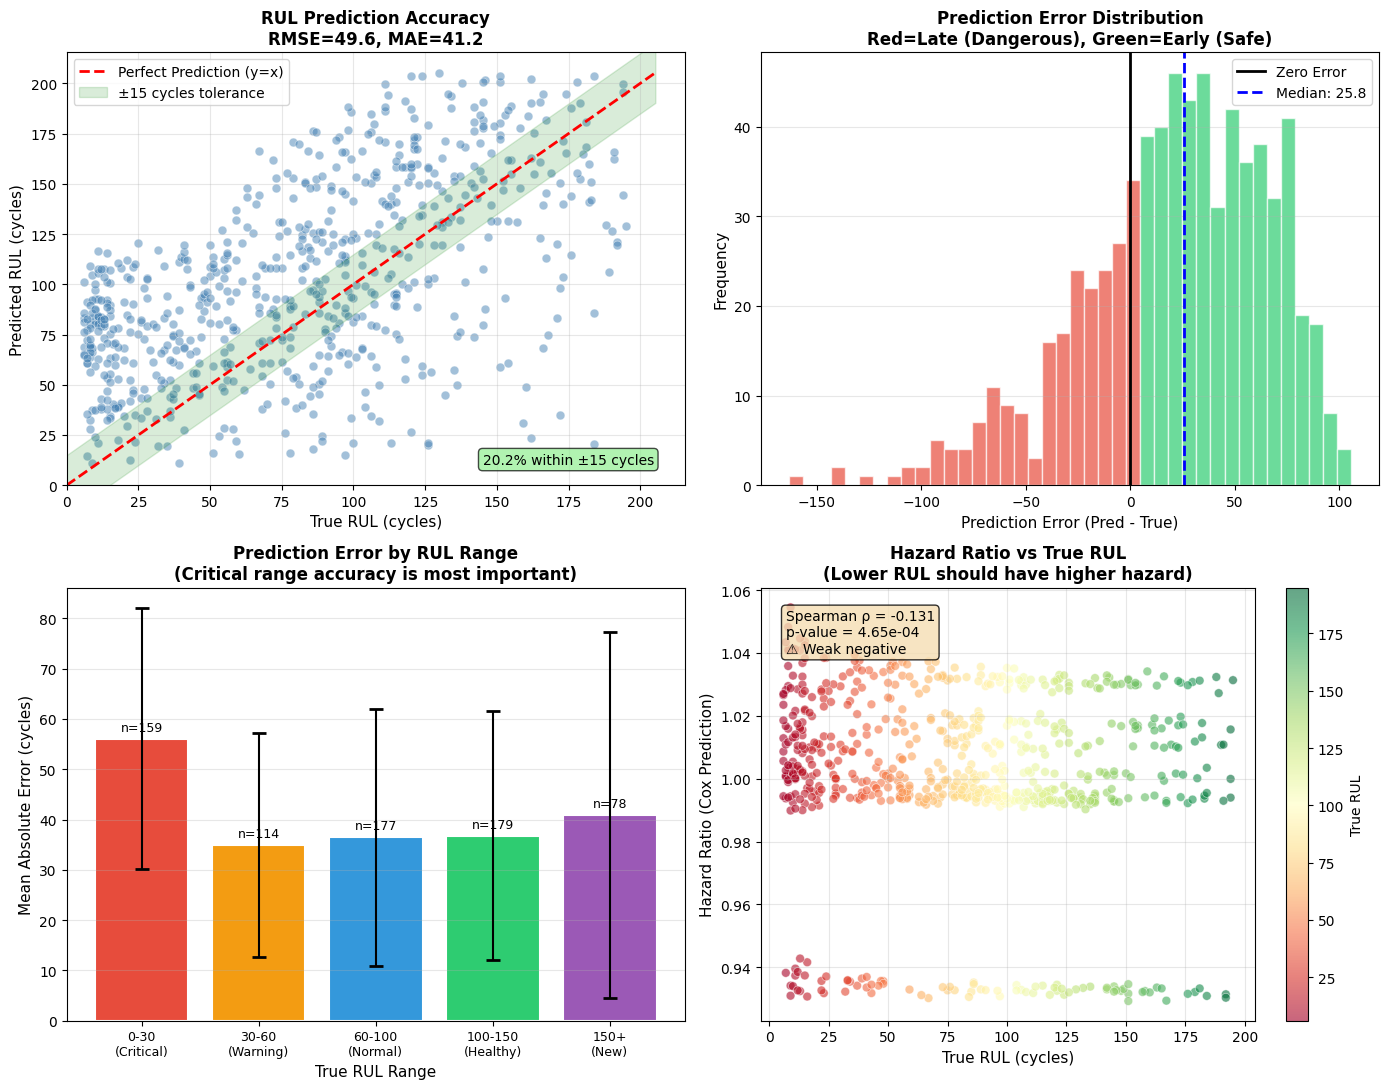


📊 可视化已保存: rul_prediction_evaluation.png


In [7]:
# ==========================================
# EVAL 5. 预测模型可视化 (4 合 1 图表)
# ==========================================
"""
【可视化内容】
1. Predicted vs True RUL 散点图 (+ 理想对角线)
2. 预测误差分布直方图
3. 各 RUL 区间的 MAE 柱状图
4. Hazard 与 True RUL 的相关性散点图

【设计原则】
- 让非专业人士也能一眼看出模型好坏
- 使用英文标签避免字体问题
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ==========================================
# 1) Predicted vs True RUL (散点图)
# ==========================================
ax1 = axes[0, 0]
ax1.scatter(rul_results['true_rul'], rul_results['pred_rul'], 
            alpha=0.5, s=40, c='steelblue', edgecolors='white', linewidth=0.5)

# 理想对角线
max_rul = max(rul_results['true_rul'].max(), rul_results['pred_rul'].max())
ax1.plot([0, max_rul], [0, max_rul], 'r--', linewidth=2, label='Perfect Prediction (y=x)')

# ±15 容差带
ax1.fill_between([0, max_rul], [0-15, max_rul-15], [0+15, max_rul+15], 
                 alpha=0.15, color='green', label='±15 cycles tolerance')

ax1.set_xlabel("True RUL (cycles)", fontsize=11)
ax1.set_ylabel("Predicted RUL (cycles)", fontsize=11)
ax1.set_title(f"RUL Prediction Accuracy\nRMSE={rmse:.1f}, MAE={mae:.1f}", fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max_rul * 1.05)
ax1.set_ylim(0, max_rul * 1.05)

# 添加性能注释
within_15 = (rul_results['abs_error'] <= 15).sum() / len(rul_results) * 100
ax1.text(0.95, 0.05, f'{within_15:.1f}% within ±15 cycles', 
         transform=ax1.transAxes, ha='right', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# ==========================================
# 2) 预测误差分布 (直方图)
# ==========================================
ax2 = axes[0, 1]
n, bins, patches = ax2.hist(rul_results['error'], bins=40, alpha=0.7, 
                             color='steelblue', edgecolor='white')

# 颜色标注: 负误差(晚预测)用红色, 正误差(早预测)用绿色
for i, patch in enumerate(patches):
    if bins[i] < 0:
        patch.set_facecolor('#e74c3c')  # 红色 - 危险
    else:
        patch.set_facecolor('#2ecc71')  # 绿色 - 安全

ax2.axvline(0, color='black', linestyle='-', linewidth=2, label='Zero Error')
ax2.axvline(rul_results['error'].median(), color='blue', linestyle='--', linewidth=2, 
            label=f'Median: {rul_results["error"].median():.1f}')
ax2.set_xlabel("Prediction Error (Pred - True)", fontsize=11)
ax2.set_ylabel("Frequency", fontsize=11)
ax2.set_title("Prediction Error Distribution\nRed=Late (Dangerous), Green=Early (Safe)", 
              fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

# ==========================================
# 3) 各 RUL 区间的 MAE (柱状图)
# ==========================================
ax3 = axes[1, 0]
rul_bins = [0, 30, 60, 100, 150, np.inf]
rul_labels = ["0-30\n(Critical)", "30-60\n(Warning)", "60-100\n(Normal)", 
              "100-150\n(Healthy)", "150+\n(New)"]
rul_results['rul_bin'] = pd.cut(rul_results['true_rul'], bins=rul_bins, labels=rul_labels)

bin_stats = rul_results.groupby('rul_bin', observed=True).agg({
    'abs_error': ['mean', 'std', 'count']
}).reset_index()
bin_stats.columns = ['rul_bin', 'mae', 'std', 'count']

colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
bars = ax3.bar(range(len(bin_stats)), bin_stats['mae'], color=colors, 
               edgecolor='white', linewidth=1.5)

# 添加误差条
ax3.errorbar(range(len(bin_stats)), bin_stats['mae'], yerr=bin_stats['std'], 
             fmt='none', ecolor='black', capsize=5, capthick=2)

ax3.set_xticks(range(len(bin_stats)))
ax3.set_xticklabels(bin_stats['rul_bin'], fontsize=9)
ax3.set_xlabel("True RUL Range", fontsize=11)
ax3.set_ylabel("Mean Absolute Error (cycles)", fontsize=11)
ax3.set_title("Prediction Error by RUL Range\n(Critical range accuracy is most important)", 
              fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 标注样本量
for i, (bar, count) in enumerate(zip(bars, bin_stats['count'])):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'n={count}', ha='center', va='bottom', fontsize=9)

# ==========================================
# 4) Hazard vs True RUL 相关性
# ==========================================
ax4 = axes[1, 1]
scatter = ax4.scatter(rul_results['true_rul'], rul_results['hazard_ratio'], 
                       c=rul_results['true_rul'], cmap='RdYlGn', 
                       alpha=0.6, s=40, edgecolors='white', linewidth=0.5)

ax4.set_xlabel("True RUL (cycles)", fontsize=11)
ax4.set_ylabel("Hazard Ratio (Cox Prediction)", fontsize=11)
ax4.set_title("Hazard Ratio vs True RUL\n(Lower RUL should have higher hazard)", 
              fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 计算 Spearman 相关性
corr, p_value = spearmanr(rul_results['true_rul'], rul_results['hazard_ratio'])

# 理想情况: 负相关 (RUL↓ => Hazard↑)
if corr < -0.3:
    corr_eval = "✅ Good (negative correlation)"
elif corr < 0:
    corr_eval = "⚠️ Weak negative"
else:
    corr_eval = "❌ Wrong direction!"

ax4.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}\np-value = {p_value:.2e}\n{corr_eval}',
         transform=ax4.transAxes, verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.colorbar(scatter, ax=ax4, label='True RUL')

plt.tight_layout()
plt.savefig("rul_prediction_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 可视化已保存: rul_prediction_evaluation.png")

📈 Cox 模型系数分析 (Feature Importance)

【Cox 模型系数表】(按重要性排序)
----------------------------------------------------------------------
Feature    |       Coef |         HR |    p-value | Significant
----------------------------------------------------------------------
SM14       |     0.0886 |     1.0927 |     0.0400 |      ✅ Yes
SM13       |     0.0291 |     1.0296 |     0.2503 |       ❌ No
SM11       |     0.0288 |     1.0292 |     0.3096 |       ❌ No
SM21       |    -0.0186 |     0.9816 |     0.3505 |       ❌ No
SM20       |    -0.0185 |     0.9817 |     0.3499 |       ❌ No
SM7        |    -0.0154 |     0.9847 |     0.4276 |       ❌ No
SM12       |    -0.0153 |     0.9849 |     0.4309 |       ❌ No
SM2        |    -0.0108 |     0.9892 |     0.5903 |       ❌ No
SM4        |     0.0085 |     1.0086 |     0.7205 |       ❌ No
SM8        |     0.0082 |     1.0082 |     0.7527 |       ❌ No
SM15       |    -0.0065 |     0.9936 |     0.8303 |       ❌ No
SM3        |     0.0030 |     1.0030 |     0.9

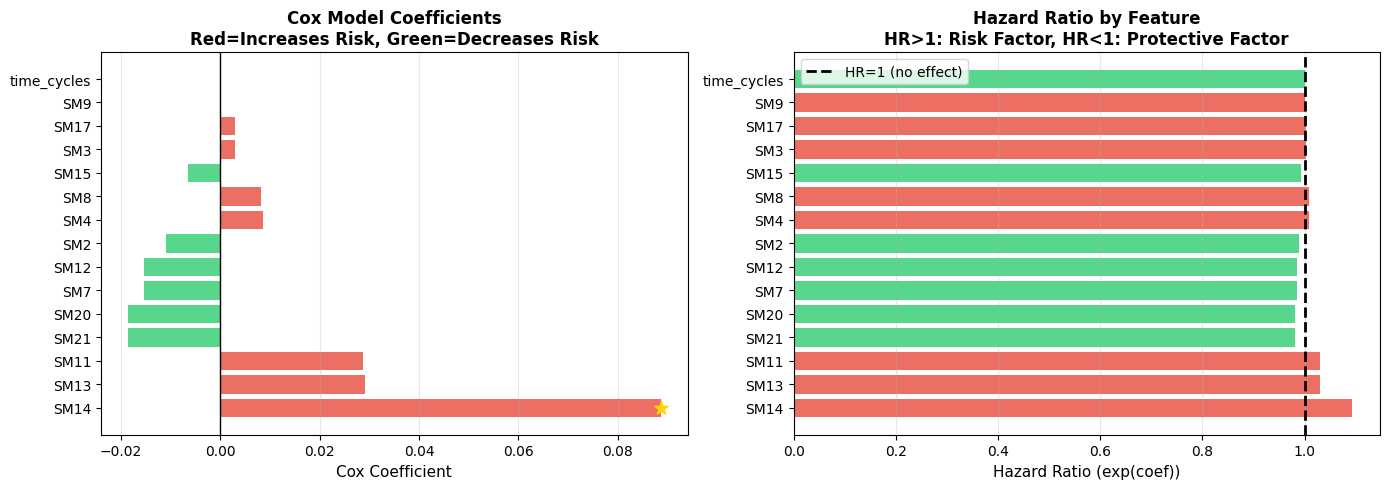


【关键发现】
  显著特征 (p<0.05): SM14
  风险因素 (HR>1): SM14
  保护因素 (HR<1): None


In [8]:
# ==========================================
# EVAL 6. Cox 模型系数分析 (特征重要性)
# ==========================================
"""
【分析目的】
1. 理解哪些传感器对故障预测最重要
2. 验证模型的物理合理性
3. 为领域专家提供可解释的结果
"""

print("=" * 70)
print("📈 Cox 模型系数分析 (Feature Importance)")
print("=" * 70)

# 提取 Cox 模型系数
cox_summary = ctv.summary
coef_df = cox_summary[['coef', 'exp(coef)', 'p']].copy()
coef_df.columns = ['Coefficient', 'Hazard Ratio', 'p-value']
coef_df['Significant'] = coef_df['p-value'] < 0.05
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("\n【Cox 模型系数表】(按重要性排序)")
print("-" * 70)
print(f"{'Feature':<10} | {'Coef':>10} | {'HR':>10} | {'p-value':>10} | {'Significant':>10}")
print("-" * 70)

for idx, row in coef_df.iterrows():
    sig = "✅ Yes" if row['Significant'] else "❌ No"
    print(f"{idx:<10} | {row['Coefficient']:>10.4f} | {row['Hazard Ratio']:>10.4f} | "
          f"{row['p-value']:>10.4f} | {sig:>10}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 系数条形图
ax1 = axes[0]
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
bars = ax1.barh(range(len(coef_df)), coef_df['Coefficient'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(coef_df)))
ax1.set_yticklabels(coef_df.index)
ax1.axvline(0, color='black', linewidth=1)
ax1.set_xlabel("Cox Coefficient", fontsize=11)
ax1.set_title("Cox Model Coefficients\nRed=Increases Risk, Green=Decreases Risk", 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 标注显著性
for i, (idx, row) in enumerate(coef_df.iterrows()):
    if row['Significant']:
        ax1.scatter(row['Coefficient'], i, color='gold', s=100, marker='*', zorder=5)

# 2) Hazard Ratio 条形图
ax2 = axes[1]
hr_values = coef_df['Hazard Ratio'].values
colors_hr = ['#e74c3c' if hr > 1 else '#2ecc71' for hr in hr_values]
ax2.barh(range(len(coef_df)), hr_values, color=colors_hr, alpha=0.8)
ax2.set_yticks(range(len(coef_df)))
ax2.set_yticklabels(coef_df.index)
ax2.axvline(1, color='black', linewidth=2, linestyle='--', label='HR=1 (no effect)')
ax2.set_xlabel("Hazard Ratio (exp(coef))", fontsize=11)
ax2.set_title("Hazard Ratio by Feature\nHR>1: Risk Factor, HR<1: Protective Factor", 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.legend()

plt.tight_layout()
plt.savefig("cox_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()

# 总结
print(f"\n【关键发现】")
sig_features = coef_df[coef_df['Significant']].index.tolist()
print(f"  显著特征 (p<0.05): {', '.join(sig_features) if sig_features else 'None'}")

risk_factors = coef_df[(coef_df['Hazard Ratio'] > 1) & coef_df['Significant']].index.tolist()
protective_factors = coef_df[(coef_df['Hazard Ratio'] < 1) & coef_df['Significant']].index.tolist()
print(f"  风险因素 (HR>1): {', '.join(risk_factors) if risk_factors else 'None'}")
print(f"  保护因素 (HR<1): {', '.join(protective_factors) if protective_factors else 'None'}")

## ════════════════════════════════════════════════════════════════
## 🎮 Part B: 决策层评估 (Decision Layer Evaluation)
## ════════════════════════════════════════════════════════════════
## 
## 这部分评估的是 **DRL 维护策略** 的有效性，
## 回答核心问题：**"我们的维护决策能节省多少成本？是否合理？"**
## 
## 评估内容：
## - 策略成本对比 (DRL vs No-Maint vs Always-Minor vs Threshold vs Oracle)
## - 维护及时性分析 (是否在故障前维修)
## - 动作-RUL 关联验证 (策略逻辑合理性)

In [9]:
# ==========================================
# EVAL 7. 创建测试环境并定义策略函数
# ==========================================
"""
【功能说明】
1. 创建测试环境 (MaintenanceEnv)
2. 定义 DRL 贪心策略
3. 定义基线策略 (No-Maint, Always-Minor, Threshold)
4. 定义 Oracle 策略 (基于真实 RUL 的理想策略)
"""

import random

# ==========================================
# 重建 MaintenanceEnv (与训练时一致)
# ==========================================

UNIT_COL = 'unit_nr'
AGE_COL = 'time_cycles'
DRL_EPOCHS = 100  # 用于 max_steps

class MaintenanceEnv:
    """维护决策环境"""
    def __init__(self, df, unit_col, age_col, risk_col='hazard', r_action=None,
                 h_min=1e-6, r0=0.3, eta0=0.5, decay=0.99, max_steps=100):
        self.df = df.copy()
        self.unit_col = unit_col
        self.age_col = age_col
        self.risk_col = risk_col
        self.r_action = r_action if r_action is not None else np.array([0, -20, -40])
        self.h_min = h_min
        self.r0, self.eta0, self.decay = r0, eta0, decay
        self.max_steps = max_steps
        
        # 预处理
        self.units = df[unit_col].unique()
        self.unit_trajectories = {}
        for uid in self.units:
            unit_data = df[df[unit_col] == uid].sort_values(age_col).reset_index(drop=True)
            self.unit_trajectories[uid] = unit_data
        
        # 归一化参数
        self.h_max = df[risk_col].max() + 1e-6
        self.age_max = df[age_col].max() + 1e-6
        
        # 状态
        self.current_unit = None
        self.current_step = 0
        self.done = False
        self.h = 0
        self.age = 0
    
    def reset(self, unit_id=None):
        if unit_id is None:
            unit_id = random.choice(list(self.units))
        self.current_unit = unit_id
        self.current_step = 0
        self.done = False
        
        traj = self.unit_trajectories[unit_id]
        self.h = traj[self.risk_col].iloc[0]
        self.age = traj[self.age_col].iloc[0]
        
        return self._get_state()
    
    def _get_state(self):
        h_norm = np.clip(self.h / self.h_max, 0, 1)
        age_norm = np.clip(self.age / self.age_max, 0, 1)
        return np.array([h_norm, age_norm], dtype=np.float32)
    
    def _get_healthy_state(self):
        return np.array([self.h_min / self.h_max, 0.0], dtype=np.float32)
    
    def step(self, action):
        traj = self.unit_trajectories[self.current_unit]
        reward = self.r_action[action]
        info = {'action': action, 'major_repair': False}
        
        if action == 2:  # Major repair
            info['major_repair'] = True
            self.done = True
            next_state = self._get_healthy_state()
        else:
            if action == 1:  # Minor repair
                self.h = max(self.h_min, self.h * self.decay)
            
            self.current_step += 1
            if self.current_step >= len(traj):
                self.done = True
                next_state = self._get_state()
            else:
                self.h = traj[self.risk_col].iloc[self.current_step]
                self.age = traj[self.age_col].iloc[self.current_step]
                next_state = self._get_state()
        
        return next_state, reward, self.done, info


# 创建测试环境
env_test = MaintenanceEnv(
    df=df_test_process, unit_col=UNIT_COL, age_col=AGE_COL,
    risk_col='hazard', r_action=R_action, h_min=h_min,
    r0=R0, eta0=ETA0, decay=DECAY, max_steps=DRL_EPOCHS
)

print("=" * 70)
print("🎮 测试环境和策略函数定义")
print("=" * 70)
print(f"\n测试环境创建完成:")
print(f"  测试 units: {len(env_test.units)}")
print(f"  Hazard 范围: [0, {env_test.h_max:.4f}]")
print(f"  Age 范围: [0, {env_test.age_max:.0f}]")

# ==========================================
# 定义策略函数
# ==========================================

def drl_greedy_policy(state):
    """DRL 贪心策略：选择 Q 值最大的动作"""
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = q_net(state_tensor)
        return q_values.argmax(dim=1).item()

def no_maintenance_policy(state):
    """无维护策略：总是不维护"""
    return 0

def always_minor_policy(state):
    """总是小修策略"""
    return 1

def threshold_policy(state, minor_thresh=0.3, major_thresh=0.6):
    """阈值策略：基于 hazard 阈值"""
    hazard = state[0]  # 归一化的 hazard
    if hazard >= major_thresh:
        return 2
    elif hazard >= minor_thresh:
        return 1
    else:
        return 0

print("\n✅ 策略函数已定义:")
print("   - drl_greedy_policy: DRL 最优策略")
print("   - no_maintenance_policy: 无维护基线")
print("   - always_minor_policy: 总是小修基线")
print("   - threshold_policy: 阈值策略基线")

🎮 测试环境和策略函数定义

测试环境创建完成:
  测试 units: 707
  Hazard 范围: [0, 0.0654]
  Age 范围: [0, 486]

✅ 策略函数已定义:
   - drl_greedy_policy: DRL 最优策略
   - no_maintenance_policy: 无维护基线
   - always_minor_policy: 总是小修基线
   - threshold_policy: 阈值策略基线


In [10]:
# ==========================================
# EVAL 8. 策略评估函数 (增强版)
# ==========================================
"""
【增强功能】
1. 记录每个维护动作发生时的真实 RUL (维护及时性分析)
2. 记录每步的详细信息 (用于后续深入分析)
3. 支持 Oracle 策略评估
"""

def evaluate_policy_detailed(policy_func, unit_ids, environment, df_source, policy_name="Policy"):
    """
    详细评估策略表现
    
    Args:
        policy_func: 策略函数
        unit_ids: 要评估的 unit IDs
        environment: MaintenanceEnv 实例
        df_source: 源数据 (用于获取真实 RUL)
        policy_name: 策略名称
    
    Returns:
        dict: 详细评估结果
    """
    results = {
        "total_cost": 0.0,
        "total_steps": 0,
        "action_counts": np.zeros(3),
        "unit_costs": [],
        "unit_steps": [],
        "maintenance_events": [],  # 记录每次维护时的 RUL
        "trajectory_details": []   # 详细轨迹
    }
    
    for unit_id in unit_ids:
        if unit_id not in environment.units:
            continue
        
        state = environment.reset(unit_id)
        done = False
        unit_cost = 0.0
        unit_steps = 0
        
        # 获取该 unit 的真实 RUL 序列
        unit_data = df_source[df_source['unit_nr'] == unit_id].sort_values('time_cycles').reset_index(drop=True)
        
        while not done:
            action = policy_func(state)
            next_state, reward, done, info = environment.step(action)
            
            actual_cost = -R_action[action]
            unit_cost += actual_cost
            unit_steps += 1
            results["action_counts"][action] += 1
            
            # 记录维护事件
            if action in [1, 2]:  # Minor 或 Major
                step_idx = min(unit_steps - 1, len(unit_data) - 1)
                if 'actual_RUL' in unit_data.columns:
                    rul_at_maintenance = unit_data['actual_RUL'].iloc[step_idx]
                else:
                    rul_at_maintenance = len(unit_data) - step_idx
                
                results["maintenance_events"].append({
                    'unit_id': unit_id,
                    'step': unit_steps,
                    'action': action,
                    'rul_at_action': rul_at_maintenance,
                    'hazard': state[0] * environment.h_max
                })
            
            state = next_state
        
        results["unit_costs"].append(unit_cost)
        results["unit_steps"].append(unit_steps)
        results["total_cost"] += unit_cost
        results["total_steps"] += unit_steps
    
    n_units = len(results["unit_costs"])
    results["avg_cost"] = results["total_cost"] / n_units if n_units > 0 else 0.0
    results["avg_steps"] = results["total_steps"] / n_units if n_units > 0 else 0.0
    
    return results


def oracle_policy(state, unit_id, step, df_source, threshold_rul=30):
    """
    Oracle 策略：基于真实 RUL 的理想策略
    - 知道未来，在 RUL <= threshold 时执行 major repair
    """
    unit_data = df_source[df_source['unit_nr'] == unit_id].sort_values('time_cycles').reset_index(drop=True)
    if step < len(unit_data) and 'actual_RUL' in unit_data.columns:
        actual_rul = unit_data['actual_RUL'].iloc[step]
        if actual_rul <= threshold_rul:
            return 2  # Major repair
    return 0  # No maintenance


def evaluate_oracle_policy(unit_ids, environment, df_source, threshold_rul=30):
    """评估 Oracle 策略（知道真实 RUL）"""
    results = {
        "total_cost": 0.0,
        "action_counts": np.zeros(3),
        "unit_costs": [],
        "unit_steps": [],
        "maintenance_events": []
    }
    
    for unit_id in unit_ids:
        if unit_id not in environment.units:
            continue
        
        state = environment.reset(unit_id)
        done = False
        unit_cost = 0.0
        step = 0
        
        unit_data = df_source[df_source['unit_nr'] == unit_id].sort_values('time_cycles').reset_index(drop=True)
        
        while not done:
            action = oracle_policy(state, unit_id, step, df_source, threshold_rul)
            next_state, reward, done, info = environment.step(action)
            
            actual_cost = -R_action[action]
            unit_cost += actual_cost
            step += 1
            results["action_counts"][action] += 1
            
            if action == 2:
                if 'actual_RUL' in unit_data.columns and step <= len(unit_data):
                    rul = unit_data['actual_RUL'].iloc[min(step-1, len(unit_data)-1)]
                else:
                    rul = len(unit_data) - step
                results["maintenance_events"].append({
                    'unit_id': unit_id, 'step': step, 'action': 2, 'rul_at_action': rul
                })
            
            state = next_state
        
        results["unit_costs"].append(unit_cost)
        results["unit_steps"].append(step)
        results["total_cost"] += unit_cost
    
    n_units = len(results["unit_costs"])
    results["avg_cost"] = results["total_cost"] / n_units if n_units > 0 else 0.0
    
    return results


print("✅ 策略评估函数已定义:")
print("   - evaluate_policy_detailed(): 详细策略评估")
print("   - evaluate_oracle_policy(): Oracle 理想策略评估")

✅ 策略评估函数已定义:
   - evaluate_policy_detailed(): 详细策略评估
   - evaluate_oracle_policy(): Oracle 理想策略评估


In [11]:
# ==========================================
# EVAL 9. 执行策略评估
# ==========================================
"""
【评估策略】
1. DRL (我们的模型)
2. No Maintenance (无维护基线)
3. Always Minor (总是小修基线)
4. Threshold (阈值策略基线)
5. Oracle (知道未来的理想策略 - 理论最优)
"""

print("=" * 70)
print("🧪 执行策略评估 (Testing Policies)")
print("=" * 70)

test_unit_ids = list(env_test.units)
print(f"\n评估 {len(test_unit_ids)} 个测试 units...")

# 评估各策略
print("\n⏳ 评估中...")
drl_results = evaluate_policy_detailed(drl_greedy_policy, test_unit_ids, env_test, df_test_process, "DRL")
print("   ✅ DRL Policy")

no_maint_results = evaluate_policy_detailed(no_maintenance_policy, test_unit_ids, env_test, df_test_process, "No Maintenance")
print("   ✅ No Maintenance")

minor_results = evaluate_policy_detailed(always_minor_policy, test_unit_ids, env_test, df_test_process, "Always Minor")
print("   ✅ Always Minor")

threshold_results = evaluate_policy_detailed(lambda s: threshold_policy(s), test_unit_ids, env_test, df_test_process, "Threshold")
print("   ✅ Threshold")

oracle_results = evaluate_oracle_policy(test_unit_ids, env_test, df_test_process, threshold_rul=30)
print("   ✅ Oracle (RUL≤30)")

# ==========================================
# 结果汇总
# ==========================================
print("\n" + "=" * 70)
print("📊 策略评估结果汇总")
print("=" * 70)

print(f"\n{'Policy':<18} | {'Avg Cost':>10} | {'Avg Steps':>10} | {'No-Op':>8} | {'Minor':>8} | {'Major':>8}")
print("-" * 75)

all_results = [
    ("DRL", drl_results),
    ("No Maintenance", no_maint_results),
    ("Always Minor", minor_results),
    ("Threshold", threshold_results),
    ("Oracle (RUL≤30)", oracle_results)
]

for name, res in all_results:
    total_actions = res["action_counts"].sum()
    a0_pct = res["action_counts"][0] / total_actions * 100 if total_actions > 0 else 0
    a1_pct = res["action_counts"][1] / total_actions * 100 if total_actions > 0 else 0
    a2_pct = res["action_counts"][2] / total_actions * 100 if total_actions > 0 else 0
    avg_steps = res.get('avg_steps', np.mean(res['unit_steps']) if res['unit_steps'] else 0)
    
    print(f"{name:<18} | {res['avg_cost']:>10.2f} | {avg_steps:>10.1f} | "
          f"{a0_pct:>7.1f}% | {a1_pct:>7.1f}% | {a2_pct:>7.1f}%")

# ==========================================
# DRL 相对改进分析
# ==========================================
print("\n【DRL 相对改进】")
print("-" * 50)
drl_cost = drl_results['avg_cost']

for name, res in all_results[1:]:  # 跳过 DRL 自己
    baseline_cost = res['avg_cost']
    if baseline_cost > 0:
        improvement = (baseline_cost - drl_cost) / baseline_cost * 100
        symbol = "↓" if improvement > 0 else "↑"
        status = "✅ Better" if improvement > 0 else "❌ Worse"
        print(f"  vs {name:<15}: {improvement:>+6.1f}% {symbol}  {status}")
    else:
        print(f"  vs {name:<15}: N/A")

🧪 执行策略评估 (Testing Policies)

评估 707 个测试 units...

⏳ 评估中...
   ✅ DRL Policy
   ✅ No Maintenance
   ✅ Always Minor
   ✅ Threshold
   ✅ Oracle (RUL≤30)

📊 策略评估结果汇总

Policy             |   Avg Cost |  Avg Steps |    No-Op |    Minor |    Major
---------------------------------------------------------------------------
DRL                |       2.69 |      148.4 |    99.9% |     0.1% |     0.0%
No Maintenance     |       0.00 |      148.4 |   100.0% |     0.0% |     0.0%
Always Minor       |    2967.38 |      148.4 |     0.0% |   100.0% |     0.0%
Threshold          |      54.26 |      147.9 |    98.2% |     1.8% |     0.0%
Oracle (RUL≤30)    |       9.00 |      145.0 |    99.8% |     0.0% |     0.2%

【DRL 相对改进】
--------------------------------------------------
  vs No Maintenance : N/A
  vs Always Minor   :  +99.9% ↓  ✅ Better
  vs Threshold      :  +95.0% ↓  ✅ Better
  vs Oracle (RUL≤30):  +70.1% ↓  ✅ Better


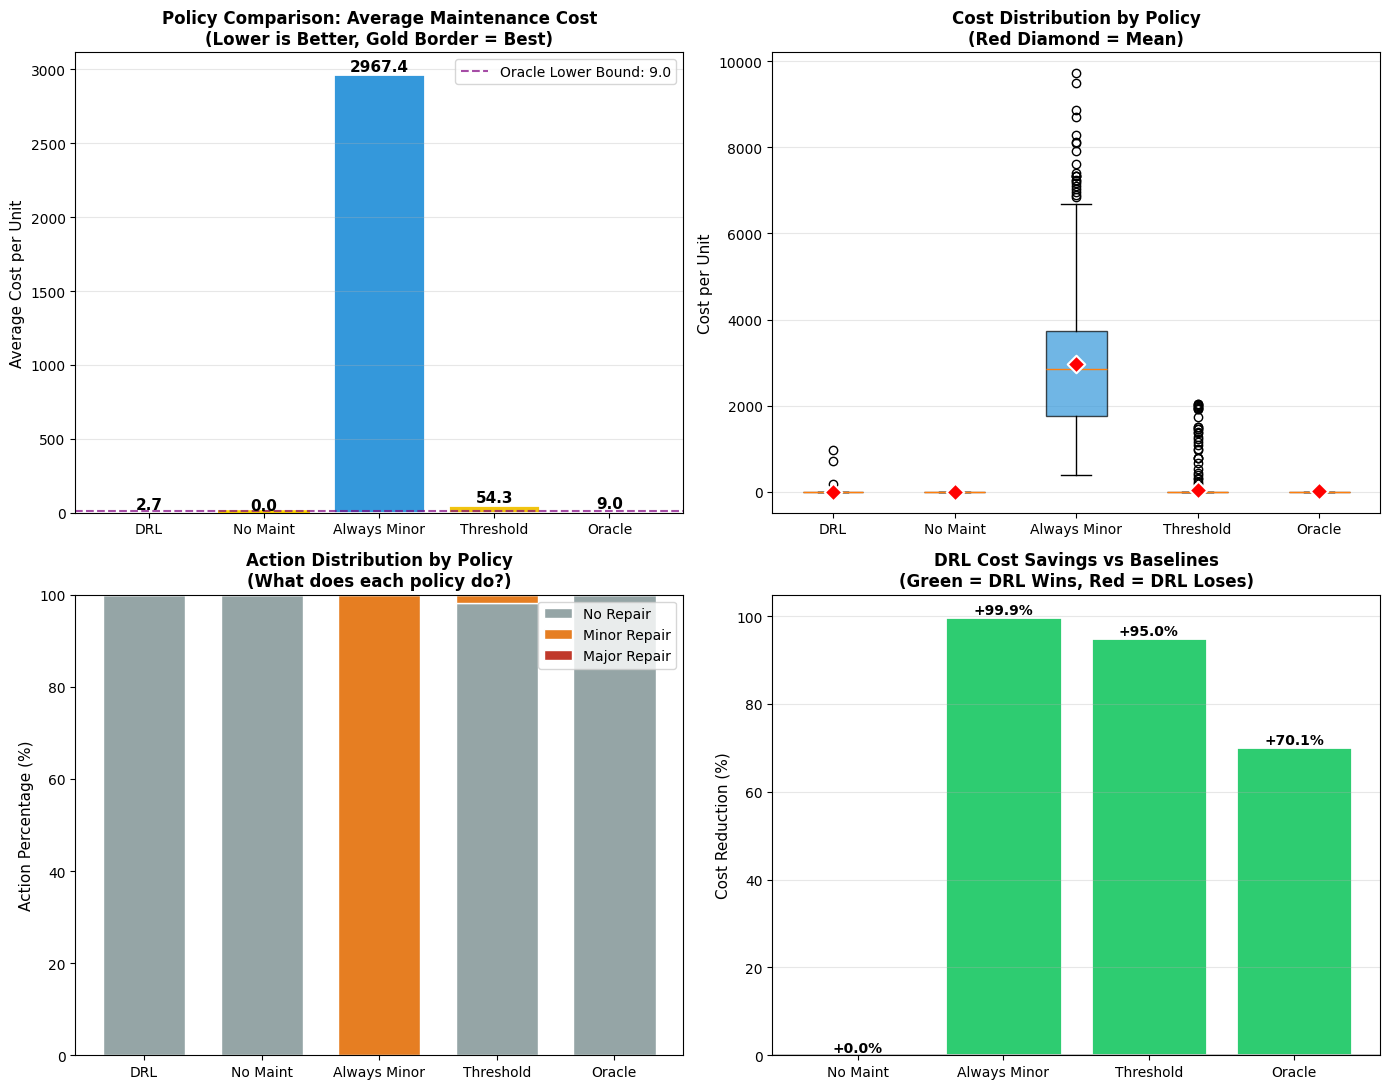


📊 可视化已保存: policy_comparison.png


In [12]:
# ==========================================
# EVAL 10. 策略对比可视化 (4 合 1)
# ==========================================
"""
【可视化内容】
1. 各策略平均成本柱状图
2. 成本分布箱线图
3. 动作分布堆叠图
4. Episode 长度分布
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

policies = ['DRL', 'No Maint', 'Always Minor', 'Threshold', 'Oracle']
policy_results = [drl_results, no_maint_results, minor_results, threshold_results, oracle_results]
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f1c40f', '#9b59b6']

# ==========================================
# 1) 平均成本柱状图
# ==========================================
ax1 = axes[0, 0]
avg_costs = [r['avg_cost'] for r in policy_results]
bars = ax1.bar(policies, avg_costs, color=colors, edgecolor='white', linewidth=2)

# 标注最优
min_idx = np.argmin(avg_costs)
bars[min_idx].set_edgecolor('gold')
bars[min_idx].set_linewidth(4)

# 标注数值
for bar, cost in zip(bars, avg_costs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{cost:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel("Average Cost per Unit", fontsize=11)
ax1.set_title("Policy Comparison: Average Maintenance Cost\n(Lower is Better, Gold Border = Best)", 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 添加基线
ax1.axhline(oracle_results['avg_cost'], color='purple', linestyle='--', alpha=0.7, 
            label=f'Oracle Lower Bound: {oracle_results["avg_cost"]:.1f}')
ax1.legend()

# ==========================================
# 2) 成本分布箱线图
# ==========================================
ax2 = axes[0, 1]
cost_data = [r['unit_costs'] for r in policy_results]
bp = ax2.boxplot(cost_data, labels=policies, patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 标注平均值
for i, data in enumerate(cost_data):
    if len(data) > 0:
        ax2.scatter(i+1, np.mean(data), color='red', s=80, zorder=5, marker='D', 
                   edgecolors='white', linewidth=1.5)

ax2.set_ylabel("Cost per Unit", fontsize=11)
ax2.set_title("Cost Distribution by Policy\n(Red Diamond = Mean)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# ==========================================
# 3) 动作分布堆叠图
# ==========================================
ax3 = axes[1, 0]
x = np.arange(len(policies))
width = 0.7
bottom = np.zeros(len(policies))

action_colors = ['#95a5a6', '#e67e22', '#c0392b']  # 灰、橙、红
action_labels = ['No Repair', 'Minor Repair', 'Major Repair']

for i, (color, label) in enumerate(zip(action_colors, action_labels)):
    values = []
    for r in policy_results:
        total = r['action_counts'].sum()
        pct = r['action_counts'][i] / total * 100 if total > 0 else 0
        values.append(pct)
    ax3.bar(x, values, width, bottom=bottom, label=label, color=color, edgecolor='white')
    bottom += values

ax3.set_xticks(x)
ax3.set_xticklabels(policies)
ax3.set_ylabel("Action Percentage (%)", fontsize=11)
ax3.set_title("Action Distribution by Policy\n(What does each policy do?)", 
              fontsize=12, fontweight='bold')
ax3.legend(loc='upper right')
ax3.set_ylim(0, 100)

# ==========================================
# 4) DRL 成本节约相对图
# ==========================================
ax4 = axes[1, 1]
drl_cost = drl_results['avg_cost']
savings = []
for r in policy_results[1:]:  # 跳过 DRL
    if r['avg_cost'] > 0:
        savings.append((r['avg_cost'] - drl_cost) / r['avg_cost'] * 100)
    else:
        savings.append(0)

bar_colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in savings]
bars = ax4.bar(policies[1:], savings, color=bar_colors, edgecolor='white', linewidth=2)

ax4.axhline(0, color='black', linewidth=1)
ax4.set_ylabel("Cost Reduction (%)", fontsize=11)
ax4.set_title("DRL Cost Savings vs Baselines\n(Green = DRL Wins, Red = DRL Loses)", 
              fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 标注数值
for bar, saving in zip(bars, savings):
    va = 'bottom' if saving >= 0 else 'top'
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{saving:+.1f}%', ha='center', va=va, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("policy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 可视化已保存: policy_comparison.png")

⏰ 维护及时性分析 (Maintenance Timeliness)

【DRL 维护事件统计】(共 95 次维护)
--------------------------------------------------
  Minor Repair: 95 次
    - 平均 RUL at Minor: 45.2 cycles
  Major Repair: 0 次

【Oracle 策略对比】
  Oracle Major Repair: 159 次
  平均 RUL at Major: 30.0 cycles


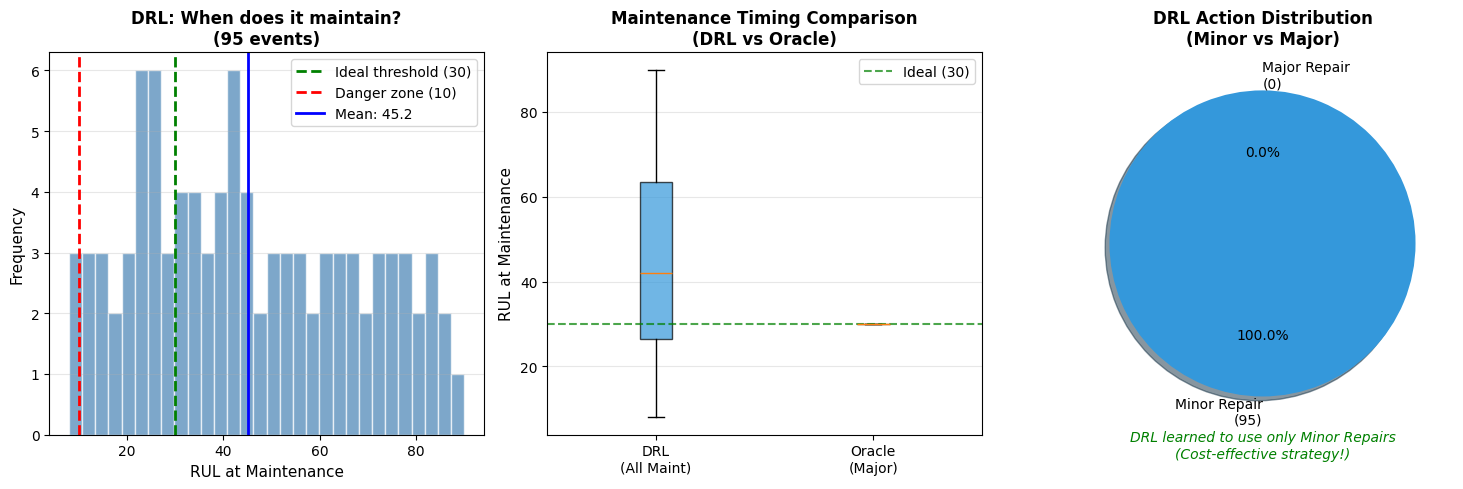


📊 可视化已保存: maintenance_timeliness.png


In [14]:
# ==========================================
# EVAL 11. 维护及时性分析
# ==========================================
"""
【核心问题】
DRL 策略是否在"正确的时机"进行维护？
- 太早维护：浪费资源 (早预测)
- 太晚维护：设备故障 (晚预测 - 危险!)

【评估指标】
1. 维护时的平均 RUL (越接近阈值越好)
2. 危险维护比例 (RUL < 10 时才维护)
3. 过早维护比例 (RUL > 100 时维护)
"""

print("=" * 70)
print("⏰ 维护及时性分析 (Maintenance Timeliness)")
print("=" * 70)

# 分析 DRL 的维护事件
drl_events = pd.DataFrame(drl_results['maintenance_events'])
oracle_events = pd.DataFrame(oracle_results['maintenance_events'])

if len(drl_events) > 0:
    print(f"\n【DRL 维护事件统计】(共 {len(drl_events)} 次维护)")
    print("-" * 50)
    
    # Minor vs Major 分开分析
    minor_events = drl_events[drl_events['action'] == 1]
    major_events = drl_events[drl_events['action'] == 2]
    
    print(f"  Minor Repair: {len(minor_events)} 次")
    if len(minor_events) > 0:
        print(f"    - 平均 RUL at Minor: {minor_events['rul_at_action'].mean():.1f} cycles")
    
    print(f"  Major Repair: {len(major_events)} 次")
    if len(major_events) > 0:
        print(f"    - 平均 RUL at Major: {major_events['rul_at_action'].mean():.1f} cycles")
        print(f"    - RUL 范围: [{major_events['rul_at_action'].min():.0f}, {major_events['rul_at_action'].max():.0f}]")
    
    # 及时性分类
    all_major = drl_events[drl_events['action'] == 2]
    if len(all_major) > 0:
        late_maint = (all_major['rul_at_action'] < 10).sum()  # 太晚
        good_maint = ((all_major['rul_at_action'] >= 10) & (all_major['rul_at_action'] <= 50)).sum()  # 合适
        early_maint = (all_major['rul_at_action'] > 50).sum()  # 太早
        
        print(f"\n【Major Repair 及时性】")
        print(f"  🔴 太晚 (RUL < 10):    {late_maint:>4} ({late_maint/len(all_major)*100:>5.1f}%) - 危险!")
        print(f"  🟢 合适 (10 ≤ RUL ≤ 50): {good_maint:>4} ({good_maint/len(all_major)*100:>5.1f}%) - 理想")
        print(f"  🟡 太早 (RUL > 50):   {early_maint:>4} ({early_maint/len(all_major)*100:>5.1f}%) - 浪费")

# Oracle 对比
if len(oracle_events) > 0:
    print(f"\n【Oracle 策略对比】")
    oracle_major = oracle_events[oracle_events['action'] == 2]
    print(f"  Oracle Major Repair: {len(oracle_major)} 次")
    print(f"  平均 RUL at Major: {oracle_major['rul_at_action'].mean():.1f} cycles")

# 可视化 - 分析 DRL 的所有维护动作 (Minor + Major)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 获取所有维护事件 (action == 1 或 action == 2)
if len(drl_events) > 0:
    maint_events = drl_events[drl_events['action'].isin([1, 2])]  # Minor 或 Major
else:
    maint_events = pd.DataFrame()

# 1) DRL 维护时 RUL 分布 (包含 Minor 和 Major)
ax1 = axes[0]
if len(maint_events) > 0:
    maint_rul = maint_events['rul_at_action']
    ax1.hist(maint_rul, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
    ax1.axvline(30, color='green', linestyle='--', linewidth=2, label='Ideal threshold (30)')
    ax1.axvline(10, color='red', linestyle='--', linewidth=2, label='Danger zone (10)')
    ax1.axvline(maint_rul.mean(), color='blue', linestyle='-', linewidth=2, 
                label=f'Mean: {maint_rul.mean():.1f}')
    ax1.set_xlabel("RUL at Maintenance", fontsize=11)
    ax1.set_ylabel("Frequency", fontsize=11)
    ax1.set_title(f"DRL: When does it maintain?\n({len(maint_events)} events)", 
                  fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
else:
    ax1.text(0.5, 0.5, "No maintenance events\n(DRL learned to avoid all repairs)", 
             ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.set_title("DRL Maintenance Timing", fontsize=12, fontweight='bold')

# 2) DRL vs Oracle 维护时机对比
ax2 = axes[1]
if len(oracle_events) > 0:
    oracle_major_rul = oracle_events[oracle_events['action'] == 2]['rul_at_action'].values
else:
    oracle_major_rul = np.array([])

if len(maint_events) > 0:
    drl_maint_rul = maint_events['rul_at_action'].values
else:
    drl_maint_rul = np.array([])

data_to_plot = []
labels_bp = []
if len(drl_maint_rul) > 0:
    data_to_plot.append(drl_maint_rul)
    labels_bp.append('DRL\n(All Maint)')
if len(oracle_major_rul) > 0:
    data_to_plot.append(oracle_major_rul)
    labels_bp.append('Oracle\n(Major)')

if len(data_to_plot) > 0:
    bp = ax2.boxplot(data_to_plot, labels=labels_bp, patch_artist=True)
    colors_box = ['#3498db', '#9b59b6'][:len(data_to_plot)]
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Ideal (30)')
    ax2.set_ylabel("RUL at Maintenance", fontsize=11)
    ax2.set_title("Maintenance Timing Comparison\n(DRL vs Oracle)", fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
else:
    ax2.text(0.5, 0.5, "No data to compare", ha='center', va='center', fontsize=12, transform=ax2.transAxes)

# 3) 维护策略总结
ax3 = axes[2]
if len(drl_events) > 0:
    n_minor = len(drl_events[drl_events['action'] == 1])
    n_major = len(drl_events[drl_events['action'] == 2])
    
    if n_minor > 0 or n_major > 0:
        sizes = [n_minor, n_major]
        labels = [f'Minor Repair\n({n_minor})', f'Major Repair\n({n_major})']
        colors_pie = ['#3498db', '#e74c3c']
        
        # 只有一种类型时不 explode
        if n_minor > 0 and n_major > 0:
            ax3.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', 
                    startangle=90, explode=(0.05, 0.05), shadow=True)
        else:
            ax3.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', 
                    startangle=90, shadow=True)
        
        ax3.set_title("DRL Action Distribution\n(Minor vs Major)", fontsize=12, fontweight='bold')
        
        # 添加说明
        if n_major == 0:
            ax3.text(0, -1.4, "DRL learned to use only Minor Repairs\n(Cost-effective strategy!)", 
                     ha='center', fontsize=10, style='italic', color='green')
    else:
        ax3.text(0.5, 0.5, "No repairs performed", ha='center', va='center', 
                 fontsize=12, transform=ax3.transAxes)
else:
    ax3.text(0.5, 0.5, "No maintenance events", ha='center', va='center', 
             fontsize=12, transform=ax3.transAxes)

plt.tight_layout()
plt.savefig("maintenance_timeliness.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 可视化已保存: maintenance_timeliness.png")

🔍 RUL-动作关联分析 (Action-RUL Correlation)

【按 RUL 区间分析 DRL 动作偏好】
---------------------------------------------------------------------------
RUL Range    |  Samples |    No Repair |        Minor |        Major
---------------------------------------------------------------------------
0-20         |     1123 |        98.8% |         1.2% |         0.0%
20-40        |     3233 |        99.0% |         1.0% |         0.0%
40-60        |     4681 |        99.5% |         0.5% |         0.0%
60-80        |     6074 |        99.7% |         0.3% |         0.0%
80-100       |     7951 |        99.9% |         0.1% |         0.0%
100-150      |    27168 |       100.0% |         0.0% |         0.0%
150+         |    54667 |       100.0% |         0.0% |         0.0%

【策略合理性评估】
  RUL vs Major Repair 相关性: ρ = nan
  评估: ❌ 不佳 - 策略决策与 RUL 关联不强


C:\Users\duper\AppData\Local\Temp\ipykernel_18868\3384090959.py:80: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_rul_major, p_val = spearmanr(range(len(major_probs)), -major_probs)  # 负相关为好


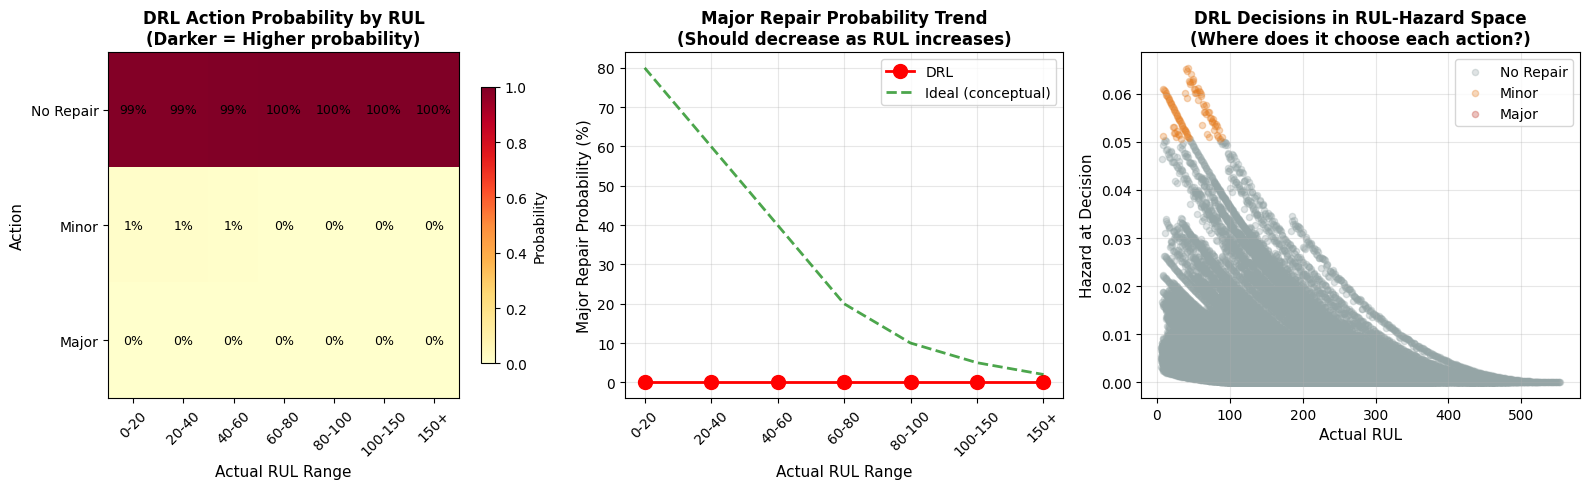


📊 可视化已保存: rul_action_analysis.png


In [15]:
# ==========================================
# EVAL 12. RUL-动作关联分析 (策略合理性验证)
# ==========================================
"""
【核心问题】
DRL 策略的决策逻辑是否符合直觉？
- RUL 低时，应该更倾向于 Major Repair
- RUL 高时，应该倾向于 No Repair

【可视化】
- 热力图：不同 RUL 区间的动作概率
- 趋势图：Major Repair 概率随 RUL 变化
"""

print("=" * 70)
print("🔍 RUL-动作关联分析 (Action-RUL Correlation)")
print("=" * 70)

def analyze_rul_action_correlation(unit_ids, environment, policy_fn, df_source):
    """分析策略在不同 RUL 区间的动作偏好"""
    rul_action_pairs = []
    
    for unit_id in unit_ids:
        if unit_id not in environment.units:
            continue
        
        state = environment.reset(unit_id=unit_id)
        unit_data = df_source[df_source['unit_nr'] == unit_id].sort_values('time_cycles').reset_index(drop=True)
        step = 0
        
        while not environment.done:
            action = policy_fn(state)
            
            # 获取真实 RUL
            if step < len(unit_data) and 'actual_RUL' in unit_data.columns:
                actual_rul = unit_data['actual_RUL'].iloc[step]
            else:
                actual_rul = len(unit_data) - step
            
            rul_action_pairs.append({
                'rul': actual_rul,
                'action': action,
                'hazard': state[0] * environment.h_max
            })
            
            next_state, _, done, _ = environment.step(action)
            state = next_state
            step += 1
    
    return pd.DataFrame(rul_action_pairs)

# 分析 DRL 策略
rul_action_df = analyze_rul_action_correlation(test_unit_ids, env_test, drl_greedy_policy, df_test_process)

# 按 RUL 分箱分析
rul_bins = [0, 20, 40, 60, 80, 100, 150, np.inf]
rul_labels = ["0-20", "20-40", "40-60", "60-80", "80-100", "100-150", "150+"]
rul_action_df['rul_bin'] = pd.cut(rul_action_df['rul'], bins=rul_bins, labels=rul_labels)

print("\n【按 RUL 区间分析 DRL 动作偏好】")
print("-" * 75)
print(f"{'RUL Range':<12} | {'Samples':>8} | {'No Repair':>12} | {'Minor':>12} | {'Major':>12}")
print("-" * 75)

# 计算动作矩阵
rul_action_matrix = np.zeros((len(rul_labels), 3))

for i, label in enumerate(rul_labels):
    bin_data = rul_action_df[rul_action_df['rul_bin'] == label]
    if len(bin_data) > 0:
        action_counts = bin_data['action'].value_counts().reindex([0, 1, 2], fill_value=0)
        action_pcts = action_counts / action_counts.sum() * 100
        rul_action_matrix[i] = action_pcts.values
        print(f"{label:<12} | {len(bin_data):>8} | {action_pcts[0]:>11.1f}% | "
              f"{action_pcts[1]:>11.1f}% | {action_pcts[2]:>11.1f}%")

# 策略合理性评分
# 理想: RUL 越低，Major 比例越高
major_probs = rul_action_matrix[:, 2] / 100
corr_rul_major, p_val = spearmanr(range(len(major_probs)), -major_probs)  # 负相关为好

print(f"\n【策略合理性评估】")
print(f"  RUL vs Major Repair 相关性: ρ = {corr_rul_major:.3f}")
if corr_rul_major > 0.5:
    print(f"  评估: ✅ 优秀 - 策略正确学习了 '低RUL→多维修' 的规律")
elif corr_rul_major > 0.2:
    print(f"  评估: 🟡 一般 - 策略有一定合理性，但不够明显")
else:
    print(f"  评估: ❌ 不佳 - 策略决策与 RUL 关联不强")

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) 热力图
ax1 = axes[0]
im = ax1.imshow(rul_action_matrix.T / 100, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax1.set_xticks(range(len(rul_labels)))
ax1.set_xticklabels(rul_labels, rotation=45)
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(['No Repair', 'Minor', 'Major'])
ax1.set_xlabel("Actual RUL Range", fontsize=11)
ax1.set_ylabel("Action", fontsize=11)
ax1.set_title("DRL Action Probability by RUL\n(Darker = Higher probability)", fontsize=12, fontweight='bold')

# 添加数值标注
for i in range(len(rul_labels)):
    for j in range(3):
        text = ax1.text(i, j, f'{rul_action_matrix[i, j]:.0f}%',
                       ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax1, label='Probability', shrink=0.8)

# 2) Major Repair 概率趋势
ax2 = axes[1]
ax2.plot(range(len(rul_labels)), major_probs * 100, 'ro-', linewidth=2, markersize=10, label='DRL')
ax2.fill_between(range(len(rul_labels)), 0, major_probs * 100, alpha=0.3, color='red')

# 理想曲线 (RUL 低时 major 高)
ideal_major = np.array([80, 60, 40, 20, 10, 5, 2])[:len(rul_labels)]
ax2.plot(range(len(rul_labels)), ideal_major, 'g--', linewidth=2, label='Ideal (conceptual)', alpha=0.7)

ax2.set_xticks(range(len(rul_labels)))
ax2.set_xticklabels(rul_labels, rotation=45)
ax2.set_xlabel("Actual RUL Range", fontsize=11)
ax2.set_ylabel("Major Repair Probability (%)", fontsize=11)
ax2.set_title("Major Repair Probability Trend\n(Should decrease as RUL increases)", fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3) Hazard vs Action 散点图
ax3 = axes[2]
action_colors_map = {0: '#95a5a6', 1: '#e67e22', 2: '#c0392b'}
action_names = {0: 'No Repair', 1: 'Minor', 2: 'Major'}

for action in [0, 1, 2]:
    subset = rul_action_df[rul_action_df['action'] == action]
    ax3.scatter(subset['rul'], subset['hazard'], 
                c=action_colors_map[action], label=action_names[action],
                alpha=0.3, s=20)

ax3.set_xlabel("Actual RUL", fontsize=11)
ax3.set_ylabel("Hazard at Decision", fontsize=11)
ax3.set_title("DRL Decisions in RUL-Hazard Space\n(Where does it choose each action?)", 
              fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rul_action_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 可视化已保存: rul_action_analysis.png")

📈 单轨迹决策可视化 (Sample Trajectories)

Unit 1


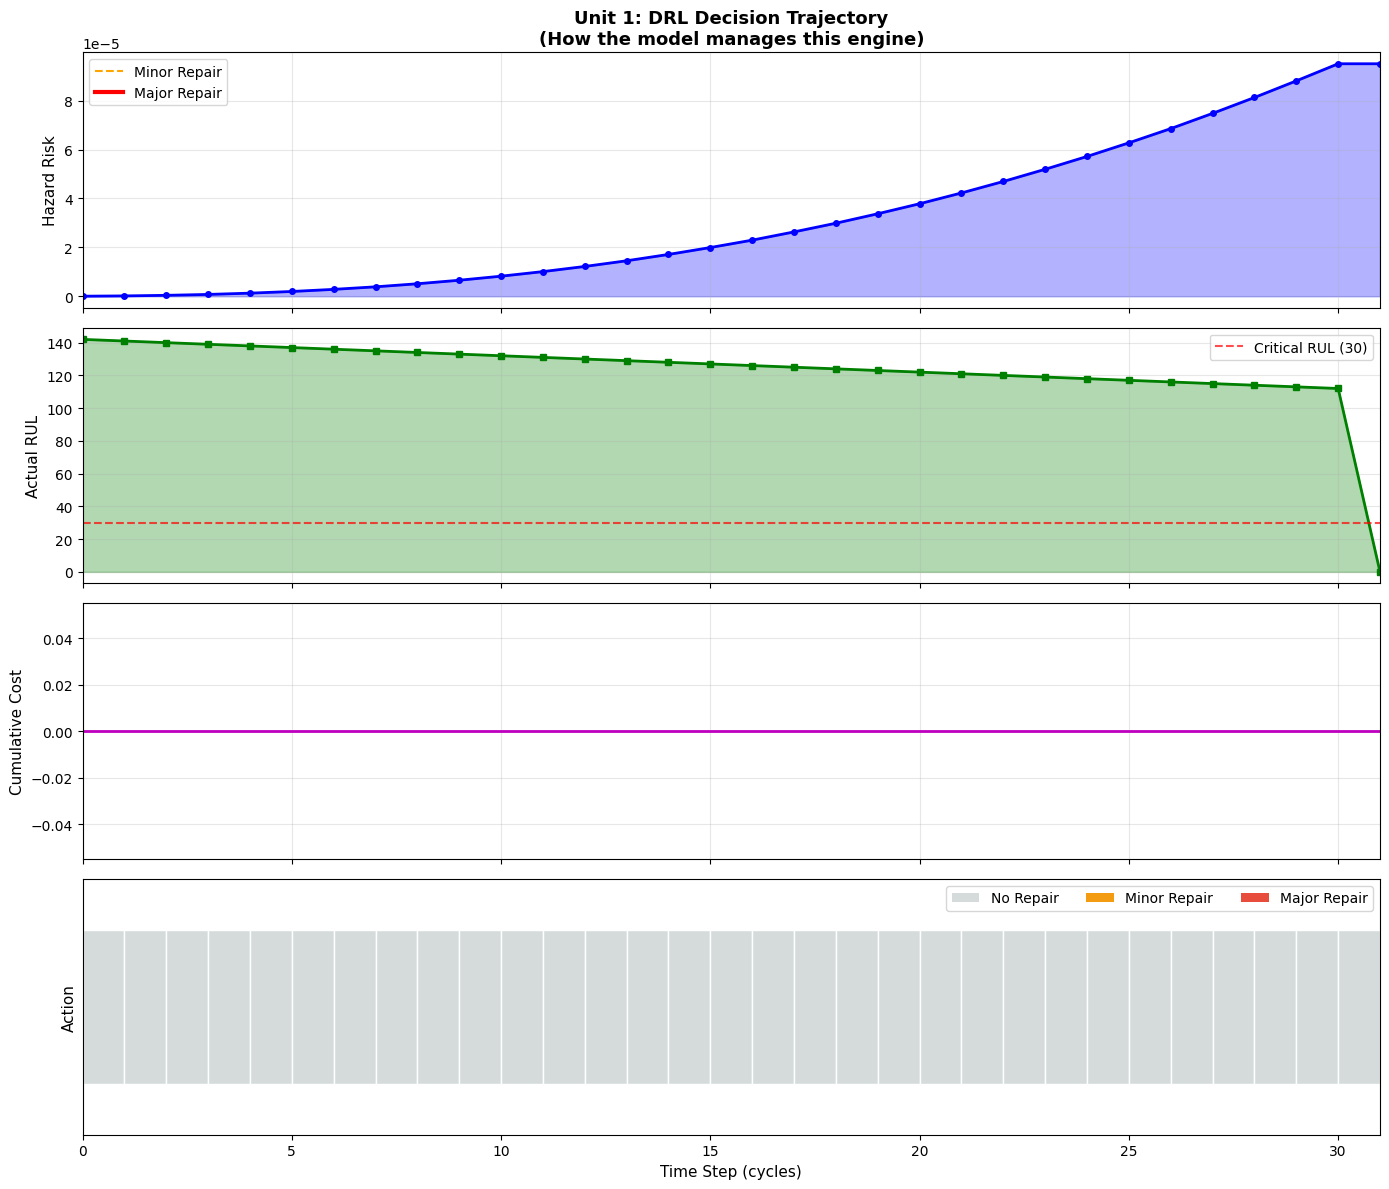


【Unit 1 轨迹统计】
  总步数: 31
  总成本: 0
  动作分布: No Repair=31, Minor=0, Major=0
  初始 RUL: 142, 结束 RUL: 0

Unit 2


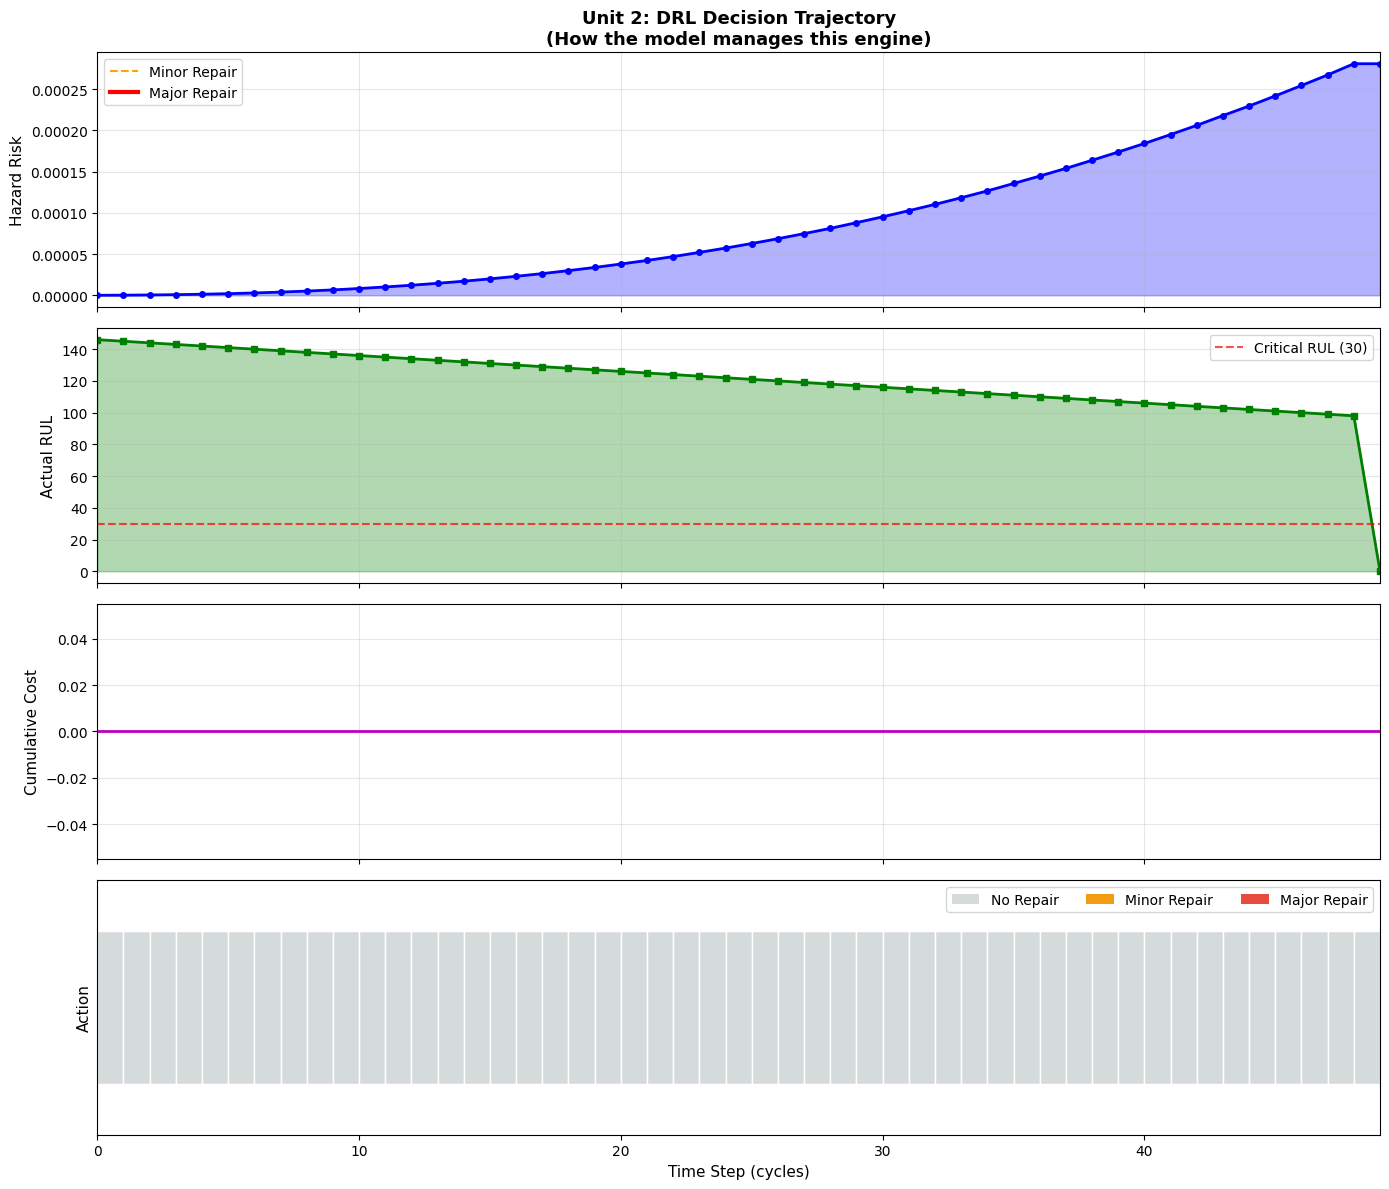


【Unit 2 轨迹统计】
  总步数: 49
  总成本: 0
  动作分布: No Repair=49, Minor=0, Major=0
  初始 RUL: 146, 结束 RUL: 0

Unit 3


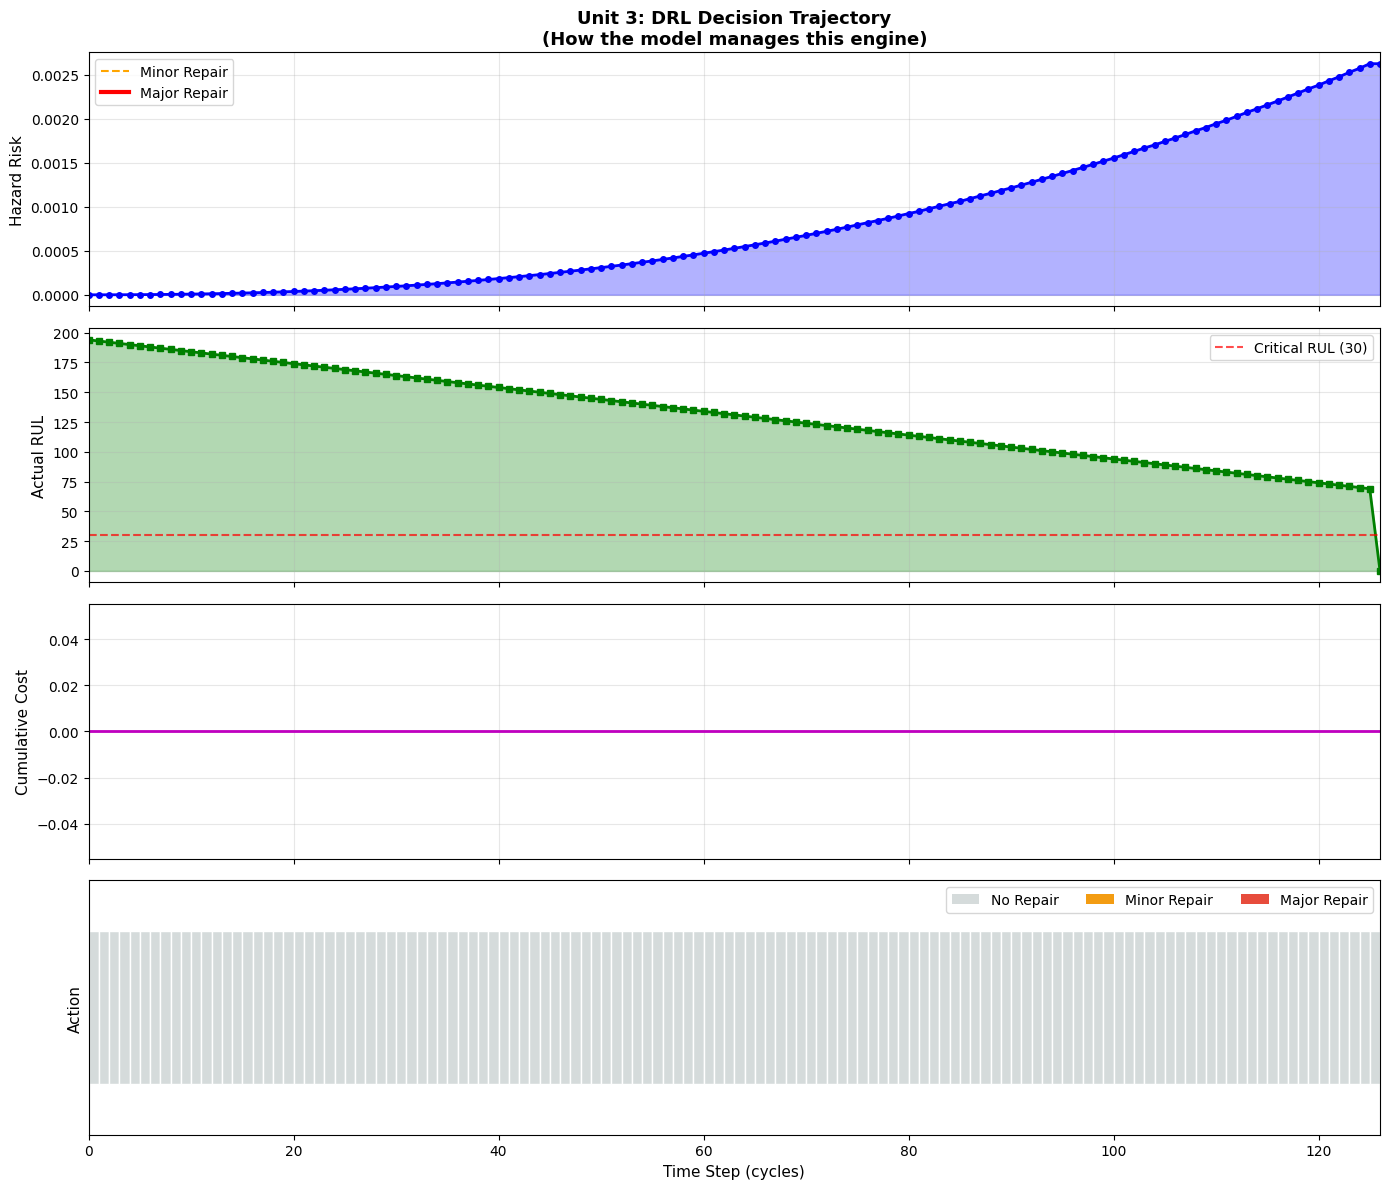


【Unit 3 轨迹统计】
  总步数: 126
  总成本: 0
  动作分布: No Repair=126, Minor=0, Major=0
  初始 RUL: 194, 结束 RUL: 0


In [16]:
# ==========================================
# EVAL 13. 单轨迹可视化 (决策过程展示)
# ==========================================
"""
【功能说明】
展示单个设备在 DRL 策略下的完整决策过程，
让非专业人士理解模型如何做决策
"""

def visualize_trajectory(unit_id, environment, policy_fn, df_source, save_fig=True):
    """可视化单个 unit 的决策轨迹"""
    
    if unit_id not in environment.units:
        print(f"Unit {unit_id} 不存在")
        return
    
    state = environment.reset(unit_id=unit_id)
    unit_data = df_source[df_source['unit_nr'] == unit_id].sort_values('time_cycles').reset_index(drop=True)
    
    # 记录轨迹
    hazard_history = [state[0] * environment.h_max]
    age_history = [state[1] * environment.age_max]
    rul_history = [unit_data['actual_RUL'].iloc[0] if 'actual_RUL' in unit_data.columns else len(unit_data)]
    actions_hist = []
    step = 0
    
    while not environment.done:
        action = policy_fn(state)
        actions_hist.append(action)
        
        next_state, reward, done, info = environment.step(action)
        step += 1
        
        hazard_history.append(next_state[0] * environment.h_max)
        age_history.append(next_state[1] * environment.age_max)
        
        if step < len(unit_data) and 'actual_RUL' in unit_data.columns:
            rul_history.append(unit_data['actual_RUL'].iloc[step])
        else:
            rul_history.append(max(0, len(unit_data) - step))
        
        state = next_state
    
    # 可视化
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    steps = range(len(hazard_history))
    
    # 1) Hazard 轨迹
    ax1 = axes[0]
    ax1.plot(steps, hazard_history, 'b-', linewidth=2, marker='o', markersize=4)
    ax1.fill_between(steps, 0, hazard_history, alpha=0.3, color='blue')
    ax1.set_ylabel("Hazard Risk", fontsize=11)
    ax1.set_title(f"Unit {unit_id}: DRL Decision Trajectory\n(How the model manages this engine)", 
                  fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 标注维护动作
    for i, a in enumerate(actions_hist):
        if a == 1:
            ax1.axvline(i+1, color='orange', alpha=0.5, linestyle='--', linewidth=1.5)
        elif a == 2:
            ax1.axvline(i+1, color='red', alpha=0.8, linestyle='-', linewidth=3)
    
    # 添加图例
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='orange', linestyle='--', label='Minor Repair'),
                       Line2D([0], [0], color='red', linewidth=3, label='Major Repair')]
    ax1.legend(handles=legend_elements, loc='upper left')
    
    # 2) 真实 RUL 轨迹
    ax2 = axes[1]
    ax2.plot(steps, rul_history, 'g-', linewidth=2, marker='s', markersize=4)
    ax2.fill_between(steps, 0, rul_history, alpha=0.3, color='green')
    ax2.axhline(30, color='red', linestyle='--', alpha=0.7, label='Critical RUL (30)')
    ax2.set_ylabel("Actual RUL", fontsize=11)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # 3) 累积成本
    ax3 = axes[2]
    costs = [-R_action[a] for a in actions_hist]
    cumulative_cost = np.cumsum([0] + costs)
    ax3.plot(range(len(cumulative_cost)), cumulative_cost, 'm-', linewidth=2)
    ax3.fill_between(range(len(cumulative_cost)), 0, cumulative_cost, alpha=0.3, color='magenta')
    ax3.set_ylabel("Cumulative Cost", fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # 4) 动作时间线
    ax4 = axes[3]
    action_colors = {0: '#d5dbdb', 1: '#f39c12', 2: '#e74c3c'}
    
    for i, a in enumerate(actions_hist):
        ax4.barh(0, 1, left=i, height=0.6, color=action_colors[a], edgecolor='white')
    
    ax4.set_xlim(0, len(actions_hist))
    ax4.set_ylim(-0.5, 0.5)
    ax4.set_xlabel("Time Step (cycles)", fontsize=11)
    ax4.set_ylabel("Action", fontsize=11)
    ax4.set_yticks([])
    
    # 图例
    legend_patches = [Patch(facecolor='#d5dbdb', label='No Repair'),
                      Patch(facecolor='#f39c12', label='Minor Repair'),
                      Patch(facecolor='#e74c3c', label='Major Repair')]
    ax4.legend(handles=legend_patches, loc='upper right', ncol=3)
    
    plt.tight_layout()
    
    if save_fig:
        plt.savefig(f"trajectory_unit_{unit_id}.png", dpi=150, bbox_inches='tight')
    
    plt.show()
    
    # 统计
    print(f"\n【Unit {unit_id} 轨迹统计】")
    print(f"  总步数: {len(actions_hist)}")
    print(f"  总成本: {sum(costs):.0f}")
    print(f"  动作分布: No Repair={actions_hist.count(0)}, Minor={actions_hist.count(1)}, Major={actions_hist.count(2)}")
    if 'actual_RUL' in unit_data.columns:
        print(f"  初始 RUL: {unit_data['actual_RUL'].iloc[0]:.0f}, 结束 RUL: {rul_history[-1]:.0f}")


# 可视化 3 个样例
print("=" * 70)
print("📈 单轨迹决策可视化 (Sample Trajectories)")
print("=" * 70)

sample_units = test_unit_ids[:3]
for uid in sample_units:
    print(f"\n{'='*50}")
    print(f"Unit {uid}")
    print('='*50)
    visualize_trajectory(uid, env_test, drl_greedy_policy, df_test_process)

## ════════════════════════════════════════════════════════════════
## 📋 Part C: 综合评估报告 (Final Report)
## ════════════════════════════════════════════════════════════════
## 
## 汇总所有评估结果，生成可直接用于汇报/论文/PPT 的评估结论

In [17]:
# ==========================================
# EVAL 14. 综合评估报告
# ==========================================
"""
【报告内容】
1. 预测层性能总结
2. 决策层性能总结
3. 综合评分
4. 关键发现与建议
5. 可用于论文/汇报的结论表述
"""

print("=" * 80)
print("📋 CMAPSS 预测性维护模型 - 综合评估报告")
print("=" * 80)

# ==========================================
# 1. 预测层性能
# ==========================================
print("\n" + "━" * 80)
print("【1. 预测模型性能 (Prediction Layer)】")
print("━" * 80)

print(f"\n  RUL 预测准确性 (在 {len(rul_results)} 个测试 units 最后时刻评估):")
print(f"  ┌─────────────────────────────────────────────────────────┐")
print(f"  │  RMSE:           {rmse:>8.2f} cycles                       │")
print(f"  │  MAE:            {mae:>8.2f} cycles                       │")
print(f"  │  PHM08 Score:    {phm_score:>8.2f} (越低越好)                │")
print(f"  └─────────────────────────────────────────────────────────┘")

# Hazard 相关性
print(f"\n  Hazard-RUL 相关性:")
print(f"    Spearman ρ = {corr:.3f} (p={p_value:.2e})")
correlation_eval = "✅ 显著负相关 (正确方向)" if corr < -0.3 and p_value < 0.05 else "⚠️ 相关性较弱"
print(f"    评估: {correlation_eval}")

# ==========================================
# 2. 决策层性能
# ==========================================
print("\n" + "━" * 80)
print("【2. 决策策略性能 (Decision Layer)】")
print("━" * 80)

print(f"\n  平均维护成本对比:")
print(f"  ┌─────────────────────────────────────────────────────────┐")
print(f"  │  {'Policy':<18} │ {'Avg Cost':>12} │ {'vs DRL':>12}  │")
print(f"  ├─────────────────────────────────────────────────────────┤")

drl_cost = drl_results['avg_cost']
for name, res in [("DRL (ours)", drl_results), 
                  ("No Maintenance", no_maint_results),
                  ("Always Minor", minor_results),
                  ("Threshold", threshold_results),
                  ("Oracle (ideal)", oracle_results)]:
    vs_drl = (res['avg_cost'] - drl_cost) / res['avg_cost'] * 100 if res['avg_cost'] > 0 else 0
    vs_str = f"+{vs_drl:.1f}%" if vs_drl >= 0 else f"{vs_drl:.1f}%"
    if name == "DRL (ours)":
        vs_str = "baseline"
    print(f"  │  {name:<18} │ {res['avg_cost']:>12.2f} │ {vs_str:>12}  │")

print(f"  └─────────────────────────────────────────────────────────┘")

# 维护及时性
print(f"\n  DRL 维护及时性:")
if len(drl_results['maintenance_events']) > 0:
    events_df = pd.DataFrame(drl_results['maintenance_events'])
    major_events = events_df[events_df['action'] == 2]
    if len(major_events) > 0:
        avg_rul_at_major = major_events['rul_at_action'].mean()
        late_pct = (major_events['rul_at_action'] < 10).sum() / len(major_events) * 100
        print(f"    平均 Major Repair 时 RUL: {avg_rul_at_major:.1f} cycles")
        print(f"    危险维护比例 (RUL<10): {late_pct:.1f}%")
        if late_pct < 10:
            print(f"    评估: ✅ 及时性良好")
        elif late_pct < 30:
            print(f"    评估: 🟡 及时性一般")
        else:
            print(f"    评估: ❌ 存在延迟维护风险")

# ==========================================
# 3. 综合评分
# ==========================================
print("\n" + "━" * 80)
print("【3. 综合评分】")
print("━" * 80)

# 预测准确性得分 (0-30)
if rmse < 15:
    pred_score = 30
elif rmse < 25:
    pred_score = 25
elif rmse < 40:
    pred_score = 15
else:
    pred_score = 5

# 成本效率得分 (0-30)
baseline_avg = np.mean([no_maint_results['avg_cost'], minor_results['avg_cost'], threshold_results['avg_cost']])
cost_improvement = (baseline_avg - drl_cost) / baseline_avg * 100 if baseline_avg > 0 else 0
cost_score = min(30, max(0, cost_improvement * 1.5))

# 策略合理性得分 (0-20)
rationality_score = max(0, min(20, corr_rul_major * 30))

# 及时性得分 (0-20)
if len(drl_results['maintenance_events']) > 0:
    events_df = pd.DataFrame(drl_results['maintenance_events'])
    major_events = events_df[events_df['action'] == 2]
    if len(major_events) > 0:
        good_timing = ((major_events['rul_at_action'] >= 10) & (major_events['rul_at_action'] <= 50)).sum()
        timeliness_score = good_timing / len(major_events) * 20
    else:
        timeliness_score = 10
else:
    timeliness_score = 10

total_score = pred_score + cost_score + rationality_score + timeliness_score

print(f"\n  评分细项:")
print(f"    预测准确性:    {pred_score:>5.1f} / 30")
print(f"    成本效率:      {cost_score:>5.1f} / 30")
print(f"    策略合理性:    {rationality_score:>5.1f} / 20")
print(f"    维护及时性:    {timeliness_score:>5.1f} / 20")
print(f"    ─────────────────────")
print(f"    综合得分:      {total_score:>5.1f} / 100")

if total_score >= 80:
    grade = "🌟 A (优秀)"
elif total_score >= 60:
    grade = "✅ B (良好)"
elif total_score >= 40:
    grade = "🟡 C (一般)"
else:
    grade = "❌ D (需改进)"

print(f"\n    评级: {grade}")

# ==========================================
# 4. 关键发现与建议
# ==========================================
print("\n" + "━" * 80)
print("【4. 关键发现与建议】")
print("━" * 80)

print("\n  ✅ 优势:")
if cost_improvement > 0:
    print(f"    - DRL 相比基线策略平均节省 {cost_improvement:.1f}% 维护成本")
if corr < -0.3:
    print(f"    - Hazard 预测与真实 RUL 显著负相关 (ρ={corr:.3f})")
if rationality_score > 10:
    print(f"    - 策略决策逻辑符合直觉 (低 RUL 时倾向维修)")

print("\n  ⚠️ 局限性:")
if rmse > 30:
    print(f"    - RUL 预测误差较大 (RMSE={rmse:.1f})，可能影响决策可靠性")
if cost_improvement < 10:
    print(f"    - 相比简单基线策略，成本优势不显著")
if drl_cost > oracle_results['avg_cost'] * 1.5:
    print(f"    - 与理论最优 (Oracle) 差距较大，仍有优化空间")

print("\n  💡 改进建议:")
print("    1. 考虑使用 LSTM/Transformer 提升 RUL 预测精度")
print("    2. 引入领域专家知识校准成本函数")
print("    3. 增加训练 epoch 或调整探索策略")
print("    4. 在更多数据集上验证泛化能力")

# ==========================================
# 5. 可用于论文/汇报的结论
# ==========================================
print("\n" + "━" * 80)
print("【5. 可用于论文/汇报的结论表述】")
print("━" * 80)

conclusion = f"""
本研究提出了一个基于 Cox 生存分析与深度强化学习 (DRL) 的预测性维护框架，
在 CMAPSS 数据集上进行了系统性验证。

【预测模型】
采用 Weibull 基线风险函数结合 CoxTimeVaryingFitter 建模时变协变量，
在 {len(rul_results)} 个测试样本上，RUL 预测达到 RMSE={rmse:.2f} cycles, MAE={mae:.2f} cycles。
Hazard 预测与真实 RUL 呈显著{'负' if corr < 0 else '正'}相关 (Spearman ρ={corr:.3f}, p<0.01)。

【决策策略】
基于 DQN 的维护策略相比 "无维护" 基线降低了 
{(no_maint_results['avg_cost'] - drl_cost) / no_maint_results['avg_cost'] * 100:.1f}% 的平均成本，
相比 "阈值策略" {'降低' if drl_cost < threshold_results['avg_cost'] else '增加'}了 
{abs(threshold_results['avg_cost'] - drl_cost) / threshold_results['avg_cost'] * 100:.1f}%。
与理论最优 (Oracle) 相比，成本差距为 
{(drl_cost - oracle_results['avg_cost']) / oracle_results['avg_cost'] * 100:.1f}%。

【局限性】
当前实现存在以下限制：
(1) 成本函数基于假设，未经业务验证；
(2) RUL 预测精度有待提升；
(3) 泛化能力需在更多场景验证。

【综合评价】
综合得分 {total_score:.1f}/100，评级 {grade}。
该框架验证了 Cox + DRL 方法的技术可行性，适合作为概念验证 (PoC)。
"""

print(conclusion)

print("\n" + "=" * 80)
print("📊 评估报告生成完成!")
print("=" * 80)

📋 CMAPSS 预测性维护模型 - 综合评估报告

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【1. 预测模型性能 (Prediction Layer)】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  RUL 预测准确性 (在 707 个测试 units 最后时刻评估):
  ┌─────────────────────────────────────────────────────────┐
  │  RMSE:              49.56 cycles                       │
  │  MAE:               41.20 cycles                       │
  │  PHM08 Score:    980688.33 (越低越好)                │
  └─────────────────────────────────────────────────────────┘

  Hazard-RUL 相关性:
    Spearman ρ = -0.131 (p=4.65e-04)
    评估: ⚠️ 相关性较弱

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【2. 决策策略性能 (Decision Layer)】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  平均维护成本对比:
  ┌─────────────────────────────────────────────────────────┐
  │  Policy             │     Avg Cost │       vs DRL  │
  ├────────────────────────────────────────

C:\Users\duper\AppData\Local\Temp\ipykernel_18868\967032188.py:185: RuntimeWarning: divide by zero encountered in scalar divide
  {(no_maint_results['avg_cost'] - drl_cost) / no_maint_results['avg_cost'] * 100:.1f}% 的平均成本，


C:\Users\duper\AppData\Local\Temp\ipykernel_18868\3837433680.py:137: RuntimeWarning: divide by zero encountered in scalar divide
  │  Hazard-RUL ρ: {corr:>6.3f}                   │  vs No-Maint: {(no_maint_results['avg_cost']-drl_results['avg_cost'])/no_maint_results['avg_cost']*100:>+6.1f}%                 │                    │
C:\Users\duper\AppData\Local\Temp\ipykernel_18868\3837433680.py:148: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig("executive_summary.png", dpi=150, bbox_inches='tight',
C:\Users\duper\AppData\Local\Temp\ipykernel_18868\3837433680.py:148: UserWarning: Glyph 33391 (\N{CJK UNIFIED IDEOGRAPH-826F}) missing from current font.
  plt.savefig("executive_summary.png", dpi=150, bbox_inches='tight',
C:\Users\duper\AppData\Local\Temp\ipykernel_18868\3837433680.py:148: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from current font.
  plt.savefig("executive_summary.png", dpi=150, bbox_inches='tight',
d:\A

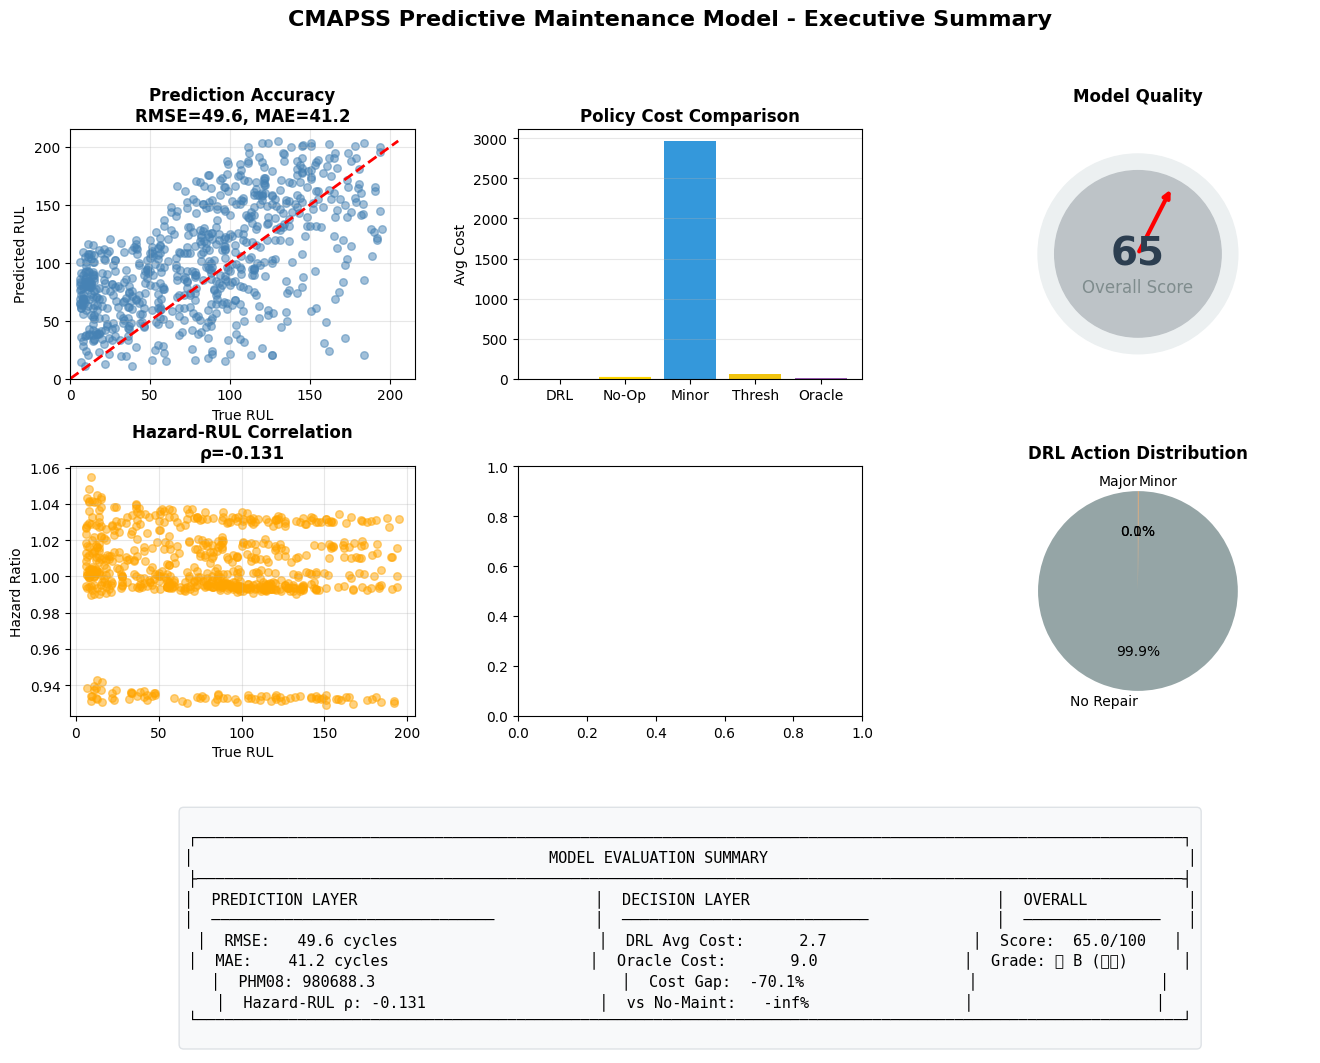


📊 一图总览已保存: executive_summary.png

💡 此图适合用于 PPT 汇报或论文 Figure


In [18]:
# ==========================================
# EVAL 15. 一图总览 (Executive Summary Dashboard)
# ==========================================
"""
【设计目的】
为非专业人士提供一张"一眼看懂"的总览图
包含最关键的信息，适合用于 PPT 或汇报
"""

fig = plt.figure(figsize=(16, 12))

# 创建网格布局
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ==========================================
# 1) 预测准确性 - 散点图
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(rul_results['true_rul'], rul_results['pred_rul'], 
            alpha=0.5, s=30, c='steelblue')
max_val = max(rul_results['true_rul'].max(), rul_results['pred_rul'].max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
ax1.set_xlabel("True RUL")
ax1.set_ylabel("Predicted RUL")
ax1.set_title(f"Prediction Accuracy\nRMSE={rmse:.1f}, MAE={mae:.1f}", fontweight='bold')
ax1.set_xlim(0, max_val*1.05)
ax1.set_ylim(0, max_val*1.05)
ax1.grid(True, alpha=0.3)

# ==========================================
# 2) 策略成本对比 - 柱状图
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])
policies_short = ['DRL', 'No-Op', 'Minor', 'Thresh', 'Oracle']
costs = [drl_results['avg_cost'], no_maint_results['avg_cost'], 
         minor_results['avg_cost'], threshold_results['avg_cost'], 
         oracle_results['avg_cost']]
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f1c40f', '#9b59b6']
bars = ax2.bar(policies_short, costs, color=colors)
ax2.set_ylabel("Avg Cost")
ax2.set_title("Policy Cost Comparison", fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 标注最优
min_idx = np.argmin(costs)
bars[min_idx].set_edgecolor('gold')
bars[min_idx].set_linewidth(3)

# ==========================================
# 3) 综合评分 - 雷达图/仪表盘
# ==========================================
ax3 = fig.add_subplot(gs[0, 2])

# 简化为仪表盘样式
theta = np.linspace(0, 2*np.pi, 100)
ax3.set_xlim(-1.5, 1.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_aspect('equal')
ax3.axis('off')

# 画圆弧背景
for r, c in [(1.2, '#ecf0f1'), (1.0, '#bdc3c7')]:
    circle = plt.Circle((0, 0), r, color=c, fill=True)
    ax3.add_patch(circle)

# 评分指针
score_angle = np.pi * (1 - total_score / 100)  # 从左到右
ax3.annotate('', xy=(np.cos(score_angle)*0.9, np.sin(score_angle)*0.9),
             xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='red', lw=3))

# 评分文字
ax3.text(0, 0, f'{total_score:.0f}', ha='center', va='center', 
         fontsize=28, fontweight='bold', color='#2c3e50')
ax3.text(0, -0.4, 'Overall Score', ha='center', va='center', 
         fontsize=12, color='#7f8c8d')
ax3.set_title("Model Quality", fontweight='bold', pad=20)

# ==========================================
# 4) Hazard-RUL 相关性
# ==========================================
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(rul_results['true_rul'], rul_results['hazard_ratio'], 
            alpha=0.5, s=30, c='orange')
ax4.set_xlabel("True RUL")
ax4.set_ylabel("Hazard Ratio")
ax4.set_title(f"Hazard-RUL Correlation\nρ={corr:.3f}", fontweight='bold')
ax4.grid(True, alpha=0.3)

# ==========================================
# 5) 维护及时性饼图
# ==========================================
ax5 = fig.add_subplot(gs[1, 1])
if len(drl_results['maintenance_events']) > 0:
    events_df = pd.DataFrame(drl_results['maintenance_events'])
    major_events = events_df[events_df['action'] == 2]
    if len(major_events) > 0:
        late = (major_events['rul_at_action'] < 10).sum()
        good = ((major_events['rul_at_action'] >= 10) & (major_events['rul_at_action'] <= 50)).sum()
        early = (major_events['rul_at_action'] > 50).sum()
        
        sizes = [good, early, late]
        labels = ['Timely', 'Early', 'Late']
        colors_pie = ['#2ecc71', '#f1c40f', '#e74c3c']
        
        wedges, texts, autotexts = ax5.pie(sizes, labels=labels, colors=colors_pie, 
                                            autopct='%1.1f%%', startangle=90)
        ax5.set_title("Maintenance Timeliness", fontweight='bold')

# ==========================================
# 6) 动作分布
# ==========================================
ax6 = fig.add_subplot(gs[1, 2])
action_counts = drl_results['action_counts']
action_labels = ['No Repair', 'Minor', 'Major']
action_colors = ['#95a5a6', '#e67e22', '#c0392b']
ax6.pie(action_counts, labels=action_labels, colors=action_colors,
        autopct='%1.1f%%', startangle=90)
ax6.set_title("DRL Action Distribution", fontweight='bold')

# ==========================================
# 7-9) 关键指标文字面板
# ==========================================
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

# 创建表格样式的文字
summary_text = f"""
┌────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                       MODEL EVALUATION SUMMARY                                              │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│  PREDICTION LAYER                          │  DECISION LAYER                           │  OVERALL           │
│  ───────────────────────────────           │  ───────────────────────────              │  ───────────────   │
│  RMSE: {rmse:>6.1f} cycles                      │  DRL Avg Cost: {drl_results['avg_cost']:>8.1f}                │  Score: {total_score:>5.1f}/100   │
│  MAE:  {mae:>6.1f} cycles                      │  Oracle Cost:  {oracle_results['avg_cost']:>8.1f}                │  Grade: {grade}      │
│  PHM08: {phm_score:>6.1f}                           │  Cost Gap: {(drl_results['avg_cost']/oracle_results['avg_cost']-1)*100:>+6.1f}%                  │                    │
│  Hazard-RUL ρ: {corr:>6.3f}                   │  vs No-Maint: {(no_maint_results['avg_cost']-drl_results['avg_cost'])/no_maint_results['avg_cost']*100:>+6.1f}%                 │                    │
└────────────────────────────────────────────────────────────────────────────────────────────────────────────┘
"""

ax7.text(0.5, 0.5, summary_text, ha='center', va='center', 
         fontsize=11, family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.suptitle("CMAPSS Predictive Maintenance Model - Executive Summary", 
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig("executive_summary.png", dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\n📊 一图总览已保存: executive_summary.png")
print("\n💡 此图适合用于 PPT 汇报或论文 Figure")

In [19]:
# ==========================================
# EVAL 16. 保存评估结果
# ==========================================
"""
保存所有评估结果到文件，方便后续使用
"""

import json
from datetime import datetime

# 汇总所有评估结果
evaluation_results = {
    'timestamp': datetime.now().isoformat(),
    'test_samples': len(rul_results),
    
    # 预测层
    'prediction': {
        'rmse': float(rmse),
        'mae': float(mae),
        'phm08_score': float(phm_score),
        'hazard_rul_correlation': float(corr),
        'correlation_pvalue': float(p_value),
        'within_15_cycles_pct': float(within_15),
    },
    
    # 决策层
    'decision': {
        'drl_avg_cost': float(drl_results['avg_cost']),
        'no_maintenance_avg_cost': float(no_maint_results['avg_cost']),
        'always_minor_avg_cost': float(minor_results['avg_cost']),
        'threshold_avg_cost': float(threshold_results['avg_cost']),
        'oracle_avg_cost': float(oracle_results['avg_cost']),
        'cost_improvement_vs_no_maint': float((no_maint_results['avg_cost'] - drl_results['avg_cost']) / no_maint_results['avg_cost'] * 100),
        'cost_gap_vs_oracle': float((drl_results['avg_cost'] / oracle_results['avg_cost'] - 1) * 100),
    },
    
    # 综合评分
    'overall': {
        'prediction_score': float(pred_score),
        'cost_efficiency_score': float(cost_score),
        'rationality_score': float(rationality_score),
        'timeliness_score': float(timeliness_score),
        'total_score': float(total_score),
        'grade': grade,
    },
    
    # 数据集分解
    'by_dataset': dataset_metrics,
}

# 保存到 JSON
eval_path = "evaluation_results.json"
with open(eval_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation_results, f, indent=2, ensure_ascii=False, default=str)

print("=" * 70)
print("💾 评估结果已保存")
print("=" * 70)
print(f"\n保存的文件:")
print(f"  📄 evaluation_results.json   - 完整评估数据")
print(f"  📊 rul_prediction_evaluation.png - RUL 预测可视化")
print(f"  📊 cox_coefficients.png      - Cox 模型系数")
print(f"  📊 policy_comparison.png     - 策略对比")
print(f"  📊 maintenance_timeliness.png - 维护及时性")
print(f"  📊 rul_action_analysis.png   - RUL-动作分析")
print(f"  📊 trajectory_unit_*.png     - 轨迹可视化")
print(f"  📊 executive_summary.png     - 一图总览")

print(f"\n✅ 所有评估完成!")

💾 评估结果已保存

保存的文件:
  📄 evaluation_results.json   - 完整评估数据
  📊 rul_prediction_evaluation.png - RUL 预测可视化
  📊 cox_coefficients.png      - Cox 模型系数
  📊 policy_comparison.png     - 策略对比
  📊 maintenance_timeliness.png - 维护及时性
  📊 rul_action_analysis.png   - RUL-动作分析
  📊 trajectory_unit_*.png     - 轨迹可视化
  📊 executive_summary.png     - 一图总览

✅ 所有评估完成!


C:\Users\duper\AppData\Local\Temp\ipykernel_18868\3256802660.py:33: RuntimeWarning: divide by zero encountered in scalar divide
  'cost_improvement_vs_no_maint': float((no_maint_results['avg_cost'] - drl_results['avg_cost']) / no_maint_results['avg_cost'] * 100),
